# DNS / DNSS con Filtro de Kalman — τ Adaptativo via Grid Search
## Kalman Filter · MLE multi-start · τ rodante · RTS Smoother · Análisis Post-Ajuste

### Modelo espacio-estado con cargas variables

**Ecuación de observación:**
$$y_t(\tau_n) = H(\boldsymbol{\tau}_t)\,\boldsymbol{\beta}_t + \boldsymbol{\varepsilon}_t,
\qquad \boldsymbol{\varepsilon}_t \sim \mathcal{N}(\mathbf{0}, R)$$

**Ecuación de transición:**
$$\boldsymbol{\beta}_t = \boldsymbol{\mu} + F(\boldsymbol{\beta}_{t-1} - \boldsymbol{\mu}) + \boldsymbol{\eta}_t,
\qquad \boldsymbol{\eta}_t \sim \mathcal{N}(\mathbf{0}, Q)$$

**Innovación adaptativa:** $\boldsymbol{\tau}_t$ se re-estima en **cada período** via Grid Search
sobre perfil-SSE de una ventana rodante. Esto hace que $H_t = H(\boldsymbol{\tau}_t)$ **varíe en el tiempo**,
capturando cambios estructurales en la forma de la curva.

| Modelo | Factores $k$ | Parámetro de forma | Hump |
|---|---|---|---|
| DNS (Nelson-Siegel) | 3 | $\tau_1$ | $\approx 1.793\,\tau_1$ años |
| DNSS (Nelson-Siegel-Svensson) | 4 | $\tau_1,\tau_2$ | $\approx 1.793\,\tau_1$ y $\approx 1.793\,\tau_2$ años |

**Opciones de $F$:** `'diagonal'` (consenso empírico: Çakmaklı 2013, Caldeira et al. 2010)
· `'triangular'` · `'completa'` (VAR-1 irrestricto)

### Flujo de estimación
```
1. Rolling Grid Search  →  τ_t    (serie de parámetros de forma)
2. Construir H_arr      →  H_t = H(τ_t)  variable en t
3. MLE (L-BFGS-B multi-start)  →  μ, F, Q, R  óptimos
4. Kalman Filter forward        →  β_{t|t}, P_{t|t}, log-lik
5. RTS Smoother backward        →  β_{t|T}, P_{t|T}
6. Análisis post-ajuste         →  factores, τ_t, residuos, diagnósticos
```

### Referencias principales
Nelson & Siegel (1987) · Diebold & Li (2006) · Svensson (1994) ·
Caldeira, Laurini & Portugal (2010) · Çakmaklı (2013) · Hamilton (1994, Ch.13)


## CELDA 0: Imports y configuración global

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import os
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from scipy import stats
from scipy.optimize import minimize
from scipy.linalg import solve_discrete_lyapunov
import warnings, time
warnings.filterwarnings('ignore')

# ── Numba JIT ─────────────────────────────────────────────────────────────────
try:
    from numba import njit
    _NUMBA = True
    print("✓ Numba disponible — Kalman Filter JIT activado")
except ImportError:
    _NUMBA = False
    def njit(**kw):
        return lambda f: f
    print("⚠ Numba no disponible — modo Python puro (5-10x mas lento)")

# ── Estilo global ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.grid'        : True,
    'grid.alpha'       : 0.22,
    'font.size'        : 10,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'legend.framealpha': 0.85,
    'legend.fontsize'  : 9,
})

COLORES_FACTOR = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
COLORES_TAU    = ['#9467bd', '#8c564b']

np.random.seed(42)
print("✓ Configuracion lista")


✓ Numba disponible — Kalman Filter JIT activado
✓ Configuracion lista


## CELDA 1: Carga de datos

In [ ]:
# Cambia esta ruta a tu archivo real (debe ser .csv):
RUTA_DATOS = r"C:\Users\ADMON\Documents\Universidad\Proyecto KMJ\codigo\TES_colombia\curvas_panel_historico_limpio.csv"

if os.path.exists(RUTA_DATOS):
    # ── Datos reales ──────────────────────────────────────────────────────
    raw = pd.read_csv(RUTA_DATOS)
    yield_cols = ["r_2yr", "r_3yr", "r_5yr", "r_7yr", "r_10yr", "r_15yr"]
    maturities = np.array([2, 3, 5, 7, 10, 15], dtype=float)
    df = raw[["fecha"] + yield_cols].copy()
    df["fecha"] = pd.to_datetime(df["fecha"])
    df = df.dropna(subset=yield_cols).sort_values("fecha").reset_index(drop=True)
    # df = df[::7]   # frecuencia semanal
    yields_data = df[yield_cols].values
    dates_dt    = pd.DatetimeIndex(df["fecha"].values)
    fuente = "TES Colombia"
else:
    # ── Datos sinteticos para prototipado ─────────────────────────────────
    # Factores AR(1) con tau variable → curva realista que cambia de forma
    T_sim  = 600
    maturities = np.array([2.0, 3.0, 5.0, 7.0, 10.0, 15.0])
    N_m = len(maturities)

    beta_true  = np.zeros((T_sim, 3))
    beta_true[0] = [5.5, -2.5, 2.0]
    phi_true   = np.array([0.97, 0.95, 0.90])
    mu_true    = np.array([5.0, -2.0, 1.5])
    sigma_eta  = np.array([0.06, 0.12, 0.18])
    for t in range(1, T_sim):
        beta_true[t] = mu_true + phi_true*(beta_true[t-1]-mu_true) + np.random.randn(3)*sigma_eta

    # tau oscila lentamente para que la busqueda adaptativa lo siga
    tau_true_t = 1.8 + 0.6*np.sin(np.linspace(0, 3*np.pi, T_sim))

    def _ns_H_simple(m, tau):
        mt = m/tau; e = np.exp(-mt); c = (1-e)/mt
        return np.column_stack([np.ones_like(m), c, c-e])

    yields_data = np.zeros((T_sim, N_m))
    for t in range(T_sim):
        H_t = _ns_H_simple(maturities, tau_true_t[t])
        yields_data[t] = H_t @ beta_true[t] + np.random.randn(N_m)*0.06

    dates_dt   = pd.date_range("2015-01-02", periods=T_sim, freq="W-FRI")
    yield_cols = [f"Y{int(m)}Y" for m in maturities]
    df         = pd.DataFrame(yields_data, index=dates_dt, columns=yield_cols)
    fuente     = "Sintetico AR-1 con tau oscilante (para demostracion)"

T, N = yields_data.shape
print(f"Fuente     : {fuente}")
print(f"T={T}  N={N}  plazos={maturities}")
print(f"Rango      : {dates_dt[0].date()} → {dates_dt[-1].date()}")
print(f"Rendimientos media={yields_data.mean():.3f}  std={yields_data.std():.3f}")


Fuente     : SVENY (Federal Reserve)
T=2735  N=6  plazos=[ 2.  3.  5.  7. 10. 15.]
Rango      : 2015-01-02 → 2026-03-20
Rendimientos media=8.109  std=2.670


## CELDA 2: Cargas Nelson-Siegel y Svensson

$$H_{NS}(\tau_1)_{n} =
\left[1,\;
\frac{1-e^{-m_n/\tau_1}}{m_n/\tau_1},\;
\frac{1-e^{-m_n/\tau_1}}{m_n/\tau_1} - e^{-m_n/\tau_1}\right]$$

$$H_{NSS}(\tau_1,\tau_2)_{n} =
\left[H_{NS}(\tau_1)_{n},\;
\frac{1-e^{-m_n/\tau_2}}{m_n/\tau_2} - e^{-m_n/\tau_2}\right]$$

La primera carga es siempre 1 → $\beta_0$ es el **nivel** (tasa de largo plazo).
La segunda es decreciente → $\beta_1$ es la **pendiente**.
La tercera tiene un hump en $m^*\approx 1.793\,\tau_1$ → $\beta_2$ es la **curvatura**.


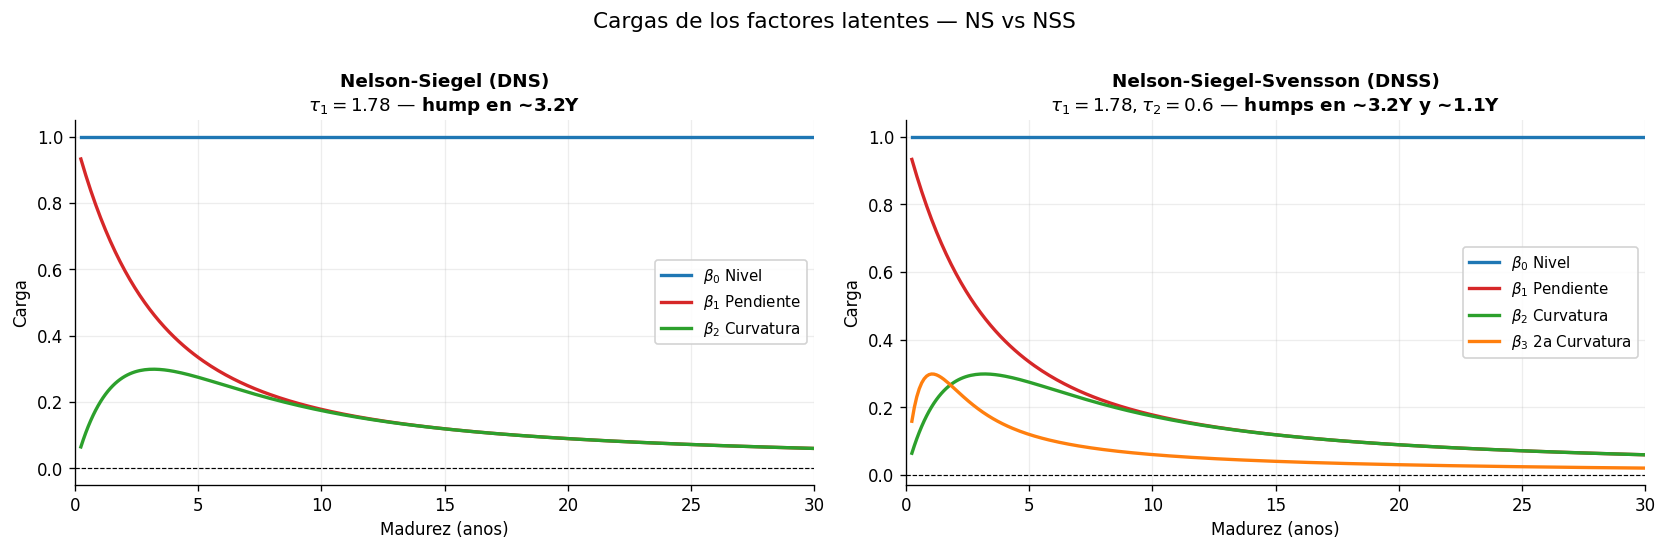

Hump NS : ~3.19Y | Humps NSS: ~3.19Y y ~1.08Y


In [3]:
def ns_loadings(maturities, tau1):
    '''Cargas Nelson-Siegel. Shape (N, 3). [nivel, pendiente, curvatura]'''
    m  = np.asarray(maturities, dtype=float)
    mt = m / tau1
    e  = np.exp(-mt)
    c  = (1.0 - e) / mt
    return np.column_stack([np.ones_like(m), c, c - e])


def nss_loadings(maturities, tau1, tau2):
    '''Cargas Nelson-Siegel-Svensson. Shape (N, 4). [nivel, pendiente, curv1, curv2]'''
    m   = np.asarray(maturities, dtype=float)
    mt1 = m / tau1;  mt2 = m / tau2
    e1  = np.exp(-mt1);  e2 = np.exp(-mt2)
    c1  = (1.0 - e1) / mt1
    return np.column_stack([np.ones_like(m), c1, c1 - e1, (1.0-e2)/mt2 - e2])


def get_loadings(maturities, tau1, tau2=None, model='DNS'):
    '''Wrapper unificado.'''
    return ns_loadings(maturities, tau1) if model == 'DNS' \
        else nss_loadings(maturities, tau1, tau2)


# ── Visualizacion de cargas ──────────────────────────────────────────────────
m_plot = np.linspace(0.25, 30, 300)
tau1_ref, tau2_ref = 1.78, 0.60

H_ns  = ns_loadings(m_plot, tau1_ref)
H_nss = nss_loadings(m_plot, tau1_ref, tau2_ref)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)
nombres_ns  = [r'$\beta_0$ Nivel', r'$\beta_1$ Pendiente', r'$\beta_2$ Curvatura']
nombres_nss = nombres_ns + [r'$\beta_3$ 2a Curvatura']

specs = [
    (axes[0], H_ns,  nombres_ns,  'Nelson-Siegel (DNS)',
     rf'$\tau_1={tau1_ref}$ — hump en ~{1.793*tau1_ref:.1f}Y'),
    (axes[1], H_nss, nombres_nss, 'Nelson-Siegel-Svensson (DNSS)',
     rf'$\tau_1={tau1_ref},\tau_2={tau2_ref}$ — humps en ~{1.793*tau1_ref:.1f}Y y ~{1.793*tau2_ref:.1f}Y'),
]
for ax, H, nombres, titulo, subtit in specs:
    for i, (nom, col) in enumerate(zip(nombres, COLORES_FACTOR)):
        ax.plot(m_plot, H[:, i], color=col, lw=2.0, label=nom)
    ax.axhline(0, color='k', lw=0.7, ls='--')
    ax.set_xlabel('Madurez (anos)'); ax.set_ylabel('Carga')
    ax.set_title(f'{titulo}\n{subtit}', fontsize=11)
    ax.legend(); ax.set_xlim(0, 30)

plt.suptitle('Cargas de los factores latentes — NS vs NSS', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
print(f"Hump NS : ~{1.793*tau1_ref:.2f}Y | Humps NSS: ~{1.793*tau1_ref:.2f}Y y ~{1.793*tau2_ref:.2f}Y")


## CELDA 3: Filtro de Kalman con $H_t$ variable (Numba JIT)

**Prediccion:**
$$\boldsymbol{\beta}_{t|t-1} = \boldsymbol{\mu} + F(\boldsymbol{\beta}_{t-1|t-1} - \boldsymbol{\mu}),
\quad P_{t|t-1} = F P_{t-1|t-1} F^\top + Q$$

**Innovacion y varianza:**
$$\mathbf{v}_t = \mathbf{y}_t - H_t\boldsymbol{\beta}_{t|t-1},
\quad S_t = H_t P_{t|t-1} H_t^\top + R$$

**Actualizacion (forma Joseph — numericamente estable):**
$$K_t = P_{t|t-1} H_t^\top S_t^{-1}, \quad
\boldsymbol{\beta}_{t|t} = \boldsymbol{\beta}_{t|t-1} + K_t\mathbf{v}_t$$
$$P_{t|t} = (I - K_t H_t)\,P_{t|t-1}\,(I - K_t H_t)^\top + K_t R K_t^\top$$

**Log-verosimilitud** (Cholesky, numericamente estable):
$$\log\mathcal{L} = -\frac{TN}{2}\log(2\pi)
- \frac{1}{2}\sum_t \left[2\sum_n\log L_{t,nn} + \mathbf{v}_t^\top S_t^{-1}\mathbf{v}_t\right]$$


In [4]:
if _NUMBA:
    from numba import njit as _njit

    @_njit(cache=True)
    def _kf_core(yields, H_arr, F, Q, R_diag, mu, beta0, P0):
        '''
        Kalman Filter con H_t variable. Compilado con Numba.

        Entradas:
          yields  (T, N)      rendimientos observados
          H_arr   (T, N, k)   cargas por periodo
          F       (k, k)      transicion
          Q       (k, k)      cov. innovaciones de estado
          R_diag  (N,)        varianzas de medicion
          mu      (k,)        media de largo plazo
          beta0   (k,)        estado inicial
          P0      (k, k)      covarianza inicial

        Salidas:
          beta_pred (T,k), beta_filt (T,k), P_pred (T,k,k),
          P_filt (T,k,k), innov (T,N), loglik float
        '''
        T_obs, N_obs = yields.shape
        k_dim = F.shape[0]
        Ik    = np.eye(k_dim)
        LOG2PI = np.log(2.0 * np.pi)

        beta_pred_all = np.zeros((T_obs, k_dim))
        beta_filt_all = np.zeros((T_obs, k_dim))
        P_pred_all    = np.zeros((T_obs, k_dim, k_dim))
        P_filt_all    = np.zeros((T_obs, k_dim, k_dim))
        innov_all     = np.zeros((T_obs, N_obs))
        loglik        = 0.0

        beta = beta0.copy()
        P    = P0.copy()

        for t in range(T_obs):
            # ── Prediccion ──────────────────────────────────────────────
            beta_p = mu + F @ (beta - mu)
            P_p    = F @ P @ F.T + Q
            P_p    = 0.5 * (P_p + P_p.T)
            beta_pred_all[t] = beta_p
            P_pred_all[t]    = P_p

            # ── Actualizacion ───────────────────────────────────────────
            Ht  = H_arr[t]                        # (N, k)
            v   = yields[t] - Ht @ beta_p
            HP  = Ht @ P_p                        # (N, k)
            S   = HP @ Ht.T                       # (N, N)
            for n in range(N_obs):
                S[n, n] += R_diag[n]
            S = 0.5 * (S + S.T)

            # Log-det via Cholesky
            L_chol = np.linalg.cholesky(S + 1e-10 * np.eye(N_obs))
            log_det = 0.0
            for n in range(N_obs):
                log_det += np.log(L_chol[n, n])
            log_det *= 2.0

            z    = np.linalg.solve(L_chol, v)
            quad = np.dot(z, z)
            loglik += -0.5 * (N_obs * LOG2PI + log_det + quad)
            innov_all[t] = v

            # Ganancia de Kalman
            Z  = np.linalg.solve(L_chol, HP)
            Kt = np.linalg.solve(L_chol.T, Z)
            K  = Kt.T                             # (k, N)

            beta = beta_p + K @ v

            # Forma Joseph
            Rmat = np.zeros((N_obs, N_obs))
            for n in range(N_obs):
                Rmat[n, n] = R_diag[n]
            IKH = Ik - K @ Ht
            P   = IKH @ P_p @ IKH.T + K @ Rmat @ K.T
            P   = 0.5 * (P + P.T)

            beta_filt_all[t] = beta
            P_filt_all[t]    = P

        return (beta_pred_all, beta_filt_all, P_pred_all,
                P_filt_all, innov_all, loglik)

else:
    # Version Python puro (sin Numba)
    def _kf_core(yields, H_arr, F, Q, R_diag, mu, beta0, P0):
        T_obs, N_obs = yields.shape
        k_dim = F.shape[0]
        Ik    = np.eye(k_dim)
        R_mat = np.diag(R_diag)
        LOG2PI = np.log(2.0 * np.pi)

        beta_pred_all = np.zeros((T_obs, k_dim))
        beta_filt_all = np.zeros((T_obs, k_dim))
        P_pred_all    = np.zeros((T_obs, k_dim, k_dim))
        P_filt_all    = np.zeros((T_obs, k_dim, k_dim))
        innov_all     = np.zeros((T_obs, N_obs))
        loglik        = 0.0

        beta = beta0.copy(); P = P0.copy()

        for t in range(T_obs):
            beta_p = mu + F @ (beta - mu)
            P_p    = F @ P @ F.T + Q
            P_p    = 0.5*(P_p + P_p.T)
            beta_pred_all[t] = beta_p; P_pred_all[t] = P_p

            Ht = H_arr[t]
            v  = yields[t] - Ht @ beta_p
            S  = Ht @ P_p @ Ht.T + R_mat
            S  = 0.5*(S + S.T)

            L = np.linalg.cholesky(S + 1e-10*np.eye(N_obs))
            log_det = 2.0*np.sum(np.log(np.diag(L)))
            z = np.linalg.solve(L, v); quad = z@z
            loglik += -0.5*(N_obs*LOG2PI + log_det + quad)
            innov_all[t] = v

            K    = np.linalg.solve(S, Ht @ P_p).T
            beta = beta_p + K @ v
            IKH  = Ik - K @ Ht
            P    = IKH @ P_p @ IKH.T + K @ R_mat @ K.T
            P    = 0.5*(P + P.T)
            beta_filt_all[t] = beta; P_filt_all[t] = P

        return (beta_pred_all, beta_filt_all, P_pred_all,
                P_filt_all, innov_all, loglik)


def build_H_array(maturities, tau1_t, tau2_t, model):
    '''Construye H_arr (T, N, k) desde las secuencias tau_t.'''
    T_obs = len(tau1_t)
    k = 3 if model == 'DNS' else 4
    N = len(maturities)
    H_arr = np.zeros((T_obs, N, k))
    for t in range(T_obs):
        if model == 'DNS':
            H_arr[t] = ns_loadings(maturities, tau1_t[t])
        else:
            H_arr[t] = nss_loadings(maturities, tau1_t[t], tau2_t[t])
    return H_arr


def compute_P0_stationary(F, Q, F_type):
    '''
    Covarianza inicial estacionaria.
    Resuelve P0 = F P0 F' + Q (ecuacion de Lyapunov discreta).
    '''
    k = F.shape[0]
    if F_type == 'diagonal':
        f_vec = np.diag(F)
        q_vec = np.diag(Q)
        P0_d  = q_vec / np.maximum(1 - f_vec**2, 1e-6)
        return np.diag(P0_d)
    else:
        try:
            return solve_discrete_lyapunov(F, Q)
        except Exception:
            return np.eye(k) * 1.0

print("Kalman Filter definido (modo:", "Numba JIT" if _NUMBA else "Python puro", ")")


Kalman Filter definido (modo: Numba JIT )


## CELDA 4: RTS Smoother (Rauch-Tung-Striebel)

El suavizador RTS produce $E[\boldsymbol{\beta}_t \mid \mathbf{Y}_{1:T}]$ usando **toda** la información muestral.
Corre hacia atras usando los resultados del forward KF:

$$G_t = P_{t|t}\,F^\top\,P_{t+1|t}^{-1} \quad \text{(ganancia suavizadora)}$$
$$\hat{\boldsymbol{\beta}}_{t|T} = \boldsymbol{\beta}_{t|t}
+ G_t\left(\hat{\boldsymbol{\beta}}_{t+1|T} - \boldsymbol{\beta}_{t+1|t}\right)$$
$$\hat{P}_{t|T} = P_{t|t} + G_t\left(\hat{P}_{t+1|T} - P_{t+1|t}\right)G_t^\top$$

> **Nota:** El RTS smoother no depende de $H_t$, solo de $F$ y $Q$.
> Es valido aunque las cargas varien en el tiempo.


In [5]:
def rts_smoother(beta_filt, P_filt, beta_pred, P_pred, F):
    '''
    Rauch-Tung-Striebel Smoother.

    Retorna: beta_smooth (T,k), P_smooth (T,k,k), G_all (T,k,k)
    '''
    T, k   = beta_filt.shape
    beta_s = np.zeros_like(beta_filt)
    P_s    = np.zeros_like(P_filt)
    G_all  = np.zeros_like(P_filt)

    beta_s[-1] = beta_filt[-1]
    P_s[-1]    = P_filt[-1]

    for t in range(T - 2, -1, -1):
        try:
            G = P_filt[t] @ F.T @ np.linalg.inv(P_pred[t + 1])
        except np.linalg.LinAlgError:
            G = np.zeros((k, k))
        beta_s[t] = beta_filt[t] + G @ (beta_s[t+1] - beta_pred[t+1])
        dP        = P_s[t+1] - P_pred[t+1]
        P_s[t]    = P_filt[t] + G @ dP @ G.T
        P_s[t]    = 0.5*(P_s[t] + P_s[t].T)
        G_all[t]  = G

    return beta_s, P_s, G_all

print("RTS Smoother definido")


RTS Smoother definido


## CELDA 5: Busqueda adaptativa de $\tau_t$ — Rolling Grid Search

### Eficiencia: residual maker + sumas acumuladas

Para cada candidato $\tau$, la SSE en la ventana $\mathcal{W}_t$ es:

$$\text{SSE}(\tau, t) = \text{tr}\!\left(M_\tau\,\Sigma_t\right), \quad
M_\tau = I - H(\tau)\left[H(\tau)^\top H(\tau)\right]^{-1}H(\tau)^\top, \quad
\Sigma_t = \sum_{s \in \mathcal{W}_t} \mathbf{y}_s\mathbf{y}_s^\top$$

**Clave:** $M_\tau$ se precomputa **una sola vez** por candidato.
Para cada $(t,\tau)$ solo se necesita $\text{tr}(M_\tau \Sigma_t)$, que es $O(N^2)$.

**Ventana:**
- `window_size=None` → **expandiente** (causal, usa todo $[1, t]$; recomendado para pronostico)
- `window_size=W` → **rodante** de los ultimos $W$ periodos (mas reactivo a cambios)


In [6]:
def _residual_maker(H):
    '''M = I - H(H'H)^{-1}H'  (proyector ortogonal al espacio columna de H).'''
    N, k = H.shape
    HtH  = H.T @ H
    if np.linalg.cond(HtH) > 1e12:
        return None
    try:
        return np.eye(N) - H @ np.linalg.solve(HtH, H.T)
    except np.linalg.LinAlgError:
        return None


def _build_YYt_cumsum(yields):
    '''Sumas acumuladas de y_s y_s'. Retorna (T+1, N, N).'''
    T, N = yields.shape
    YYt  = np.zeros((T + 1, N, N))
    for t in range(T):
        yt      = yields[t]
        YYt[t+1] = YYt[t] + np.outer(yt, yt)
    return YYt


def rolling_tau_dns(yields, maturities, tau1_grid, window_size=None):
    '''
    Busqueda adaptativa de tau1_t para DNS.

    Retorna
    -------
    tau1_t     : (T,) secuencia optima de tau1
    sse_t      : (T,) SSE minimo por periodo
    sse_grid_t : (T, G1) perfil SSE completo (para diagnostico)
    '''
    T, N = yields.shape
    G1   = len(tau1_grid)
    k    = 3

    # Precompute residual makers
    M_list = []
    for tau1 in tau1_grid:
        H  = ns_loadings(maturities, tau1)
        Mv = _residual_maker(H)
        M_list.append(Mv if Mv is not None else np.eye(N))

    M_arr   = np.stack(M_list, axis=0)       # (G1, N, N)
    YYt_cum = _build_YYt_cumsum(yields)
    default = G1 // 2

    tau1_t     = np.zeros(T)
    sse_t      = np.zeros(T)
    sse_grid_t = np.full((T, G1), np.nan)

    for t in range(T):
        if window_size is None:
            Sigma = YYt_cum[t+1]; n_win = t+1
        else:
            t0    = max(0, t - window_size + 1)
            Sigma = YYt_cum[t+1] - YYt_cum[t0]; n_win = t-t0+1

        if n_win < k + 2:
            tau1_t[t] = tau1_grid[default]; continue

        # sse_vec[g] = trace(M_arr[g] @ Sigma)  — vectorizado
        sse_vec = np.einsum('gij,ji->g', M_arr, Sigma)
        sse_grid_t[t] = sse_vec

        best_g       = np.argmin(sse_vec)
        tau1_t[t]    = tau1_grid[best_g]
        sse_t[t]     = sse_vec[best_g]

    return tau1_t, sse_t, sse_grid_t


def rolling_tau_dnss(yields, maturities, tau1_grid, tau2_grid,
                     window_size=None, sep_min=0.30):  # sep_min un poco mayor
    '''
    Busqueda adaptativa de (tau1_t, tau2_t) para DNSS.
    Constraint de identificacion: tau1 > tau2 + sep_min (elimina label switching).
    tau1 controla SIEMPRE la curvatura de largo plazo (hump lento).
    tau2 controla SIEMPRE la curvatura de corto plazo (hump rapido).
    '''
    T, N   = yields.shape
    G1, G2 = len(tau1_grid), len(tau2_grid)
    k      = 4

    # Precompute residual makers — solo pares con tau1 > tau2 + sep_min
    M_arr = np.zeros((G1, G2, N, N))
    valid = np.zeros((G1, G2), dtype=bool)

    for i, tau1 in enumerate(tau1_grid):
        for j, tau2 in enumerate(tau2_grid):
            if tau1 <= tau2 + sep_min:      # ← ÚNICO CAMBIO
                continue
            H  = nss_loadings(maturities, tau1, tau2)
            Mv = _residual_maker(H)
            if Mv is not None:
                M_arr[i, j] = Mv; valid[i, j] = True

    YYt_cum = _build_YYt_cumsum(yields)

    # Default: centros del subespacio valido (no G1//2, G2//4 que pueden ser invalidos)
    valid_pairs = np.argwhere(valid)
    if len(valid_pairs) == 0:
        raise ValueError("No hay pares validos — revisa los rangos de tau1_grid y tau2_grid")
    mid = len(valid_pairs) // 2
    di, dj = valid_pairs[mid]

    tau1_t = np.zeros(T)
    tau2_t = np.zeros(T)
    sse_t  = np.zeros(T)

    for t in range(T):
        if window_size is None:
            Sigma = YYt_cum[t+1]; n_win = t+1
        else:
            t0 = max(0, t-window_size+1)
            Sigma = YYt_cum[t+1] - YYt_cum[t0]; n_win = t-t0+1

        if n_win < k+2:
            tau1_t[t] = tau1_grid[di]; tau2_t[t] = tau2_grid[dj]; continue

        sse_grid = np.einsum('ghjk,kj->gh', M_arr, Sigma)
        sse_grid[~valid] = np.inf

        flat  = np.argmin(sse_grid.ravel())
        bi,bj = np.unravel_index(flat, (G1, G2))
        tau1_t[t] = tau1_grid[bi]; tau2_t[t] = tau2_grid[bj]
        sse_t[t]  = sse_grid[bi, bj]

    return tau1_t, tau2_t, sse_t

print("Rolling Grid Search definido")


Rolling Grid Search definido


## CELDA 6: Estimacion MLE de $\mu$, $F$, $Q$, $R$

Dados $H_t$ del Grid Search, estimamos los parametros del proceso de estado via
**Maxima Verosimilitud** (L-BFGS-B) con **multi-start** para evitar optimos locales.

**Parametrizacion para garantizar restricciones:**

| Parametro | Restriccion | Transformacion |
|---|---|---|
| $f_i$ (diagonal de $F$) | $|f_i| < 0.995$ | $f_i = 0.995\tanh(x_i)$ |
| $q_i$ (diagonal de $Q$) | $q_i > 0$ | $q_i = e^{x_i}$ |
| $r_n$ (diagonal de $R$) | $r_n > 0$ | $r_n = e^{x_n}$ |
| $\mu_i$ | libre | sin transformacion |

Para $F$ triangular: off-diagonales libres, diagonales con tanh.
Para $F$ completa: todos los elementos libres (verificar estabilidad post-estimacion).


In [7]:
def pack_params(mu, F, Q_diag, R_diag, k, F_type,
                r_mode='libre', r_groups_log=None):          # <<< NUEVO
    """Empaqueta (mu, F, Q_diag, R_diag) → vector para el optimizador."""
    p = list(mu)

    if F_type == 'diagonal':
        f_vec = np.clip(np.diag(F), -0.994, 0.994)
        p += list(np.arctanh(f_vec / 0.995))
    elif F_type == 'triangular':
        for i in range(k):
            for j in range(i+1):
                val = F[i, j]
                if i == j:
                    p.append(np.arctanh(np.clip(val, -0.994, 0.994)/0.995))
                else:
                    p.append(float(val))
    else:
        p += list(F.flatten())

    p += list(np.log(np.maximum(Q_diag, 1e-10)))

    # <<< NUEVO: empaquetado de R según modo
    if r_mode == 'libre':
        p += list(np.log(np.maximum(R_diag, 1e-10)))   # N parámetros libres
    else:  # 'grupos'
        p += list(r_groups_log)                          # solo 3 parámetros
    return np.array(p)


def unpack_params(params, k, N, F_type,
                  r_mode='libre', maturities=None,          # <<< NUEVO
                  group_thresholds=(3.0, 10.0)):
    """Desempaqueta vector → (mu, F, Q, Q_diag, R_diag)."""
    idx = 0
    mu  = params[idx:idx+k]; idx += k

    F = np.zeros((k, k))
    if F_type == 'diagonal':
        x = params[idx:idx+k]; idx += k
        np.fill_diagonal(F, 0.995*np.tanh(x))
    elif F_type == 'triangular':
        n_tri = k*(k+1)//2
        x = params[idx:idx+n_tri]; idx += n_tri
        p = 0
        for i in range(k):
            for j in range(i+1):
                F[i,j] = 0.995*np.tanh(x[p]) if i==j else x[p]
                p += 1
    else:
        n_full = k*k
        F = params[idx:idx+n_full].reshape(k,k); idx += n_full

    Q_diag = np.exp(params[idx:idx+k]); idx += k

    # <<< NUEVO: desempaquetado de R según modo
    if r_mode == 'libre':
        R_diag      = np.exp(params[idx:idx+N])
        r_groups_log = None
    else:  # 'grupos'
        r_groups_log = params[idx:idx+3]
        R_diag       = _R_groups_from_log(r_groups_log, maturities, group_thresholds)

    return mu, F, np.diag(Q_diag), Q_diag, R_diag, r_groups_log   # <<< NUEVO: +r_groups_log


def neg_loglik(params, yields, H_arr, k, N, F_type,
               obs_weights=None,                              # <<< NUEVO Opción C
               r_mode='libre', maturities=None,              # <<< NUEVO Opción A
               group_thresholds=(3.0, 10.0)):
    """
    Función objetivo: −log-verosimilitud ponderada del KF.

    Opción C — obs_weights (N,):
        Pondera la contribución de cada plazo a la log-lik.
        Plazos con weight > 1 → el optimizador los ajusta mejor.
        Equivale a: log-lik = Σ_t Σ_n  w_n * [-0.5*(log(2π) + log(S_nn) + v_n²/S_nn)]
        Implementación práctica: escala R_diag[n] = R_diag[n] / w_n antes del KF,
        lo que hace que el filtro otorgue más credibilidad a esos plazos.

    Opción A — r_mode='grupos':
        Solo estima 3 parámetros de varianza (corto/medio/largo) en lugar de N.
        Reduce el riesgo de overfitting en R y fuerza una estructura económica.
    """
    mu, F, Q, Q_diag, R_diag, _ = unpack_params(
        params, k, N, F_type, r_mode, maturities, group_thresholds)

    # <<< NUEVO Opción C: aplicar pesos como escalado inverso de R
    if obs_weights is not None:
        w = np.asarray(obs_weights, dtype=float)
        R_diag_eff = R_diag / np.maximum(w, 1e-6)   # R_n ↓ → filtro confía más
    else:
        R_diag_eff = R_diag

    P0    = compute_P0_stationary(F, Q, F_type)
    beta0 = mu.copy()
    try:
        _, _, _, _, _, loglik = _kf_core(
            yields, H_arr, F, Q, R_diag_eff, mu, beta0, P0)
    except Exception:
        return 1e15
    return -loglik if np.isfinite(loglik) else 1e15


def _random_init_params(k, N, F_type, seed, r_mode='libre'):  # <<< NUEVO r_mode
    """Punto de partida aleatorio para el optimizador."""
    np.random.seed(seed)
    mu = np.random.randn(k) * 2.0

    if F_type == 'diagonal':
        x_f = np.arctanh(np.random.uniform(0.85, 0.98, k)/0.995)
    elif F_type == 'triangular':
        n_tri = k*(k+1)//2
        x_f = np.zeros(n_tri); p = 0
        for i in range(k):
            for j in range(i+1):
                x_f[p] = np.arctanh(np.random.uniform(0.85,0.98)/0.995) if i==j \
                           else np.random.randn()*0.1
                p += 1
    else:
        x_f = np.random.randn(k*k)*0.1

    log_q = np.random.uniform(-4, -2, k)

    # <<< NUEVO: inicialización según r_mode
    if r_mode == 'libre':
        log_r = np.random.uniform(-5, -2, N)
    else:  # grupos: solo 3 parámetros
        log_r = np.random.uniform(-5, -2, 3)

    return np.concatenate([mu, x_f, log_q, log_r])


def mle_estimate(yields, H_arr, k, N, F_type='diagonal', n_starts=5, verbose=True,
                 obs_weights=None,                            # <<< NUEVO Opción C
                 r_mode='libre', maturities=None,            # <<< NUEVO Opción A
                 group_thresholds=(3.0, 10.0)):
    """
    Estimación MLE multi-start (L-BFGS-B).

    Parámetros nuevos
    -----------------
    obs_weights      : (N,) pesos por plazo para la log-lik (Opción C)
                       None → todos los plazos igual peso (comportamiento original)
                       Ejemplo: np.array([1,1,1,1,1,1,2,3]) da doble/triple peso a 20Y y 30Y
    r_mode           : 'libre'  → N varianzas independientes (original)
                       'grupos' → 3 varianzas: corto/medio/largo (Opción A)
    maturities       : requerido si r_mode='grupos'
    group_thresholds : (th1, th2) separación de grupos en años

    Retorna
    -------
    mu, F, Q, R_diag, best_loglik, best_params, r_groups_log
    """
    best_loglik  = -np.inf
    best_params  = None

    if verbose:
        modo_r = f"R-{r_mode}"
        modo_w = "ponderada" if obs_weights is not None else "uniforme"
        print(f"  MLE multi-start ({n_starts} intentos) — "
              f"F:'{F_type}'  R:{modo_r}  log-lik:{modo_w}")

    for seed in range(n_starts):
        try:
            p0  = _random_init_params(k, N, F_type, seed, r_mode)
            res = minimize(
                neg_loglik, p0,
                args=(yields, H_arr, k, N, F_type,
                      obs_weights, r_mode, maturities, group_thresholds),
                method='L-BFGS-B',
                options={'maxiter':800,'ftol':1e-11,'gtol':1e-7})
            ll = -res.fun
            if ll > best_loglik:
                best_loglik = ll; best_params = res.x
            if verbose:
                ok = 'OK' if res.success else '~'
                print(f"    Start {seed+1}: log-lik={ll:,.2f} ({ok})")
        except Exception as ex:
            if verbose:
                print(f"    Start {seed+1}: fallo ({ex})")

    if best_params is None:
        raise RuntimeError("Todos los intentos MLE fallaron")

    mu, F, Q, Q_diag, R_diag, r_groups_log = unpack_params(
        best_params, k, N, F_type, r_mode, maturities, group_thresholds)

    # <<< NUEVO: si se usaron pesos, R_diag_eff = R_diag/w es lo que vio el KF;
    # guardamos R_diag_eff para que el KF final use exactamente lo mismo
    if obs_weights is not None:
        w = np.asarray(obs_weights, dtype=float)
        R_diag_final = R_diag / np.maximum(w, 1e-6)
    else:
        R_diag_final = R_diag

    eigvals = np.abs(np.linalg.eigvals(F))
    if verbose:
        print(f"\n  Mejor log-lik = {best_loglik:,.2f}")
        print(f"  F estable: {np.all(eigvals<1)}  (max|lambda|={eigvals.max():.4f})")
        print(f"  mu         = {np.round(mu,3)}")
        print(f"  diag(F)    = {np.round(np.diag(F),3)}")
        print(f"  sqrt(Q)    = {np.round(np.sqrt(Q_diag),5)}")
        if r_mode == 'grupos':
            r_g = np.exp(r_groups_log)
            th1, th2 = group_thresholds
            print(f"  R grupos   : corto(≤{th1}Y)={np.sqrt(r_g[0])*100:.3f}pb  "
                  f"medio(≤{th2}Y)={np.sqrt(r_g[1])*100:.3f}pb  "
                  f"largo(>{th2}Y)={np.sqrt(r_g[2])*100:.3f}pb")
        else:
            print(f"  sqrt(R)*100= {np.round(np.sqrt(R_diag)*100,3)}")

    return mu, F, Q, R_diag_final, best_loglik, best_params, r_groups_log  # <<< NUEVO

print("MLE con Opciones A y C definido")


# ─────────────────────────────────────────────────────────────────────────────
# OPCIÓN A: R estructurada por grupos de plazos
# ─────────────────────────────────────────────────────────────────────────────
def build_R_groups(maturities, r_groups, group_thresholds=(3.0, 10.0)):
    """
    Construye R_diag (N,) asignando una varianza de medición distinta
    a cada grupo de plazos: corto / medio / largo.

    Esto le dice al Kalman Filter "confía más en los plazos X", forzando
    al modelo a ajustarlos mejor a costa de mayor error permitido en otros.

    Parámetros
    ----------
    maturities       : (N,)  plazos en años
    r_groups         : (3,)  varianzas [sigma_corto², sigma_medio², sigma_largo²]
                             Orden: [plazos ≤ th1, th1 < plazos ≤ th2, plazos > th2]
    group_thresholds : (th1, th2) en años — separación de grupos

    Retorna
    -------
    R_diag : (N,)  varianza por plazo según su grupo
    """
    th1, th2 = group_thresholds
    R_diag   = np.empty(len(maturities))
    for n, m in enumerate(maturities):
        if   m <= th1: R_diag[n] = r_groups[0]
        elif m <= th2: R_diag[n] = r_groups[1]
        else:          R_diag[n] = r_groups[2]
    return R_diag


def _R_groups_from_log(log_r_groups, maturities, group_thresholds):
    """Convierte log(sigma²) por grupo → R_diag (N,). Para el optimizador."""
    r_groups = np.exp(log_r_groups)           # garantiza r > 0
    return build_R_groups(maturities, r_groups, group_thresholds)

print("MLE definido")


MLE con Opciones A y C definido
MLE definido


## CELDA 7: Pipeline completo de ajuste

In [8]:
def fit_model(yields, maturities, dates,
              model='DNS', F_type='diagonal',
              tau1_grid=None, tau2_grid=None,
              window_size=52, n_starts=5, verbose=True,
              obs_weights=None,                           # <<< NUEVO Opción C
              r_mode='libre',                             # <<< NUEVO Opción A
              group_thresholds=(3.0, 10.0)):              # <<< NUEVO Opción A
    '''
    Ajuste completo DNS o DNSS con KF y tau adaptativo.

    Parametros
    ----------
    yields      : (T, N)
    maturities  : (N,)
    dates       : DatetimeIndex
    model       : 'DNS' o 'DNSS'
    F_type      : 'diagonal' | 'triangular' | 'completa'
    tau1_grid   : candidatos tau1 (None → auto 35 puntos)
    tau2_grid   : candidatos tau2 (None → auto 20 puntos, solo DNSS)
    window_size : tamano ventana rodante (None → expandiente)
    n_starts    : multi-start para MLE
    verbose     : imprimir progreso

    Retorna dict con todos los resultados.
    '''
    T, N = yields.shape
    k    = 3 if model == 'DNS' else 4

    if tau1_grid is None:
        tau1_grid = np.linspace(0.5, 5.0, 35)
    if tau2_grid is None and model == 'DNSS':
        tau2_grid = np.linspace(0.15, 3.0, 20)

    t0_global = time.time()
    win_str   = f"rodante W={window_size}" if window_size else "expandiente"

    if verbose:
        print(f"{'='*58}")
        print(f"  Ajuste {model} | F:{F_type} | ventana:{win_str}")
        print(f"{'='*58}")

    # ── 1. Grid Search de tau_t ──────────────────────────────────────────────
    if verbose: print("\n[1/4] Grid search tau_t ...")
    t1 = time.time()

    if model == 'DNS':
        tau1_t, sse_t, sse_grid = rolling_tau_dns(
            yields, maturities, tau1_grid, window_size)
        tau2_t = np.full(T, np.nan)
    else:
        tau1_t, tau2_t, sse_t = rolling_tau_dnss(
            yields, maturities, tau1_grid, tau2_grid, window_size)
        sse_grid = None

    if verbose:
        print(f"  tau1: med={np.median(tau1_t):.3f}  "
              f"[{tau1_t.min():.2f}, {tau1_t.max():.2f}]  "
              f"hump_med~{np.median(1.793*tau1_t):.1f}Y")
        if model == 'DNSS':
            print(f"  tau2: med={np.median(tau2_t):.3f}  "
                  f"[{tau2_t.min():.2f}, {tau2_t.max():.2f}]  "
                  f"hump_med~{np.median(1.793*tau2_t):.1f}Y")
        print(f"  → {time.time()-t1:.1f}s")

    # ── 2. Construir H_arr ───────────────────────────────────────────────────
    if verbose: print("\n[2/4] Construyendo H_arr ...")
    H_arr = build_H_array(maturities, tau1_t,
                          tau2_t if model=='DNSS' else None, model)

    # ── 3. MLE ───────────────────────────────────────────────────────────────
    if verbose: print("\n[3/4] MLE (mu, F, Q, R) ...")
    mu, F, Q, R_diag, loglik_mle, best_params, r_groups_log = mle_estimate(
        yields, H_arr, k, N, F_type, n_starts, verbose,
        obs_weights      = obs_weights,       # <<< NUEVO
        r_mode           = r_mode,            # <<< NUEVO
        maturities       = maturities,        # <<< NUEVO
        group_thresholds = group_thresholds)  # <<< NUEVO

    # ── 4. KF + RTS ──────────────────────────────────────────────────────────
    if verbose: print("\n[4/4] Kalman Filter + RTS Smoother ...")
    P0    = compute_P0_stationary(F, Q, F_type)
    beta0 = mu.copy()

    beta_pred, beta_filt, P_pred, P_filt, innov, loglik = _kf_core(
        yields, H_arr, F, Q, R_diag, mu, beta0, P0)

    beta_smooth, P_smooth, G_gain = rts_smoother(
        beta_filt, P_filt, beta_pred, P_pred, F)

    # ── Metricas ─────────────────────────────────────────────────────────────
    fitted = np.einsum('tni,ti->tn', H_arr, beta_smooth)
    resid  = yields - fitted

    rmse_total = np.sqrt(np.mean(resid**2))
    mae_total  = np.mean(np.abs(resid))
    rmse_mat   = np.sqrt(np.mean(resid**2, axis=0))
    mae_mat    = np.mean(np.abs(resid),    axis=0)

    n_params = len(best_params)
    aic      = -2*loglik + 2*n_params
    bic      = -2*loglik + n_params*np.log(T)

    if verbose:
        elapsed = time.time()-t0_global
        print(f"\n{'─'*58}")
        print(f"  RMSE total : {rmse_total*100:.4f} pb")
        print(f"  MAE total  : {mae_total*100:.4f} pb")
        print(f"  Log-lik    : {loglik:,.2f}")
        print(f"  AIC / BIC  : {aic:,.1f} / {bic:,.1f}")
        print(f"  Tiempo     : {elapsed:.1f}s")
        print(f"{'─'*58}")

    return {
        'model':model, 'F_type':F_type, 'window_size':window_size,
        'tau1_t':tau1_t, 'tau2_t':tau2_t,
        'tau1_grid':tau1_grid, 'tau2_grid':tau2_grid, 'sse_grid':sse_grid,
        'H_arr':H_arr,
        'mu':mu, 'F':F, 'Q':Q, 'R_diag':R_diag,
        'beta_filtered':beta_filt, 'P_filtered':P_filt,
        'beta_smoothed':beta_smooth, 'P_smoothed':P_smooth,
        'beta_predicted':beta_pred, 'P_predicted':P_pred,
        'G_gain':G_gain,
        'innovations':innov,
        'fitted':fitted, 'residuals':resid,
        'loglik':loglik, 'aic':aic, 'bic':bic,
        'rmse_total':rmse_total, 'mae_total':mae_total,
        'rmse_mat':rmse_mat, 'mae_mat':mae_mat,
        'maturities':maturities, 'dates':dates, 'yields':yields,
        'r_groups_log': r_groups_log,         # <<< NUEVO
        'obs_weights' : obs_weights,          # <<< NUEVO
        'r_mode'      : r_mode,               # <<< NUEVO
    }

print("fit_model() definido")


fit_model() definido


## CELDA 8: Ajuste DNS — Nelson-Siegel

In [9]:
a=0.5
b=6
m=35
print(f"Grid tau1: {m} puntos entre {a} y {b}")
TAU1_GRID_DNS = np.linspace(a, b, m)

res_dns = fit_model(
    yields      = yields_data,
    maturities  = maturities,
    dates       = dates_dt,
    model       = 'DNS',
    F_type      = 'diagonal',
    tau1_grid   = TAU1_GRID_DNS,
    window_size = max(52, T // 8),
    n_starts    = 1,
    verbose     = True,
)
# Mejor log-lik = 10,275.97

Grid tau1: 35 puntos entre 0.5 y 6
  Ajuste DNS | F:diagonal | ventana:rodante W=341

[1/4] Grid search tau_t ...
  tau1: med=3.088  [1.15, 6.00]  hump_med~5.5Y
  → 0.1s

[2/4] Construyendo H_arr ...

[3/4] MLE (mu, F, Q, R) ...
  MLE multi-start (1 intentos) — F:'diagonal'  R:R-libre  log-lik:uniforme
    Start 1: log-lik=10,090.90 (OK)

  Mejor log-lik = 10,090.90
  F estable: True  (max|lambda|=0.9950)
  mu         = [10.612 -4.294 -1.034]
  diag(F)    = [0.995 0.995 0.995]
  sqrt(Q)    = [0.10623 0.13613 0.3386 ]
  sqrt(R)*100= [ 4.046 12.172  5.102 10.352 18.703 10.664]

[4/4] Kalman Filter + RTS Smoother ...

──────────────────────────────────────────────────────────
  RMSE total : 10.6584 pb
  MAE total  : 6.6309 pb
  Log-lik    : 10,090.90
  AIC / BIC  : -20,151.8 / -20,063.1
  Tiempo     : 81.6s
──────────────────────────────────────────────────────────


## CELDA 9: Ajuste DNSS — Nelson-Siegel-Svensson

In [28]:
a1=1.5
b1=7
m1=35
print(f"Grid tau1: {m1} puntos entre {a1} y {b1}")
a2=0.2
b2=1.15
m2=35
print(f"Grid tau2: {m2} puntos entre {a2} y {b2}")
TAU1_GRID_NSS = np.linspace(a1, b1, m1)   # τ₁: humps rápidos, corto plazo
TAU2_GRID_NSS = np.linspace(a2, b2, m2) # τ₂: humps lentos, largo plazo

res_dnss = fit_model(
    yields      = yields_data,
    maturities  = maturities,
    dates       = dates_dt,
    model       = 'DNSS',
    F_type      = 'diagonal',
    tau1_grid   = TAU1_GRID_NSS,
    tau2_grid   = TAU2_GRID_NSS,
    window_size = max(52, T // 8),
    n_starts    = 1,
    verbose     = True,
)

#Mejor log-lik = 9,904.36

Grid tau1: 35 puntos entre 1.5 y 7
Grid tau2: 35 puntos entre 0.2 y 1.15
  Ajuste DNSS | F:diagonal | ventana:rodante W=341

[1/4] Grid search tau_t ...
  tau1: med=6.353  [1.50, 7.00]  hump_med~11.4Y
  tau2: med=0.647  [0.20, 0.93]  hump_med~1.2Y
  → 0.7s

[2/4] Construyendo H_arr ...

[3/4] MLE (mu, F, Q, R) ...
  MLE multi-start (1 intentos) — F:'diagonal'  R:R-libre  log-lik:uniforme
    Start 1: log-lik=10,474.55 (OK)

  Mejor log-lik = 10,474.55
  F estable: True  (max|lambda|=0.9950)
  mu         = [10.88  -4.491 -0.423 -1.029]
  diag(F)    = [0.995 0.995 0.995 0.995]
  sqrt(Q)    = [0.09356 0.14435 0.37142 0.3679 ]
  sqrt(R)*100= [ 3.379 10.211  5.09   9.571 15.717 11.103]

[4/4] Kalman Filter + RTS Smoother ...

──────────────────────────────────────────────────────────
  RMSE total : 9.3288 pb
  MAE total  : 5.9238 pb
  Log-lik    : 10,474.55
  AIC / BIC  : -20,913.1 / -20,806.6
  Tiempo     : 139.3s
──────────────────────────────────────────────────────────


## CELDA 10: Comparacion global DNS vs DNSS

In [29]:
print("╔══════════════════════════════════════════════════════╗")
print("║       Comparacion DNS vs DNSS — KF Adaptativo        ║")
print("╠═══════════════════╦══════════════╦═══════════════════╣")
print("║ Metrica           ║    DNS       ║     DNSS          ║")
print("╠═══════════════════╬══════════════╬═══════════════════╣")

metricas = [
    ("RMSE total (pb)",   "rmse_total", 100, ".4f"),
    ("MAE total (pb)",    "mae_total",  100, ".4f"),
    ("Log-verosimilitud", "loglik",       1, ",.1f"),
    ("AIC",               "aic",          1, ",.1f"),
    ("BIC",               "bic",          1, ",.1f"),
]
for label, attr, scale, fmt in metricas:
    v_d  = res_dns[attr]  * scale
    v_ss = res_dnss[attr] * scale
    mejor = "DNS " if (v_d < v_ss)==(attr in ['rmse_total','mae_total','aic','bic']) else "DNSS"
    v_d_txt  = f"{v_d:{fmt}}"
    v_ss_txt = f"{v_ss:{fmt}}"
    print(f"║ {label:<17} ║ {v_d_txt:>12} ║ {v_ss_txt:>17} ║ <- {mejor}")
print("╚═══════════════════╩══════════════╩═══════════════════╝")

print(f"\n── RMSE por plazo (puntos basicos) ──────────────────────")
print(f"  {'Plazo':>5}  {'DNS':>8}  {'DNSS':>8}  {'Dif':>8}  Mejor")
print(f"  {'─'*45}")
for i, m in enumerate(maturities):
    rd  = res_dns['rmse_mat'][i]  * 100
    rss = res_dnss['rmse_mat'][i] * 100
    d   = rd - rss
    mejor = "DNS " if d < 0 else "DNSS"
    print(f"  {m:>4.0f}Y  {rd:>8.4f}  {rss:>8.4f}  {d:>+8.4f}  {mejor}")
rd_m  = res_dns['rmse_mat'].mean()*100
rss_m = res_dnss['rmse_mat'].mean()*100
print(f"  {'Media':>5}  {rd_m:>8.4f}  {rss_m:>8.4f}  {rd_m-rss_m:>+8.4f}")


╔══════════════════════════════════════════════════════╗
║       Comparacion DNS vs DNSS — KF Adaptativo        ║
╠═══════════════════╦══════════════╦═══════════════════╣
║ Metrica           ║    DNS       ║     DNSS          ║
╠═══════════════════╬══════════════╬═══════════════════╣
║ RMSE total (pb)   ║      10.6584 ║            9.3288 ║ <- DNSS
║ MAE total (pb)    ║       6.6309 ║            5.9238 ║ <- DNSS
║ Log-verosimilitud ║     10,090.9 ║          10,474.5 ║ <- DNSS
║ AIC               ║    -20,151.8 ║         -20,913.1 ║ <- DNSS
║ BIC               ║    -20,063.1 ║         -20,806.6 ║ <- DNSS
╚═══════════════════╩══════════════╩═══════════════════╝

── RMSE por plazo (puntos basicos) ──────────────────────
  Plazo       DNS      DNSS       Dif  Mejor
  ─────────────────────────────────────────────
     2Y    2.4117    1.6078   +0.8039  DNSS
     3Y   11.8127    9.8655   +1.9473  DNSS
     5Y    4.0073    4.0270   -0.0197  DNS 
     7Y    9.7636    8.8647   +0.8989  DNSS
    1

## CELDA 11: Analisis post-ajuste — Factores latentes $\boldsymbol{\beta}_t$

Comparacion de estados **filtrados** $\hat{\boldsymbol{\beta}}_{t|t}$ (en tiempo real, usa $Y_{1:t}$)
vs **suavizados** $\hat{\boldsymbol{\beta}}_{t|T}$ (retrospectivo, usa toda $Y_{1:T}$).

Las bandas de confianza al 95% son $\hat{\boldsymbol{\beta}}_{t|T} \pm 1.96\sqrt{P_{t|T}[i,i]}$.


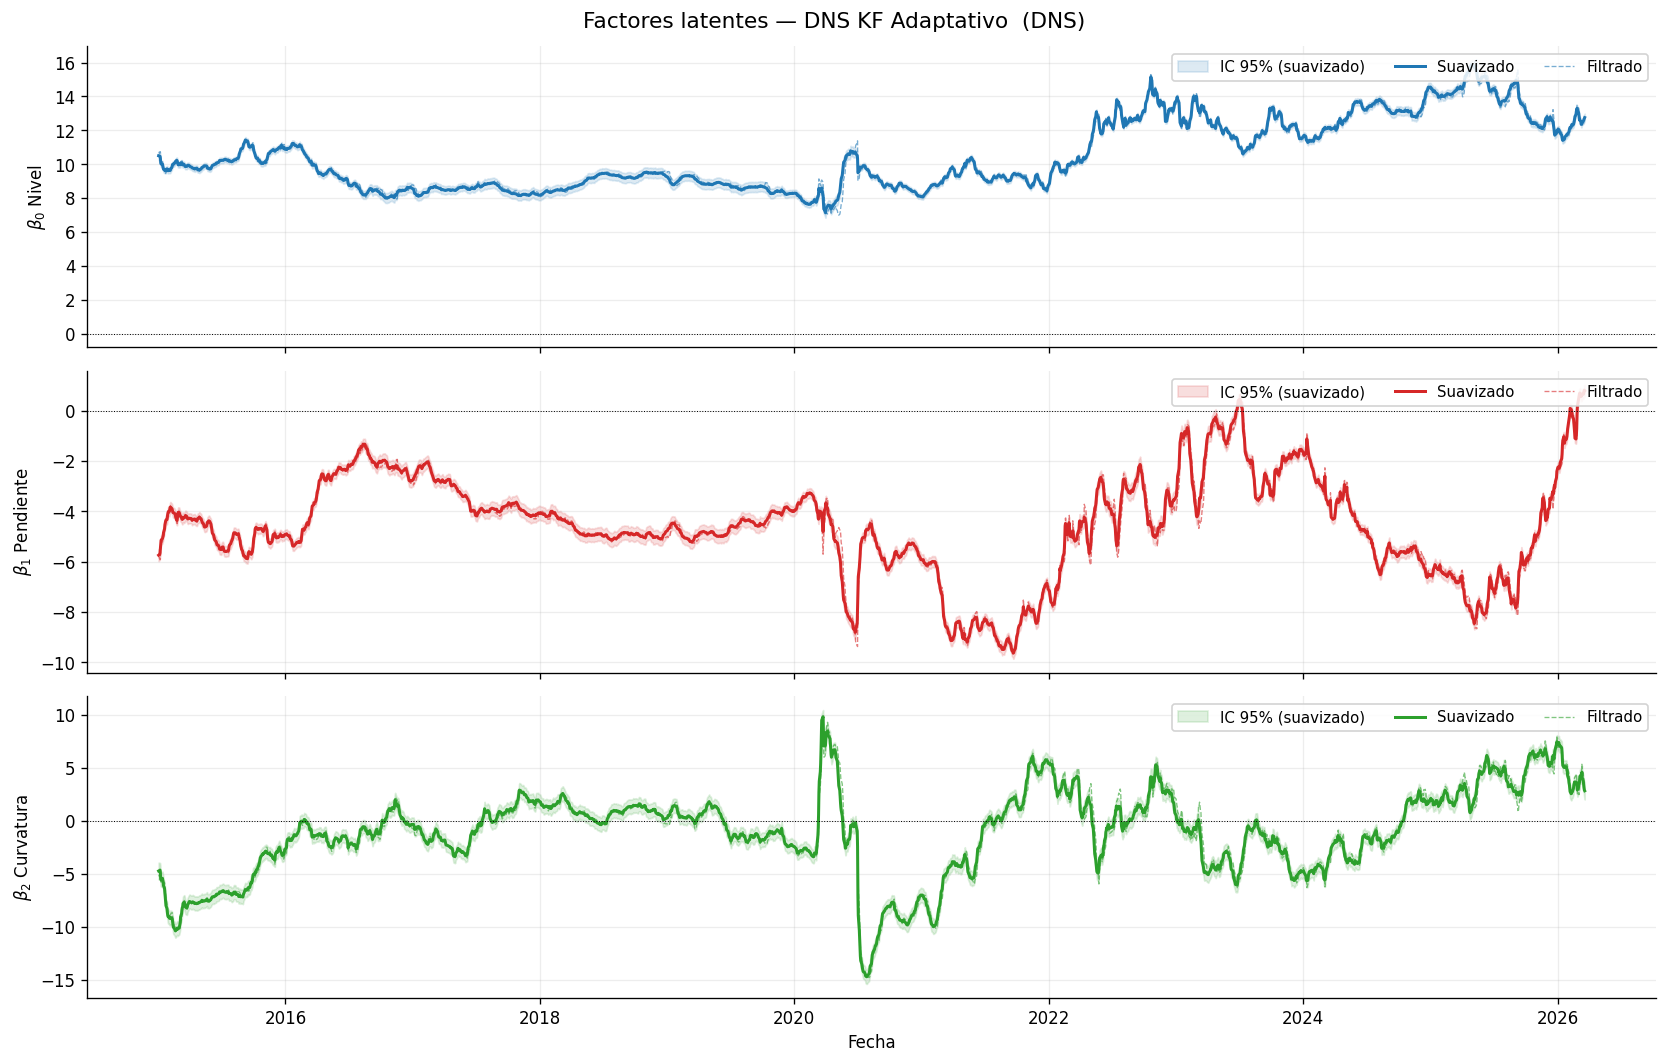


── Estadisticos de factores suavizados (DNS) ───────────────
Factor        Media    Std     Min     Q25     Med     Q75     Max
──────────────────────────────────────────────────────────────────
  $\beta_0$ Ni  +10.464   2.041   +7.130  +8.714  +9.701 +12.289 +15.876
  $\beta_1$ Pe   -4.559   1.995   -9.644  -5.574  -4.569  -3.336  +0.817
  $\beta_2$ Cu   -1.050   3.964  -14.731  -3.045  -0.709  +1.412  +9.819

── Autocorrelaciones lag-1 y lag-5 (suavizado) ─────────────────
  $\beta_0$ Nive  rho(1)=0.9993   rho(5)=0.9913
  $\beta_1$ Pend  rho(1)=0.9989   rho(5)=0.9836
  $\beta_2$ Curv  rho(1)=0.9984   rho(5)=0.9756


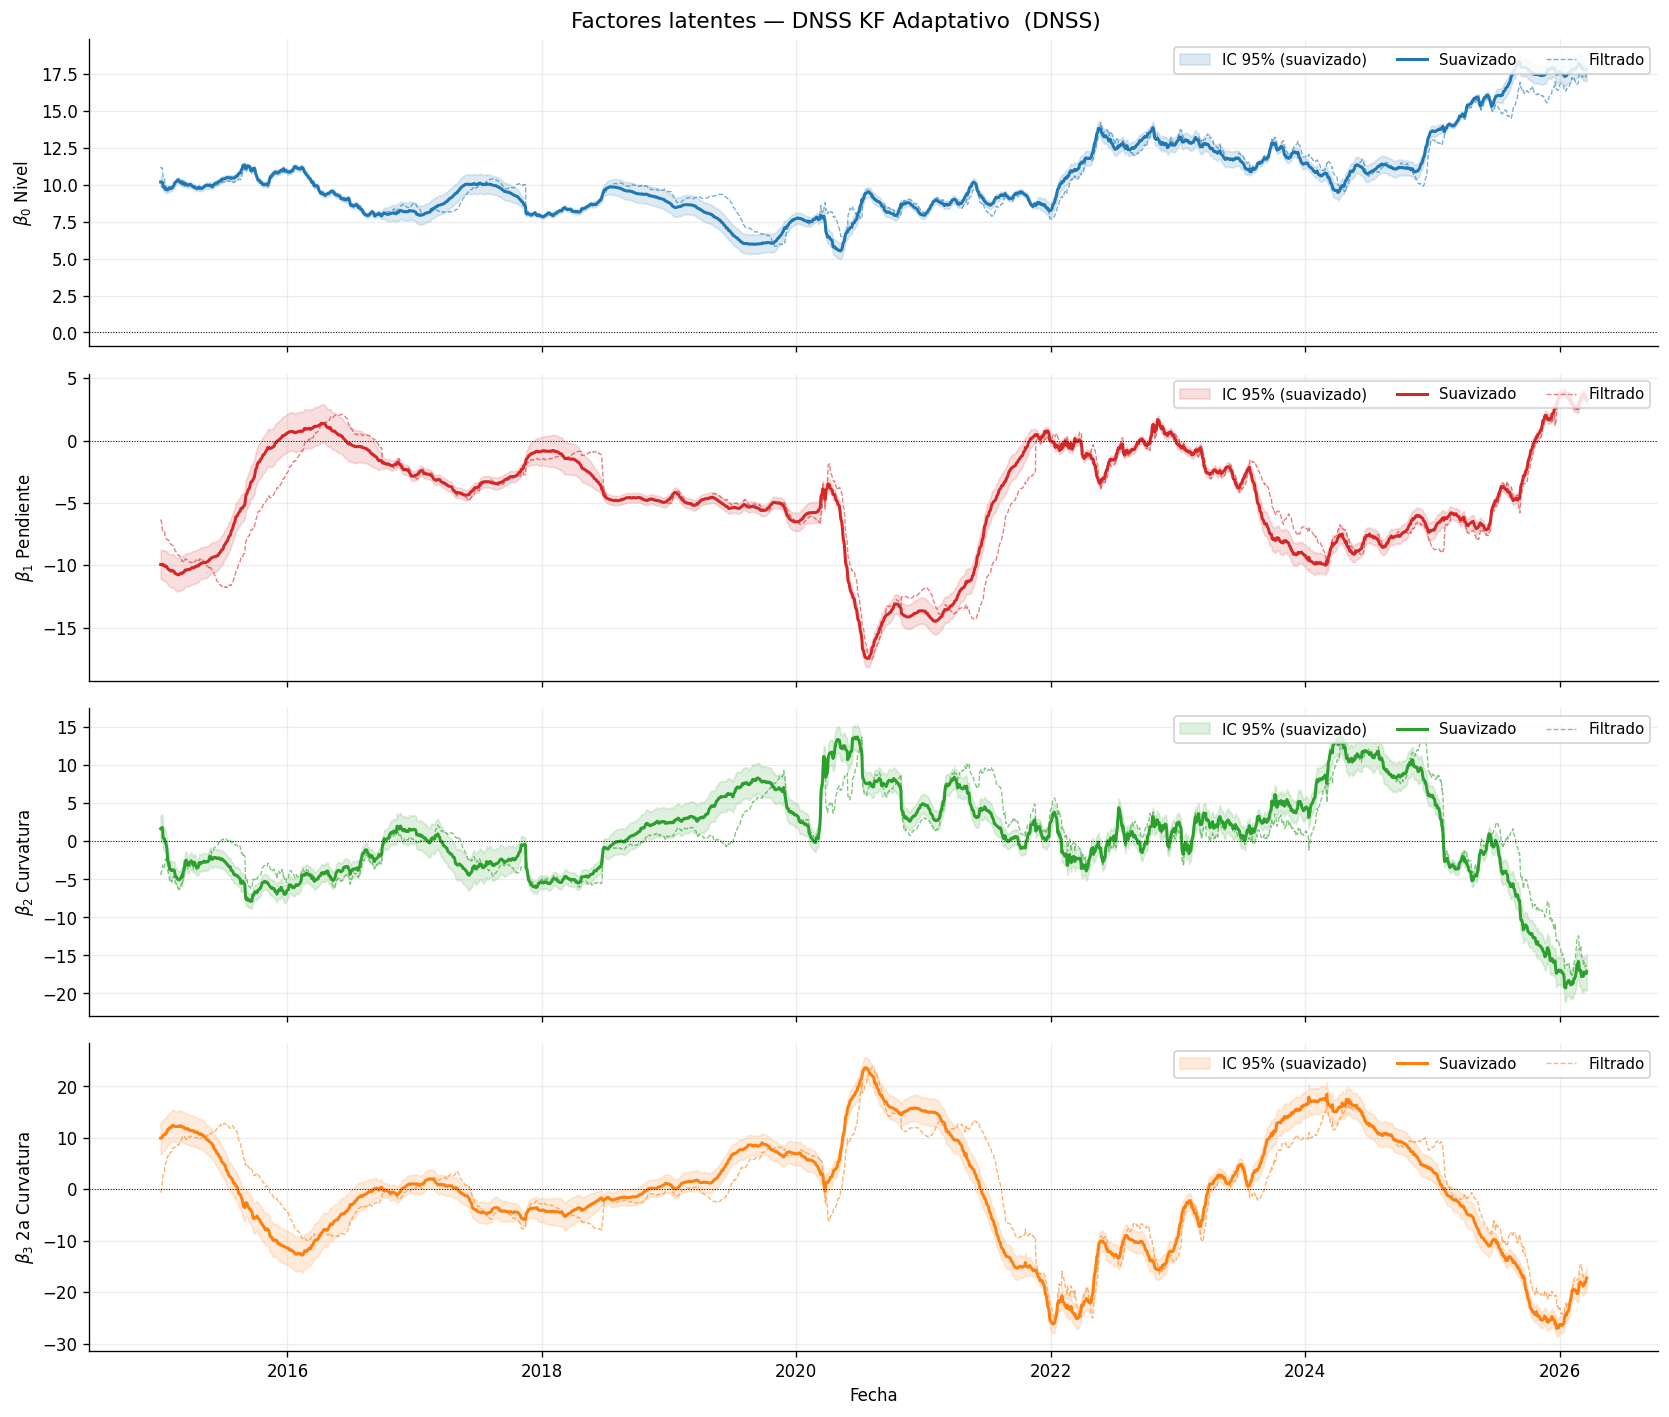


── Estadisticos de factores suavizados (DNSS) ───────────────
Factor        Media    Std     Min     Q25     Med     Q75     Max
──────────────────────────────────────────────────────────────────
  $\beta_0$ Ni  +10.425   2.751   +5.519  +8.548  +9.843 +11.707 +18.351
  $\beta_1$ Pe   -4.655   4.293  -17.484  -7.123  -4.369  -1.236  +3.868
  $\beta_2$ Cu   +0.649   6.087  -19.258  -3.199  +0.727  +4.282 +13.758
  $\beta_3$ 2a   -0.653  11.122  -27.074  -7.743  -0.158  +7.553 +23.616

── Autocorrelaciones lag-1 y lag-5 (suavizado) ─────────────────
  $\beta_0$ Nive  rho(1)=0.9998   rho(5)=0.9971
  $\beta_1$ Pend  rho(1)=0.9998   rho(5)=0.9963
  $\beta_2$ Curv  rho(1)=0.9991   rho(5)=0.9900
  $\beta_3$ 2a C  rho(1)=0.9998   rho(5)=0.9971


In [30]:
def plot_factores(res, titulo_extra=''):
    model  = res['model']
    dates  = res['dates']
    bf     = res['beta_filtered']
    bs     = res['beta_smoothed']
    Ps     = res['P_smoothed']
    k      = bf.shape[1]

    nombres = ([r'$\beta_0$ Nivel', r'$\beta_1$ Pendiente', r'$\beta_2$ Curvatura']
               + ([r'$\beta_3$ 2a Curvatura'] if k == 4 else []))

    fig, axes = plt.subplots(k, 1, figsize=(14, 3.0*k), sharex=True)
    if k == 1: axes = [axes]

    for i, (ax, nom, col) in enumerate(zip(axes, nombres, COLORES_FACTOR)):
        sd_s = np.sqrt(np.maximum(Ps[:, i, i], 0))

        ax.fill_between(dates,
                        bs[:, i] - 1.96*sd_s,
                        bs[:, i] + 1.96*sd_s,
                        alpha=0.15, color=col, label='IC 95% (suavizado)')
        ax.plot(dates, bs[:, i], color=col, lw=1.8, label='Suavizado')
        ax.plot(dates, bf[:, i], color=col, lw=0.8, ls='--',
                alpha=0.60, label='Filtrado')
        ax.axhline(0, color='k', lw=0.6, ls=':')
        ax.set_ylabel(nom, fontsize=10)
        ax.legend(loc='upper right', ncol=3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    axes[-1].set_xlabel('Fecha')
    fig.suptitle(f'Factores latentes — {model} KF Adaptativo  {titulo_extra}', fontsize=13)
    plt.tight_layout(); plt.show()

    # Estadisticos descriptivos
    print(f"\n── Estadisticos de factores suavizados ({model}) ───────────────")
    hdr = "Factor        Media    Std     Min     Q25     Med     Q75     Max"
    print(hdr); print("─"*len(hdr))
    for i, nom in enumerate(nombres):
        s = bs[:, i]
        print(f"  {nom[:12]:<12}  {s.mean():+7.3f}  {s.std():6.3f}"
              f"  {s.min():+7.3f} {np.percentile(s,25):+7.3f}"
              f" {np.median(s):+7.3f} {np.percentile(s,75):+7.3f}"
              f" {s.max():+7.3f}")

    print(f"\n── Autocorrelaciones lag-1 y lag-5 (suavizado) ─────────────────")
    for i, nom in enumerate(nombres):
        s   = bs[:, i]
        ac1 = np.corrcoef(s[:-1], s[1:])[0,1]
        ac5 = np.corrcoef(s[:-5], s[5:])[0,1] if len(s)>5 else np.nan
        print(f"  {nom[:14]:<14}  rho(1)={ac1:.4f}   rho(5)={ac5:.4f}")


plot_factores(res_dns,  '(DNS)')
plot_factores(res_dnss, '(DNSS)')


## CELDA 12: Analisis post-ajuste — Evolucion de $\tau_t$ adaptativo

$\tau_t$ captura cambios estructurales en la curvatura de la curva a lo largo del tiempo.
Su evolucion refleja periodos donde la politica monetaria o la liquidez desplaza el hump.


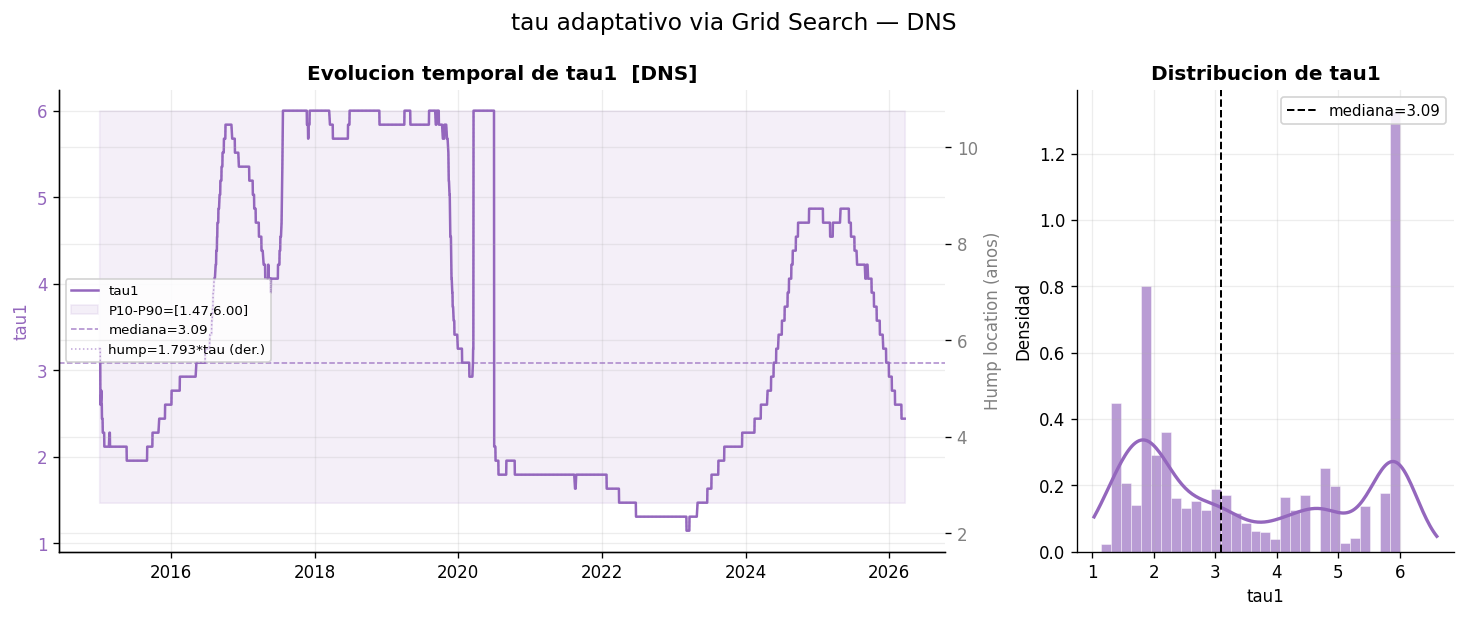


── Estadisticos de tau_t (DNS) ──────────────────────────────
  tau1: min=1.147  med=3.088  max=6.000  std=1.728  rho(1)=0.998
    hump: min=2.06Y  med=5.54Y  max=10.76Y


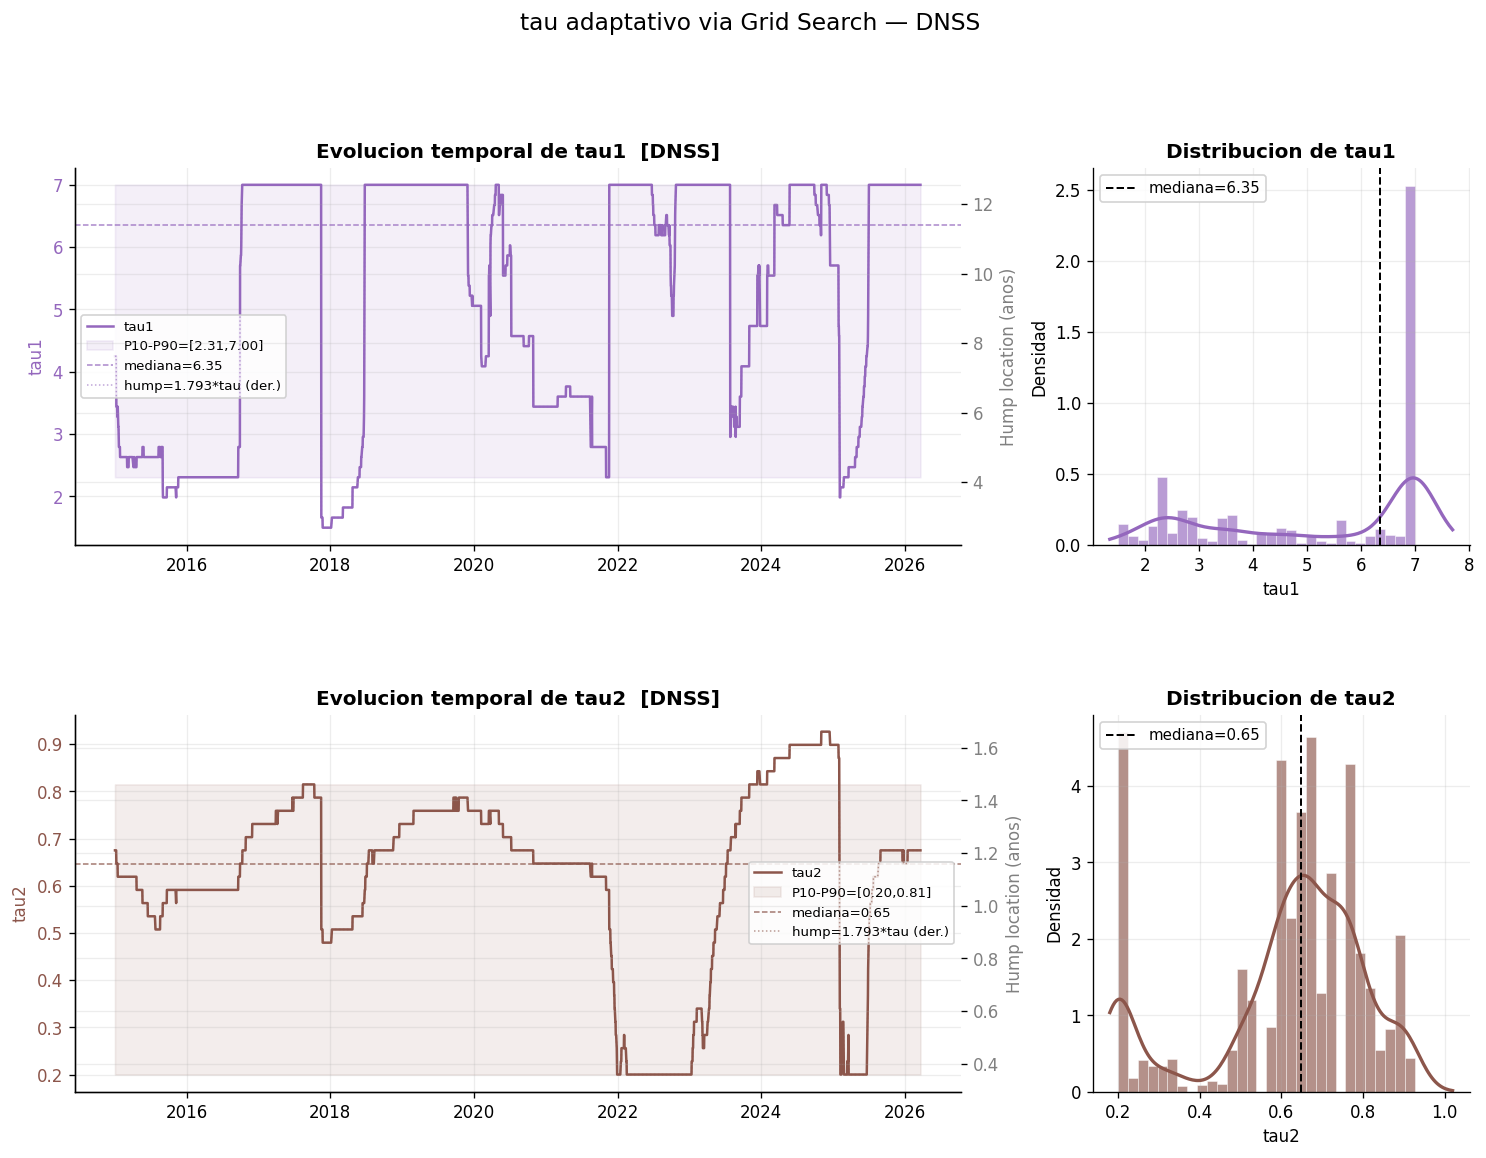


── Estadisticos de tau_t (DNSS) ──────────────────────────────
  tau1: min=1.500  med=6.353  max=7.000  std=2.009  rho(1)=0.994
    hump: min=2.69Y  med=11.39Y  max=12.55Y
  tau2: min=0.200  med=0.647  max=0.926  std=0.197  rho(1)=0.997
    hump: min=0.36Y  med=1.16Y  max=1.66Y


In [31]:
def plot_tau_evolution(res):
    model  = res['model']
    dates  = res['dates']
    tau1_t = res['tau1_t']
    tau2_t = res['tau2_t']

    n_tau = 1 if model == 'DNS' else 2
    taus  = [tau1_t] if model == 'DNS' else [tau1_t, tau2_t]
    lbls  = ['tau1']  if model == 'DNS' else ['tau1', 'tau2']

    fig = plt.figure(figsize=(15, 5*n_tau))
    gs  = gridspec.GridSpec(n_tau, 3, figure=fig, wspace=0.35, hspace=0.45)

    for row, (tau_t, lbl, col) in enumerate(zip(taus, lbls, COLORES_TAU)):
        hump_t = 1.793 * tau_t
        p10, p90 = np.percentile(tau_t, [10, 90])

        # Serie de tiempo
        ax1 = fig.add_subplot(gs[row, :2])
        ax1.plot(dates, tau_t, color=col, lw=1.5, label=f'{lbl}')
        ax1.fill_between(dates, p10, p90, alpha=0.10, color=col,
                         label=f'P10-P90=[{p10:.2f},{p90:.2f}]')
        ax1.axhline(np.median(tau_t), color=col, lw=0.9, ls='--',
                    alpha=0.8, label=f'mediana={np.median(tau_t):.2f}')

        ax2 = ax1.twinx()
        ax2.plot(dates, hump_t, color=col, lw=0.9, ls=':', alpha=0.6,
                 label='hump=1.793*tau (der.)')
        ax1.set_ylabel(f'{lbl}', color=col)
        ax1.tick_params(axis='y', labelcolor=col)
        ax2.set_ylabel('Hump location (anos)', color='gray')
        ax2.tick_params(axis='y', labelcolor='gray')
        ax1.set_title(f'Evolucion temporal de {lbl}  [{model}]')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1+h2, l1+l2, fontsize=8, loc='best')

        # Distribucion
        ax3 = fig.add_subplot(gs[row, 2])
        ax3.hist(tau_t, bins=30, color=col, alpha=0.65, density=True,
                 edgecolor='white', lw=0.4)
        try:
            kde_x = np.linspace(tau_t.min()*0.9, tau_t.max()*1.1, 200)
            ax3.plot(kde_x, stats.gaussian_kde(tau_t)(kde_x), color=col, lw=2.0)
        except Exception:
            pass
        ax3.axvline(np.median(tau_t), color='k', lw=1.2, ls='--',
                    label=f'mediana={np.median(tau_t):.2f}')
        ax3.set_xlabel(f'{lbl}'); ax3.set_ylabel('Densidad')
        ax3.set_title(f'Distribucion de {lbl}'); ax3.legend(fontsize=9)

    fig.suptitle(f'tau adaptativo via Grid Search — {model}', fontsize=14, y=1.01)
    plt.show()

    # Estadisticos
    print(f"\n── Estadisticos de tau_t ({model}) ──────────────────────────────")
    for tau_t, lbl in zip(taus, lbls):
        h = 1.793 * tau_t
        ac1 = np.corrcoef(tau_t[:-1], tau_t[1:])[0,1]
        print(f"  {lbl}: min={tau_t.min():.3f}  med={np.median(tau_t):.3f}  "
              f"max={tau_t.max():.3f}  std={tau_t.std():.3f}  rho(1)={ac1:.3f}")
        print(f"    hump: min={h.min():.2f}Y  med={np.median(h):.2f}Y  max={h.max():.2f}Y")


plot_tau_evolution(res_dns)
plot_tau_evolution(res_dnss)


## CELDA 13: Analisis post-ajuste — Curva ajustada y heatmap de residuos

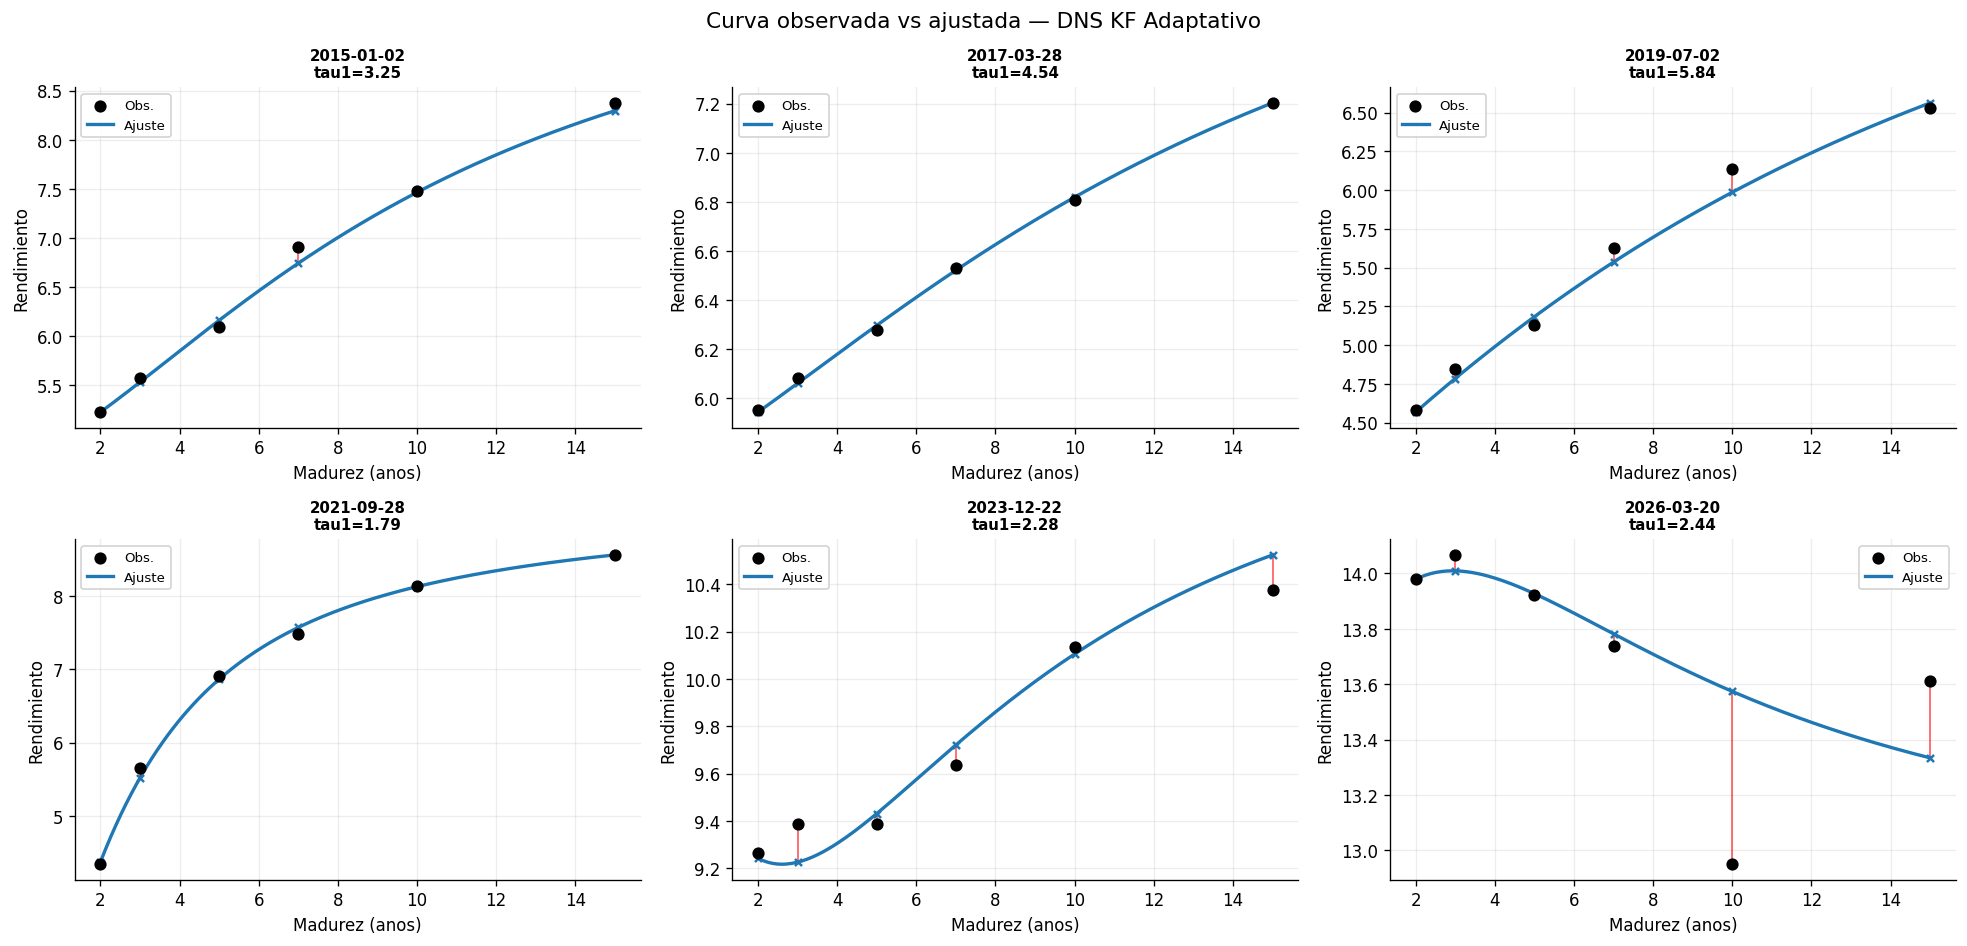

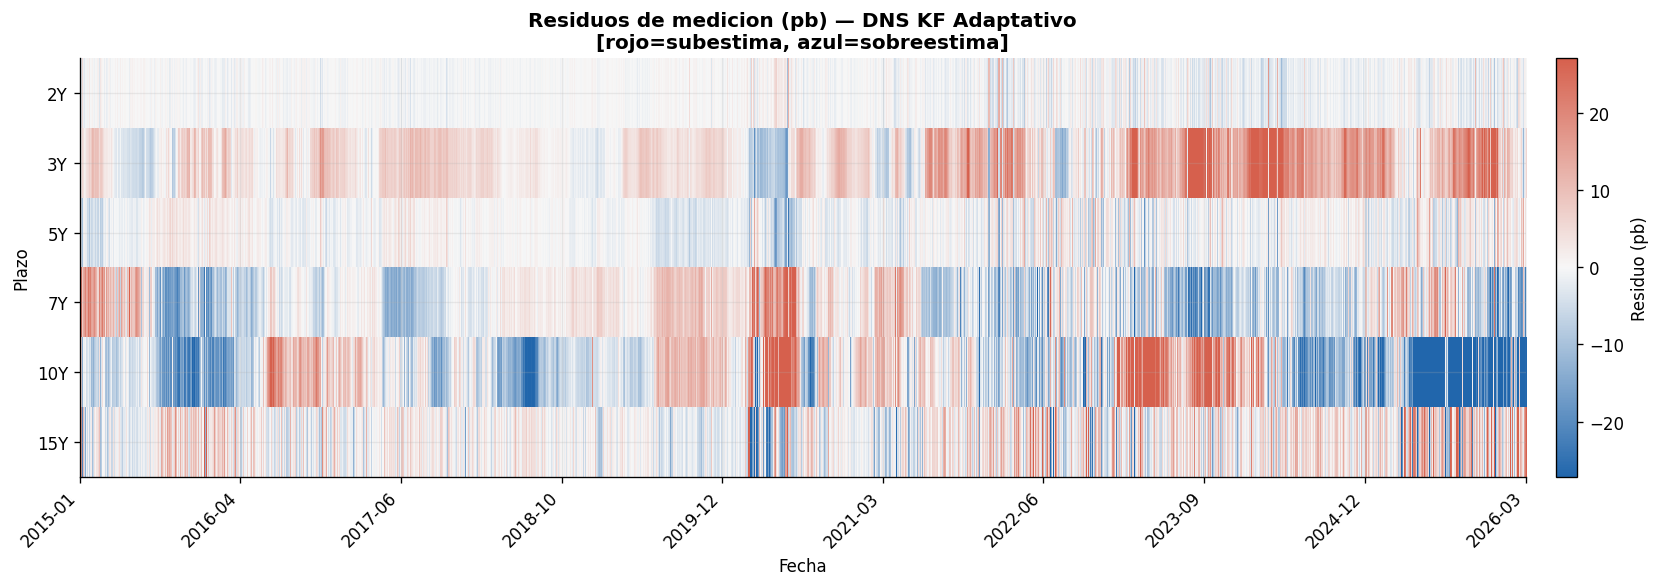

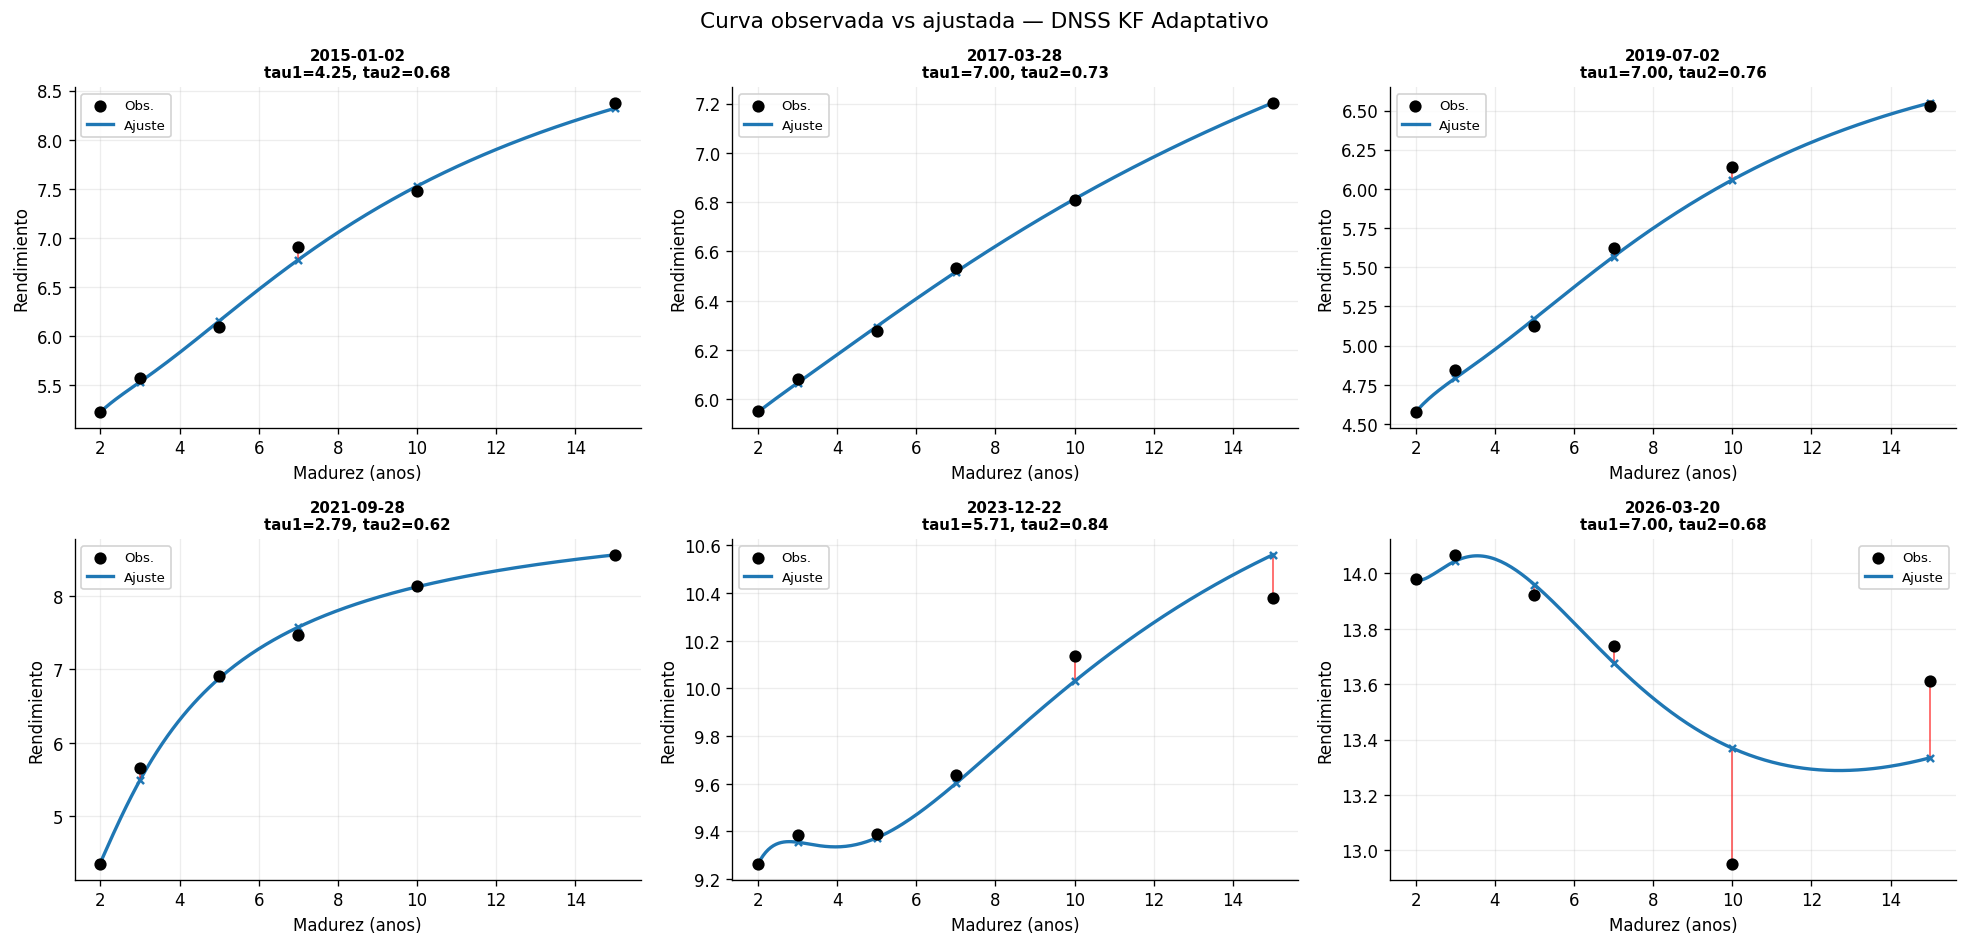

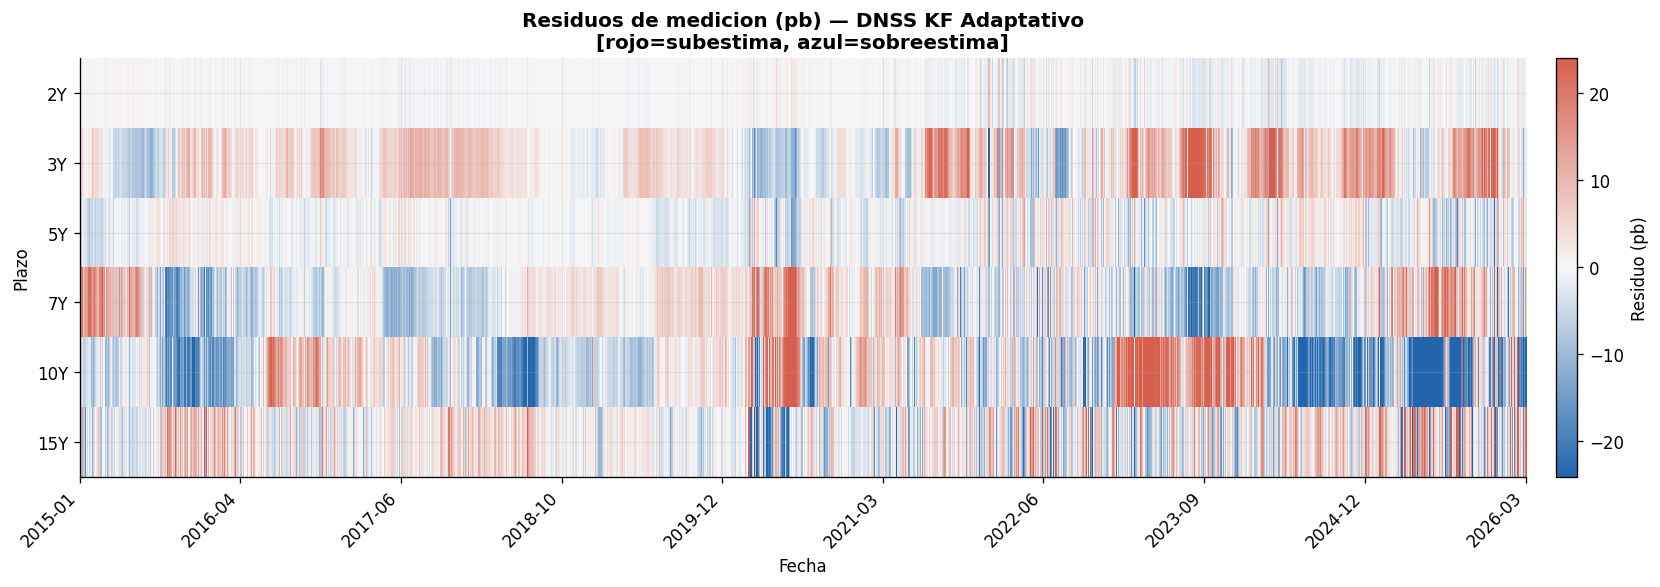

In [32]:
def plot_curvas_ajustadas(res, n_fechas=6):
    model   = res['model']
    dates   = res['dates']
    yields  = res['yields']
    fitted  = res['fitted']
    resid   = res['residuals']
    mats    = res['maturities']
    tau1_t  = res['tau1_t']
    tau2_t  = res['tau2_t']
    T       = len(dates)

    idx_sel = np.unique(np.linspace(0, T-1, n_fechas, dtype=int))
    m_fine  = np.linspace(mats.min(), mats.max(), 200)

    cols = min(3, n_fechas)
    rows = (n_fechas + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5.5*cols, 4.0*rows))
    axes = np.array(axes).flatten()

    for ax, idx in zip(axes[:n_fechas], idx_sel):
        tau1    = tau1_t[idx]
        tau2    = tau2_t[idx] if model=='DNSS' and not np.isnan(tau2_t[idx]) else None
        beta_t  = res['beta_smoothed'][idx]

        H_fine = ns_loadings(m_fine, tau1) if model=='DNS' \
                 else nss_loadings(m_fine, tau1, tau2)
        curve  = H_fine @ beta_t

        # Observados y ajustados en mats discretas
        fit_disc = res['H_arr'][idx] @ beta_t

        ax.scatter(mats, yields[idx], color='k', s=40, zorder=5, label='Obs.')
        ax.plot(m_fine, curve, color='#1f77b4', lw=2.0, label='Ajuste')
        ax.scatter(mats, fit_disc, color='#1f77b4', s=18, marker='x', zorder=4)
        for mi, fi, oi in zip(mats, fit_disc, yields[idx]):
            ax.plot([mi, mi], [fi, oi], color='red', lw=1.0, alpha=0.65)

        tau_str = f'tau1={tau1:.2f}' if model=='DNS' else f'tau1={tau1:.2f}, tau2={tau2:.2f}'
        ax.set_title(f'{str(dates[idx])[:10]}\n{tau_str}', fontsize=9)
        ax.set_xlabel('Madurez (anos)'); ax.set_ylabel('Rendimiento')
        ax.legend(fontsize=8)

    for ax in axes[n_fechas:]:
        ax.set_visible(False)
    fig.suptitle(f'Curva observada vs ajustada — {model} KF Adaptativo', fontsize=13)
    plt.tight_layout(); plt.show()


def plot_heatmap_residuos(res):
    model = res['model']
    dates = res['dates']
    resid = res['residuals'] * 100   # puntos basicos
    mats  = res['maturities']
    T     = len(dates)

    fig, ax = plt.subplots(figsize=(14, 5))
    vmax = np.percentile(np.abs(resid), 97)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = LinearSegmentedColormap.from_list('bwr_soft', ['#2166ac','#f7f7f7','#d6604d'], N=256)

    im = ax.imshow(resid.T, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')

    n_t = min(10, T//40+1)
    t_ticks = np.linspace(0, T-1, n_t, dtype=int)
    ax.set_xticks(t_ticks)
    ax.set_xticklabels([str(dates[i])[:7] for i in t_ticks], rotation=45, ha='right')
    ax.set_yticks(range(len(mats)))
    ax.set_yticklabels([f'{m:.0f}Y' for m in mats])
    ax.set_xlabel('Fecha'); ax.set_ylabel('Plazo')
    ax.set_title(f'Residuos de medicion (pb) — {model} KF Adaptativo\n'
                 f'[rojo=subestima, azul=sobreestima]')
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='Residuo (pb)')
    plt.tight_layout(); plt.show()


plot_curvas_ajustadas(res_dns,  n_fechas=6)
plot_heatmap_residuos(res_dns)
plot_curvas_ajustadas(res_dnss, n_fechas=6)
plot_heatmap_residuos(res_dnss)


## CELDA 14: Analisis post-ajuste — Residuos de medicion

1. **RMSE y MAE por plazo** — que plazos ajusta mejor/peor?
2. **Sesgo y correlacion cruzada** entre residuos por plazo
3. **Distribucion** — prueba de normalidad Jarque-Bera
4. **QQ plot** — diagnostico de colas
5. **ACF** — autocorrelacion residual (Ljung-Box)


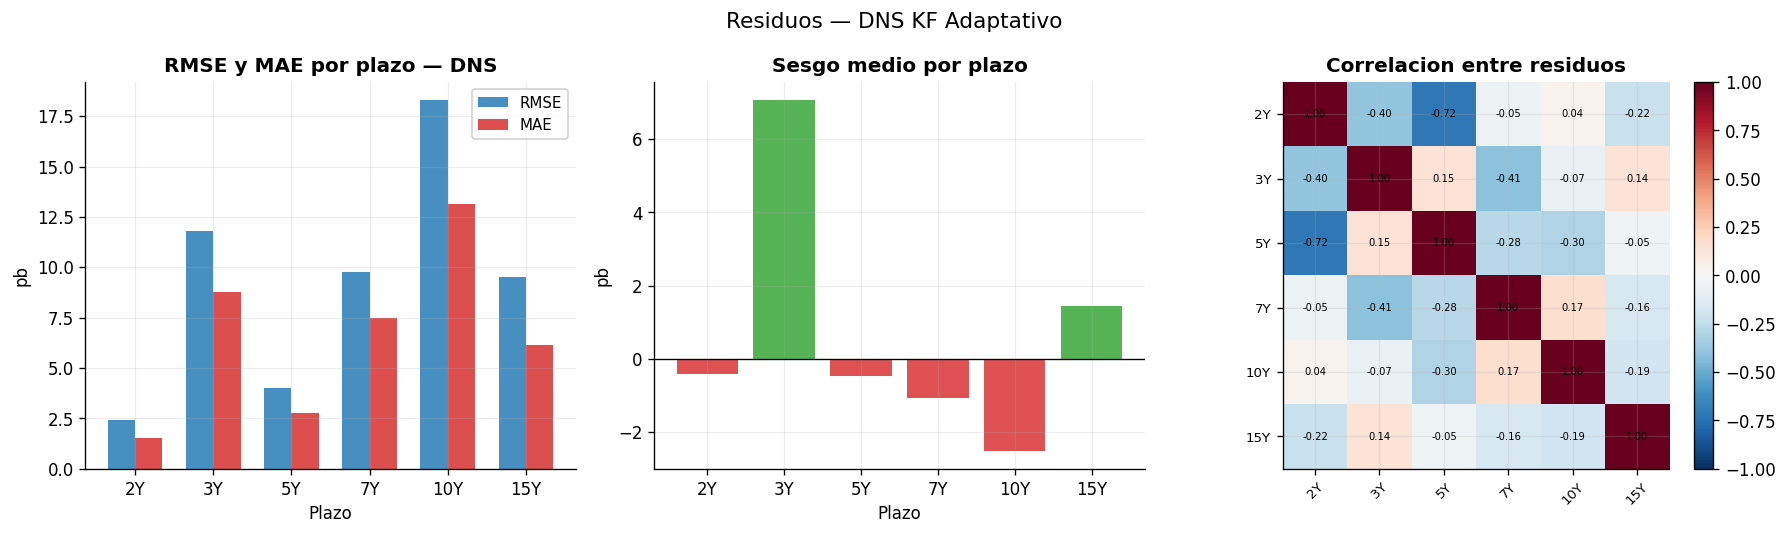

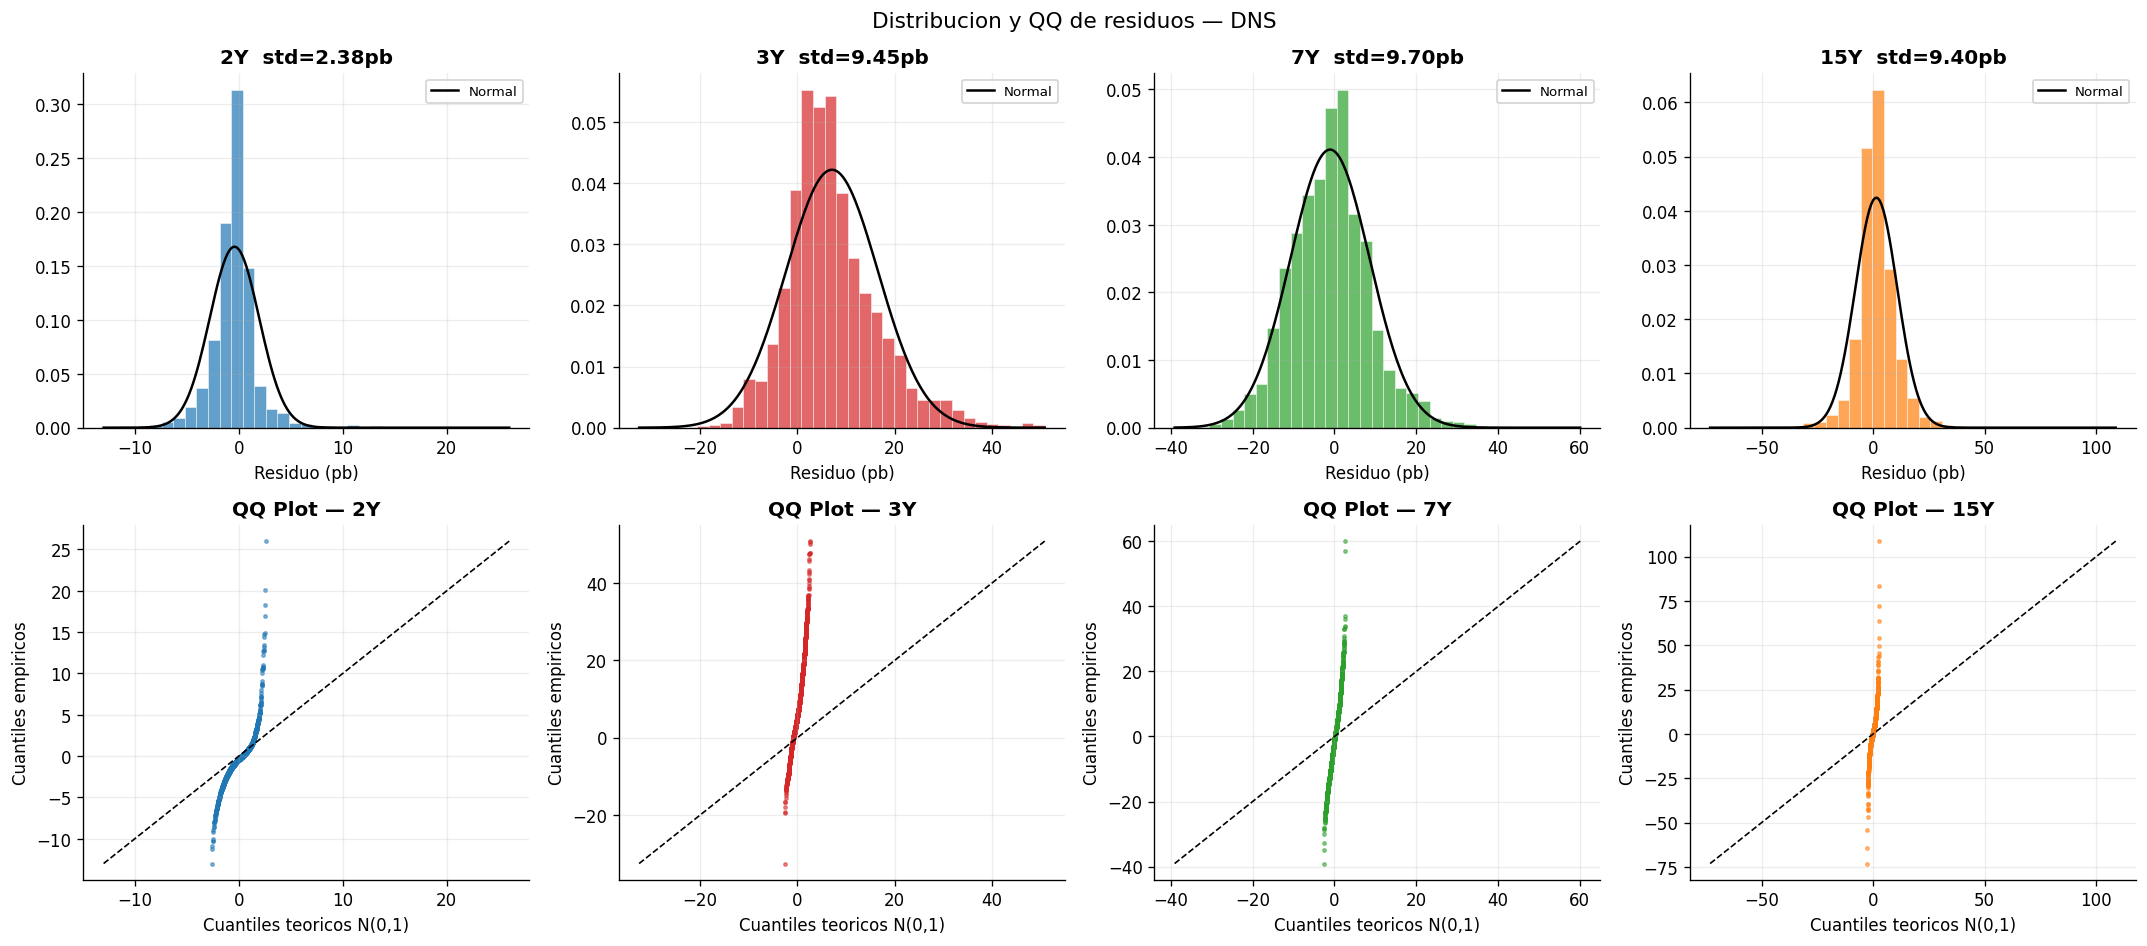

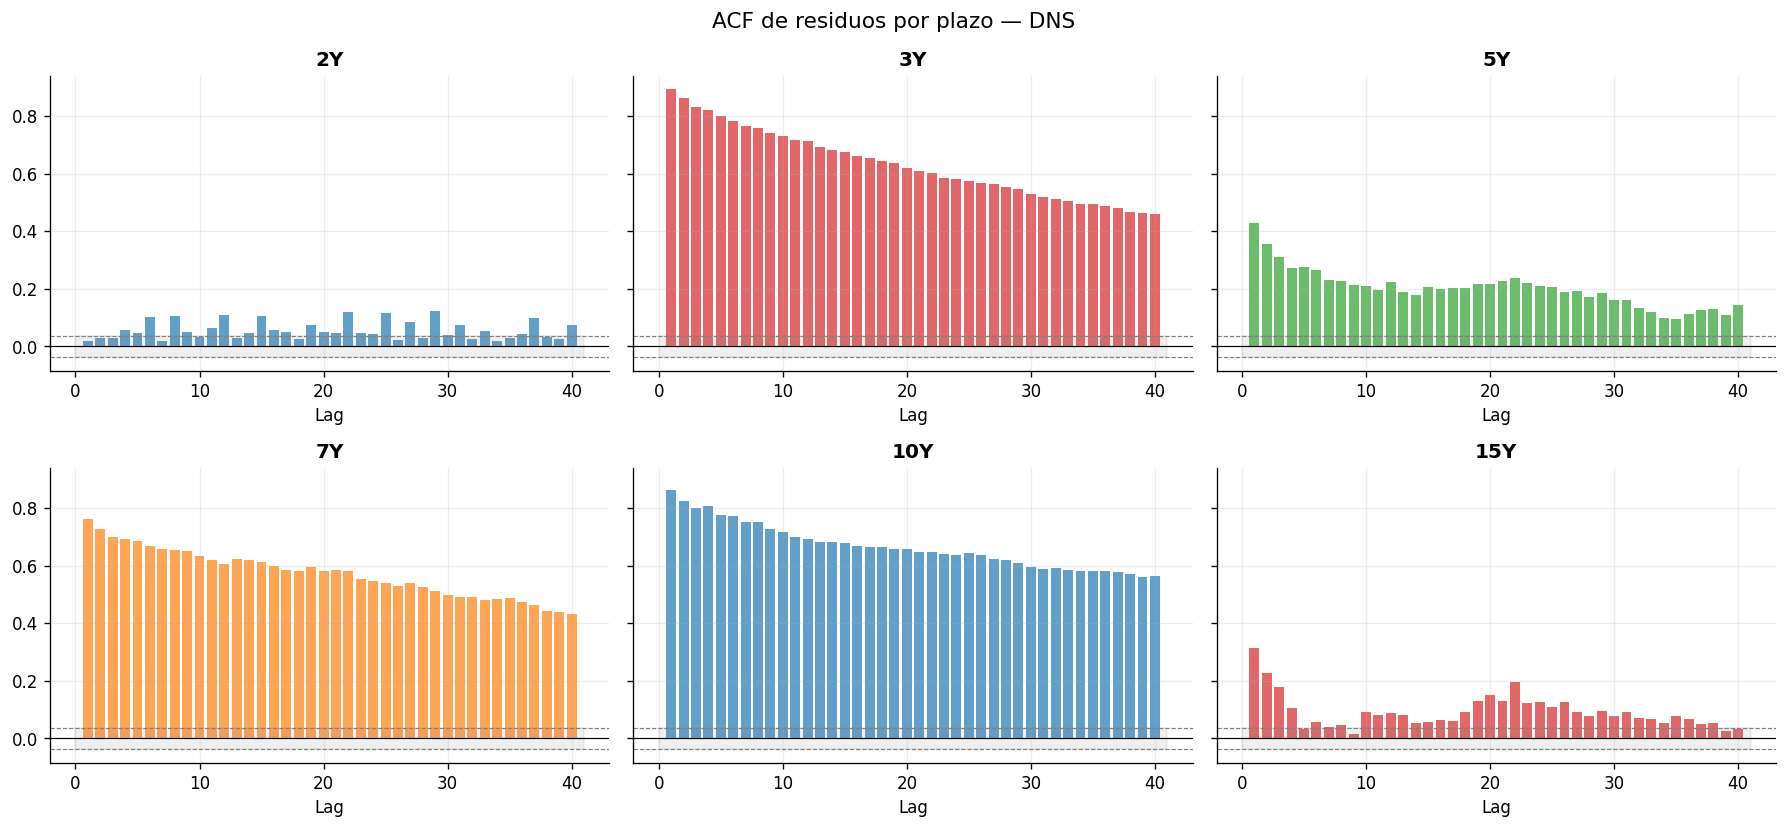


── Tests de residuos — DNS ────────────────────────────────────────
  Plazo      RMSE     Sesgo   JB p-val   LB(10)p  Normal?  SerialCorr?
  ────────────────────────────────────────────────────────────────────────
     2Y     2.412    -0.412     0.0000    0.0000  No      Si
     3Y    11.813    +7.084     0.0000    0.0000  No      Si
     5Y     4.007    -0.469     0.0000    0.0000  No      Si
     7Y     9.764    -1.080     0.0000    0.0000  No      Si
    10Y    18.286    -2.526     0.0000    0.0000  No      Si
    15Y     9.512    +1.437     0.0000    0.0000  No      Si


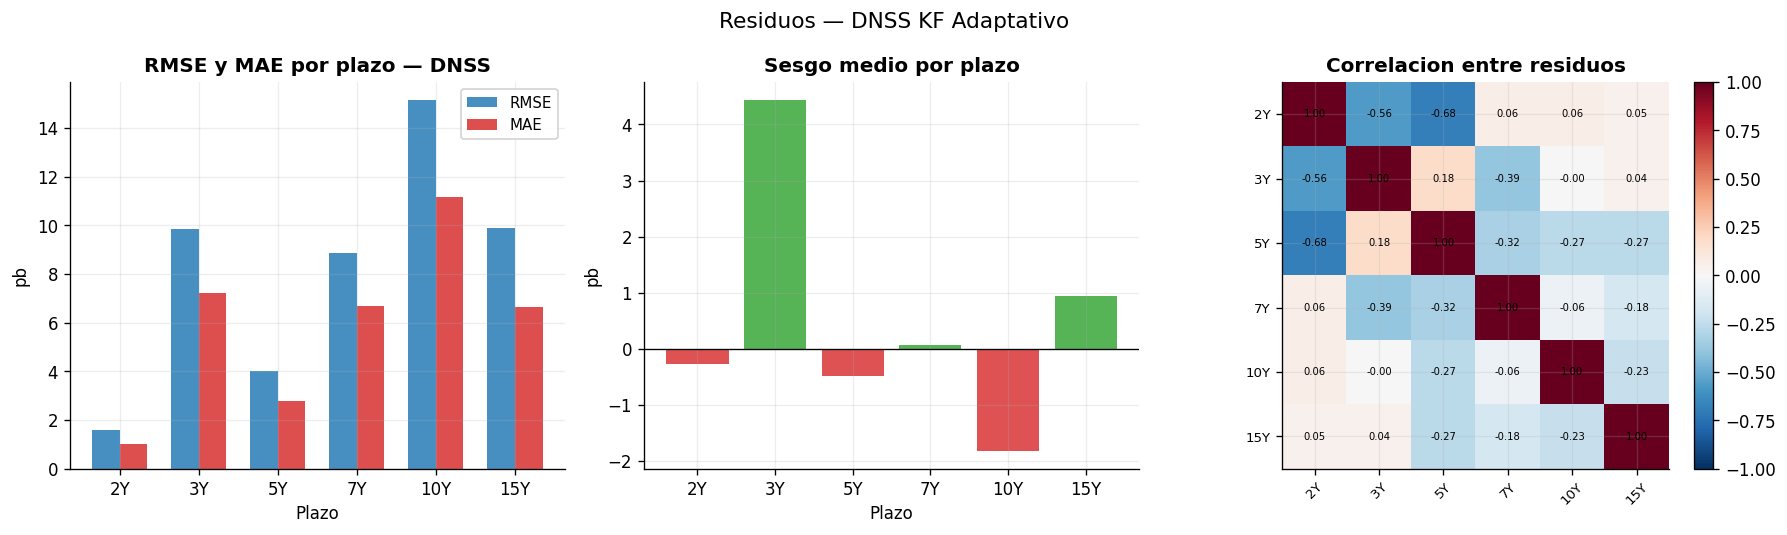

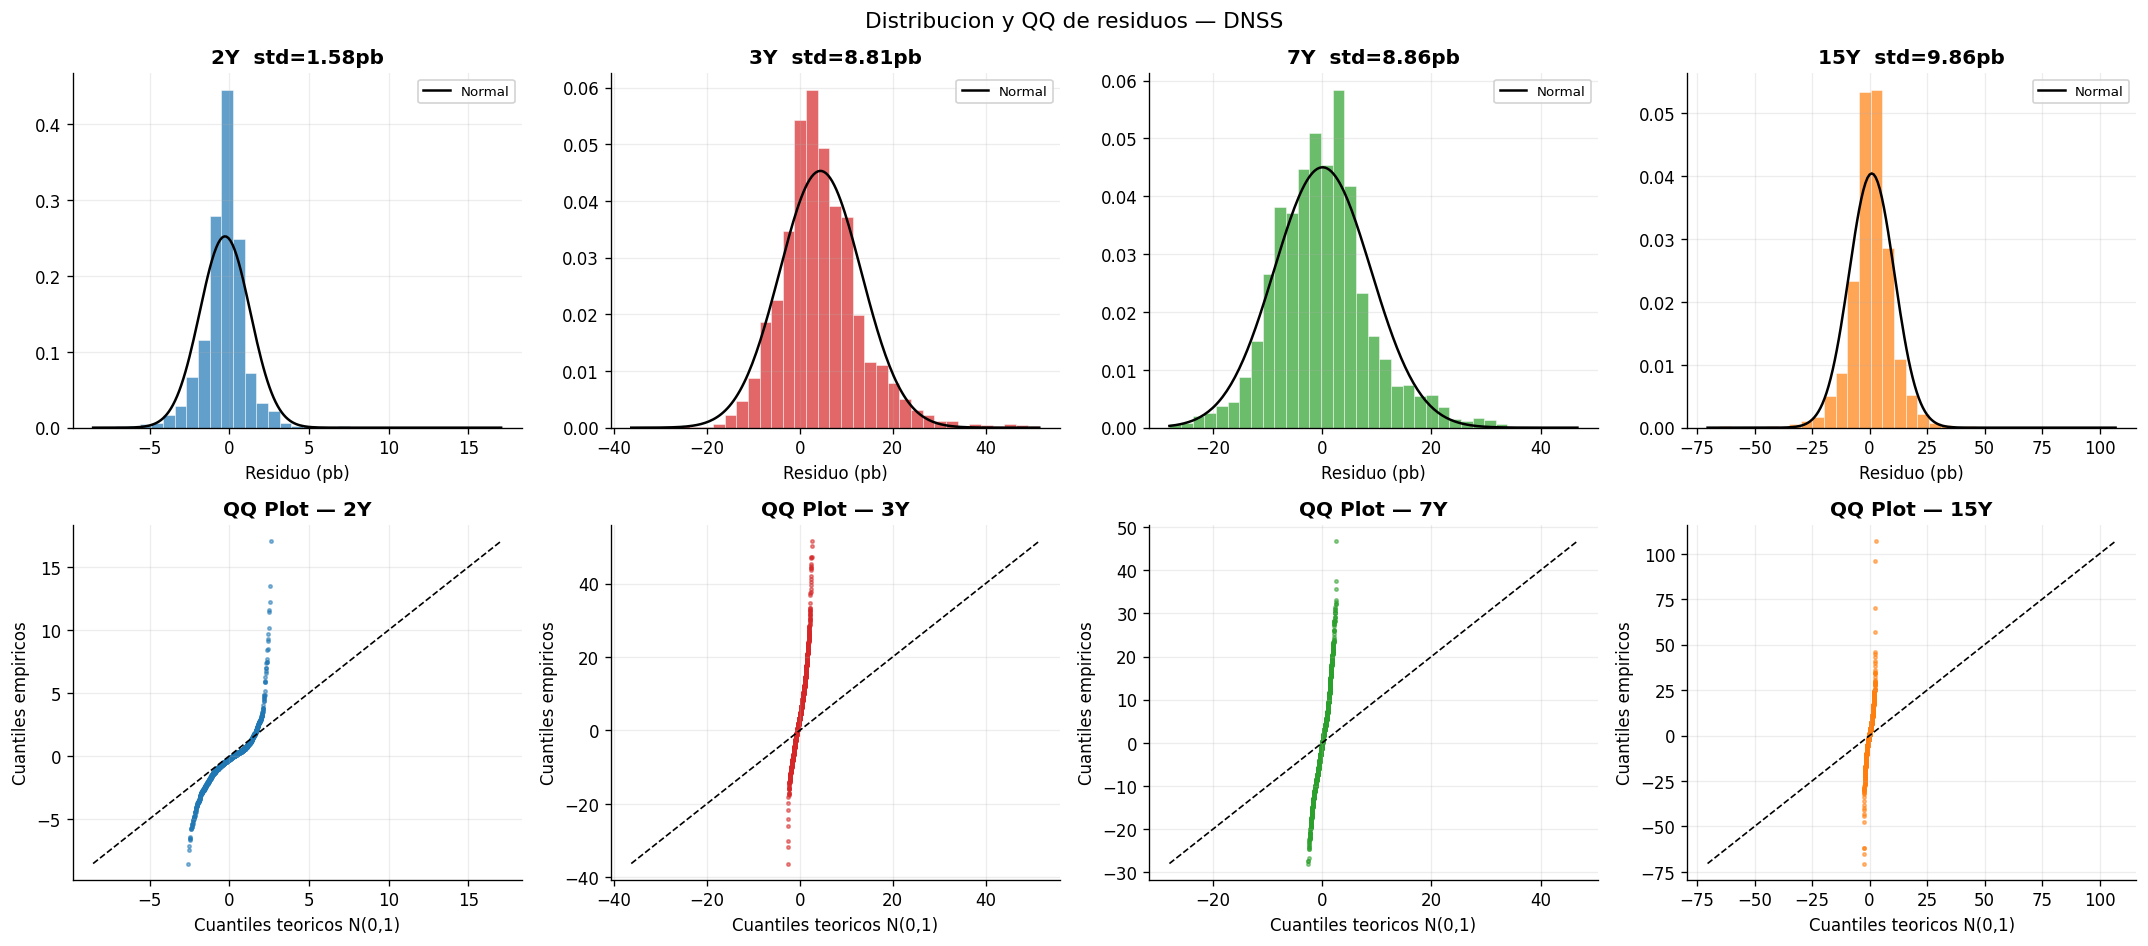

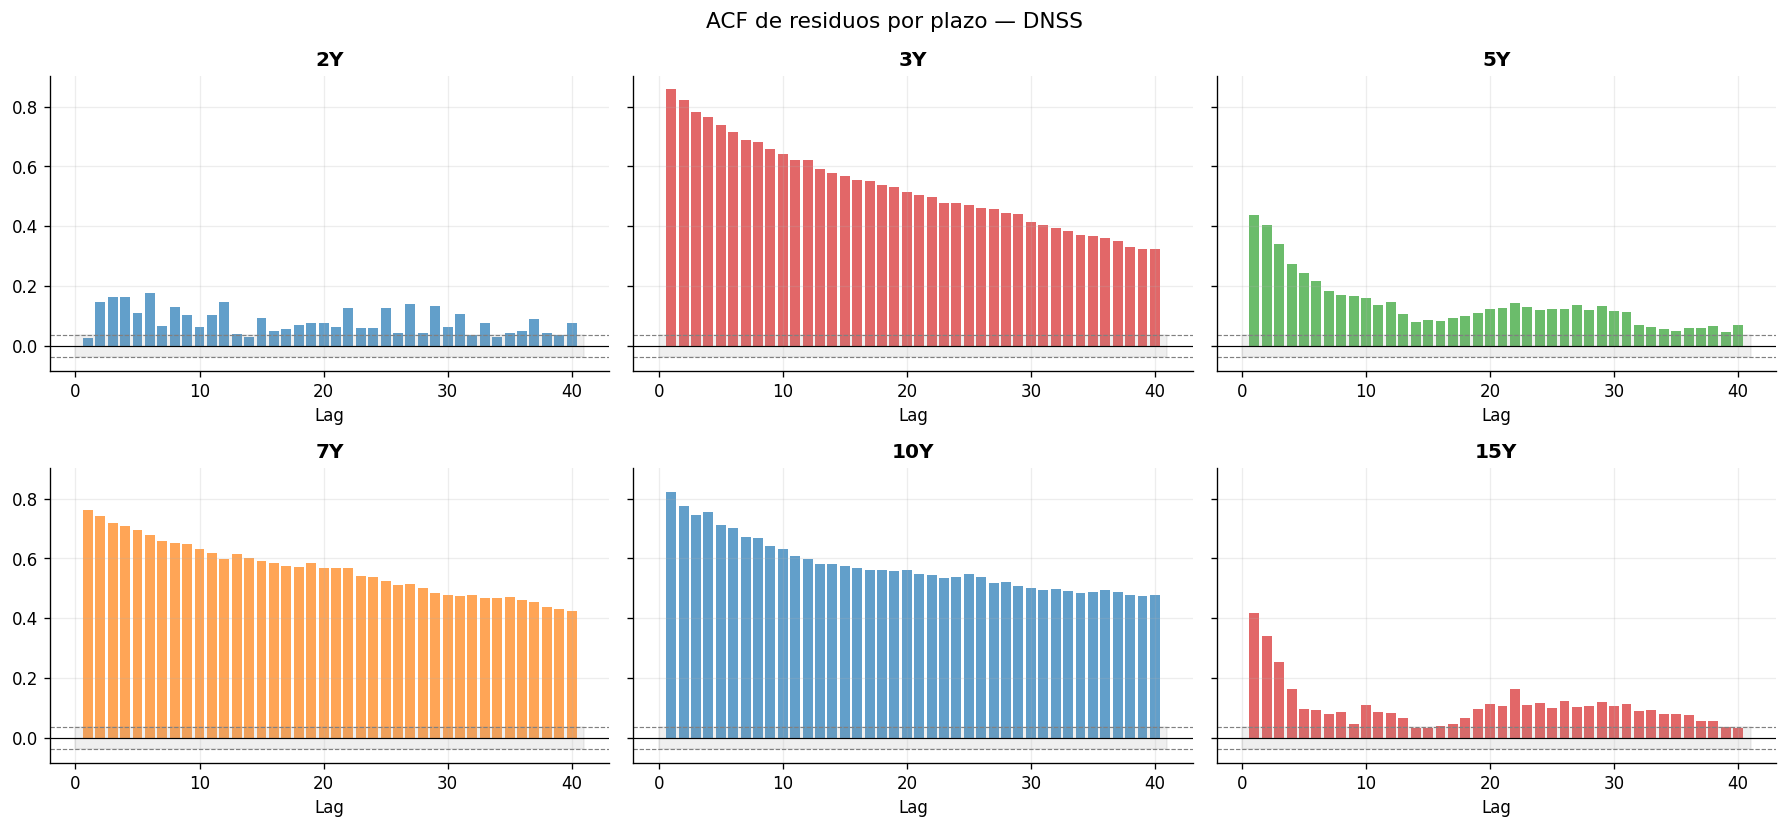


── Tests de residuos — DNSS ────────────────────────────────────────
  Plazo      RMSE     Sesgo   JB p-val   LB(10)p  Normal?  SerialCorr?
  ────────────────────────────────────────────────────────────────────────
     2Y     1.608    -0.280     0.0000    0.0000  No      Si
     3Y     9.865    +4.444     0.0000    0.0000  No      Si
     5Y     4.027    -0.494     0.0000    0.0000  No      Si
     7Y     8.865    +0.068     0.0000    0.0000  No      Si
    10Y    15.141    -1.827     0.0000    0.0000  No      Si
    15Y     9.909    +0.933     0.0000    0.0000  No      Si


In [33]:
def analisis_residuos(res):
    model  = res['model']
    dates  = res['dates']
    resid  = res['residuals']
    mats   = res['maturities']
    T, N   = resid.shape
    pb     = resid * 100

    rmse_m = np.sqrt(np.mean(resid**2, axis=0)) * 100
    mae_m  = np.mean(np.abs(resid),    axis=0)  * 100
    bias_m = resid.mean(axis=0)                 * 100

    # ── (1) RMSE, MAE, Sesgo y correlacion cruzada ───────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    x = np.arange(N); w = 0.35

    axes[0].bar(x-w/2, rmse_m, w, label='RMSE', color='#1f77b4', alpha=0.82)
    axes[0].bar(x+w/2, mae_m,  w, label='MAE',  color='#d62728', alpha=0.82)
    axes[0].set_xticks(x); axes[0].set_xticklabels([f'{m:.0f}Y' for m in mats])
    axes[0].set_xlabel('Plazo'); axes[0].set_ylabel('pb')
    axes[0].set_title(f'RMSE y MAE por plazo — {model}'); axes[0].legend()

    col_bias = ['#2ca02c' if b >= 0 else '#d62728' for b in bias_m]
    axes[1].bar(x, bias_m, color=col_bias, alpha=0.8)
    axes[1].axhline(0, color='k', lw=0.8)
    axes[1].set_xticks(x); axes[1].set_xticklabels([f'{m:.0f}Y' for m in mats])
    axes[1].set_xlabel('Plazo'); axes[1].set_ylabel('pb')
    axes[1].set_title('Sesgo medio por plazo')

    corr_r = np.corrcoef(resid.T)
    im = axes[2].imshow(corr_r, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[2].set_xticks(range(N)); axes[2].set_yticks(range(N))
    axes[2].set_xticklabels([f'{m:.0f}Y' for m in mats], rotation=45, fontsize=8)
    axes[2].set_yticklabels([f'{m:.0f}Y' for m in mats], fontsize=8)
    axes[2].set_title('Correlacion entre residuos')
    plt.colorbar(im, ax=axes[2], fraction=0.04)
    for ii in range(N):
        for jj in range(N):
            axes[2].text(jj, ii, f'{corr_r[ii,jj]:.2f}',
                         ha='center', va='center', fontsize=6)
    plt.suptitle(f'Residuos — {model} KF Adaptativo', fontsize=13)
    plt.tight_layout(); plt.show()

    # ── (2) Histograma + QQ por plazo seleccionado ───────────────────────────
    n_show = min(4, N)
    idx_m  = np.linspace(0, N-1, n_show, dtype=int)

    fig, axes = plt.subplots(2, n_show, figsize=(4.5*n_show, 8))
    for col_i, i in enumerate(idx_m):
        r = pb[:, i]
        # Histograma
        ax = axes[0, col_i]
        ax.hist(r, bins=35, density=True, color=COLORES_FACTOR[col_i%4],
                alpha=0.70, edgecolor='white', lw=0.4)
        x_r = np.linspace(r.min(), r.max(), 200)
        ax.plot(x_r, stats.norm.pdf(x_r, r.mean(), r.std()),
                'k-', lw=1.5, label='Normal')
        ax.set_title(f'{mats[i]:.0f}Y  std={r.std():.2f}pb')
        ax.set_xlabel('Residuo (pb)'); ax.legend(fontsize=8)
        # QQ
        ax = axes[1, col_i]
        q_theo = stats.norm.ppf(np.linspace(0.005, 0.995, T))
        q_emp  = np.sort(r)
        ax.scatter(q_theo, q_emp, s=4, alpha=0.5, color=COLORES_FACTOR[col_i%4])
        lim = (min(q_theo.min(), q_emp.min()), max(q_theo.max(), q_emp.max()))
        ax.plot(lim, lim, 'k--', lw=1.0)
        ax.set_xlabel('Cuantiles teoricos N(0,1)'); ax.set_ylabel('Cuantiles empiricos')
        ax.set_title(f'QQ Plot — {mats[i]:.0f}Y')

    plt.suptitle(f'Distribucion y QQ de residuos — {model}', fontsize=13)
    plt.tight_layout(); plt.show()

    # ── (3) ACF de residuos ───────────────────────────────────────────────────
    max_lag = min(40, T//4)
    lags    = np.arange(1, max_lag+1)
    ci_val  = 1.96 / np.sqrt(T)
    n_cols  = (N+1)//2

    fig, axes = plt.subplots(2, n_cols, figsize=(5*n_cols, 7), sharey=True)
    axes = axes.flatten()

    for i in range(N):
        ax    = axes[i]
        r     = resid[:, i]
        r_std = (r - r.mean()) / r.std()
        acf   = np.array([np.corrcoef(r_std[:-lag], r_std[lag:])[0,1]
                           for lag in lags])
        ax.bar(lags, acf, color=COLORES_FACTOR[i%4], alpha=0.70, width=0.8)
        ax.axhline(0, color='k', lw=0.7)
        ax.fill_between([0, max_lag+1], -ci_val, ci_val, alpha=0.12, color='gray')
        ax.axhline( ci_val, color='gray', lw=0.7, ls='--')
        ax.axhline(-ci_val, color='gray', lw=0.7, ls='--')
        ax.set_title(f'{mats[i]:.0f}Y')
        ax.set_xlabel('Lag')
    for j in range(N, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'ACF de residuos por plazo — {model}', fontsize=13)
    plt.tight_layout(); plt.show()

    # ── (4) Tests estadisticos ───────────────────────────────────────────────
    print(f"\n── Tests de residuos — {model} ────────────────────────────────────────")
    print(f"  {'Plazo':>5}  {'RMSE':>8}  {'Sesgo':>8}  {'JB p-val':>9}  {'LB(10)p':>8}  Normal?  SerialCorr?")
    print("  " + "─"*72)

    for i, m in enumerate(mats):
        r    = pb[:, i]
        jb   = stats.jarque_bera(r)
        # Ljung-Box lag 10
        try:
            r_c     = r - r.mean()
            r_std_v = r_c / r_c.std()
            lb_stat = T*(T+2)*sum(
                np.corrcoef(r_std_v[:-lag], r_std_v[lag:])[0,1]**2/(T-lag)
                for lag in range(1, 11))
            lb_p = 1.0 - stats.chi2.cdf(lb_stat, df=10)
        except Exception:
            lb_p = np.nan

        normal  = 'Si  ' if jb.pvalue > 0.05 else 'No  '
        autocorr = 'No' if (np.isnan(lb_p) or lb_p > 0.05) else 'Si'
        print(f"  {m:>4.0f}Y  {np.sqrt(np.mean(r**2)):>8.3f}  {r.mean():>+8.3f}  "
              f"{jb.pvalue:>9.4f}  {lb_p:>8.4f}  {normal}    {autocorr}")


analisis_residuos(res_dns)
analisis_residuos(res_dnss)


## CELDA 15: Analisis post-ajuste — Diagnosticos del filtro

Un Kalman Filter bien especificado produce **innovaciones blancas** y **normalizadas**.

**Innovacion normalizada:** $\tilde{v}_{t,n} = v_{t,n} / \hat{\sigma}_n$

Bajo especificacion correcta: $\tilde{v}_{t,n} \sim \mathcal{N}(0,1)$ i.i.d.
Si hay autocorrelacion en las innovaciones, el modelo esta mal especificado.


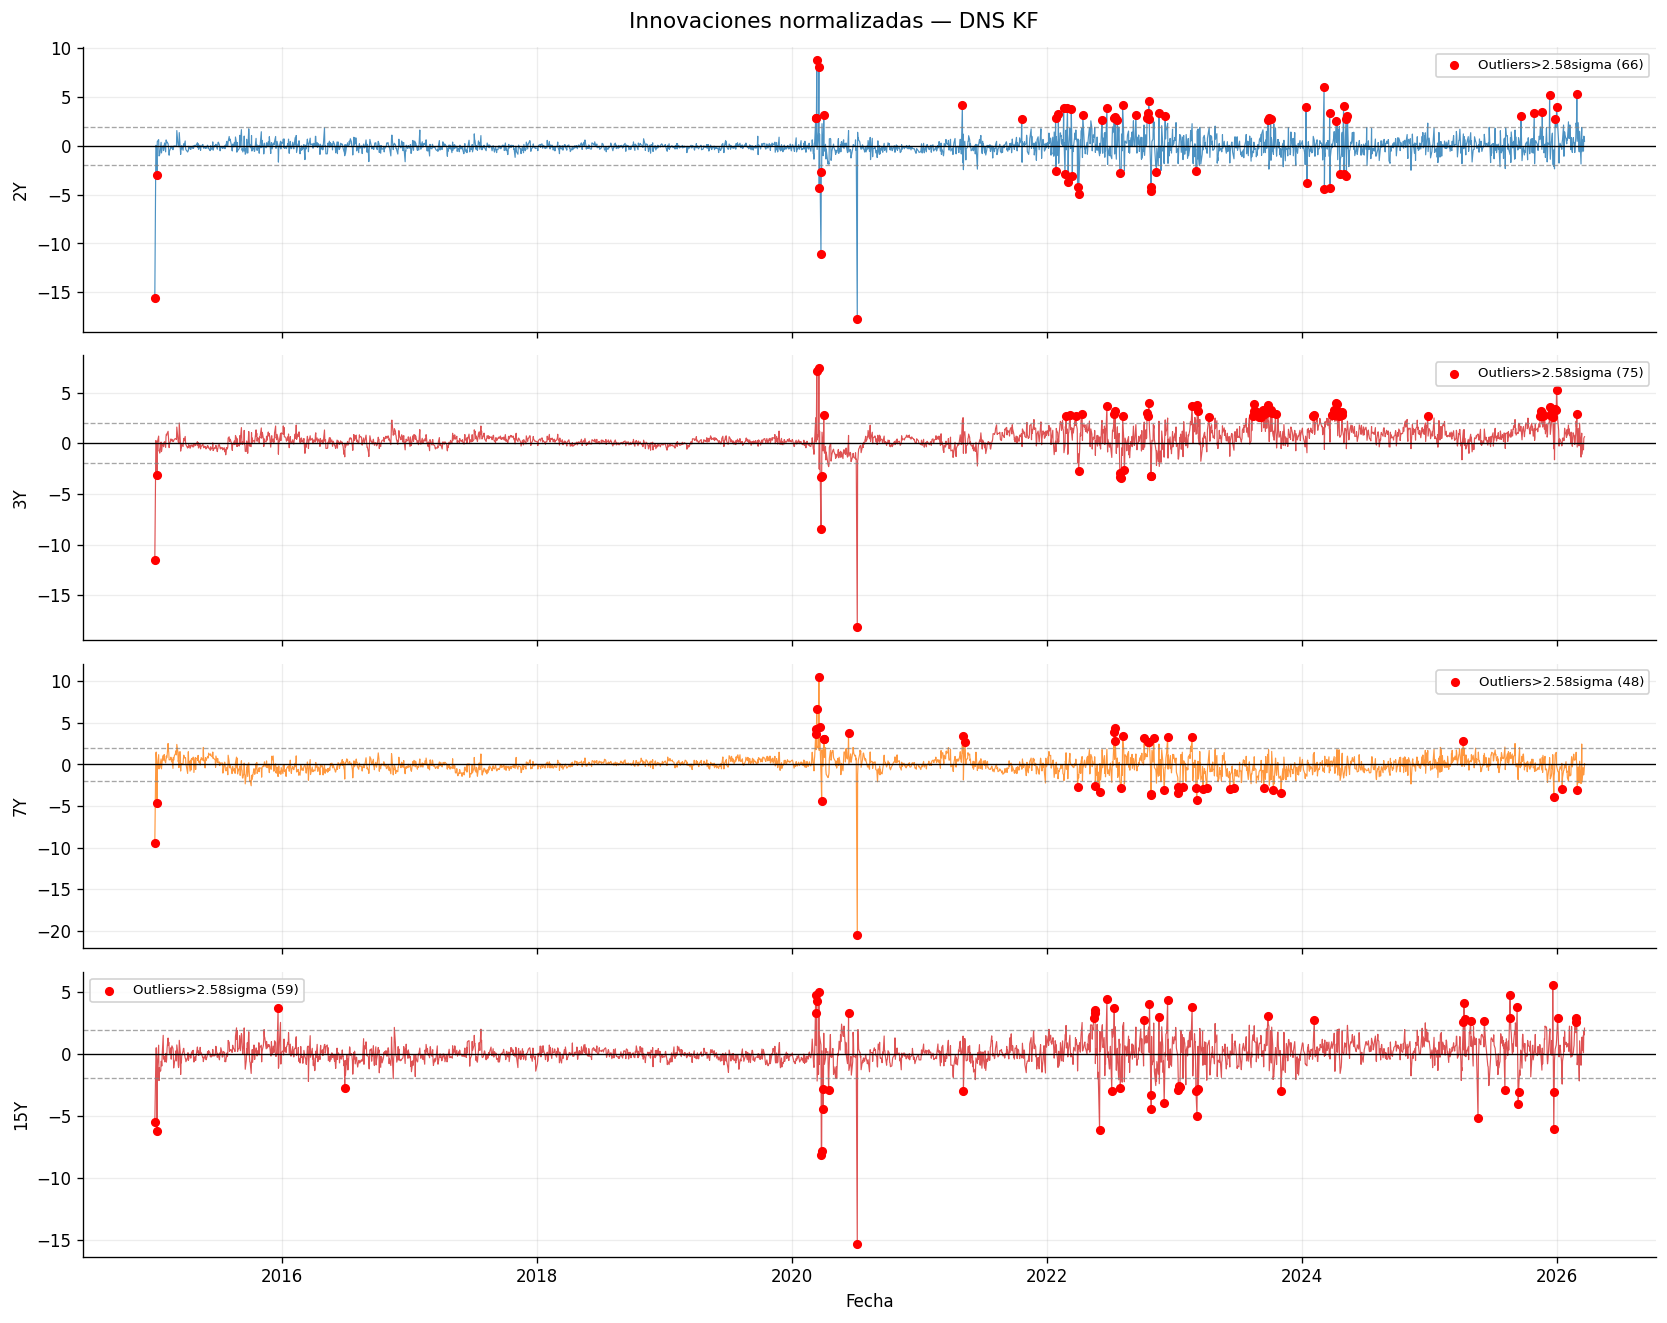

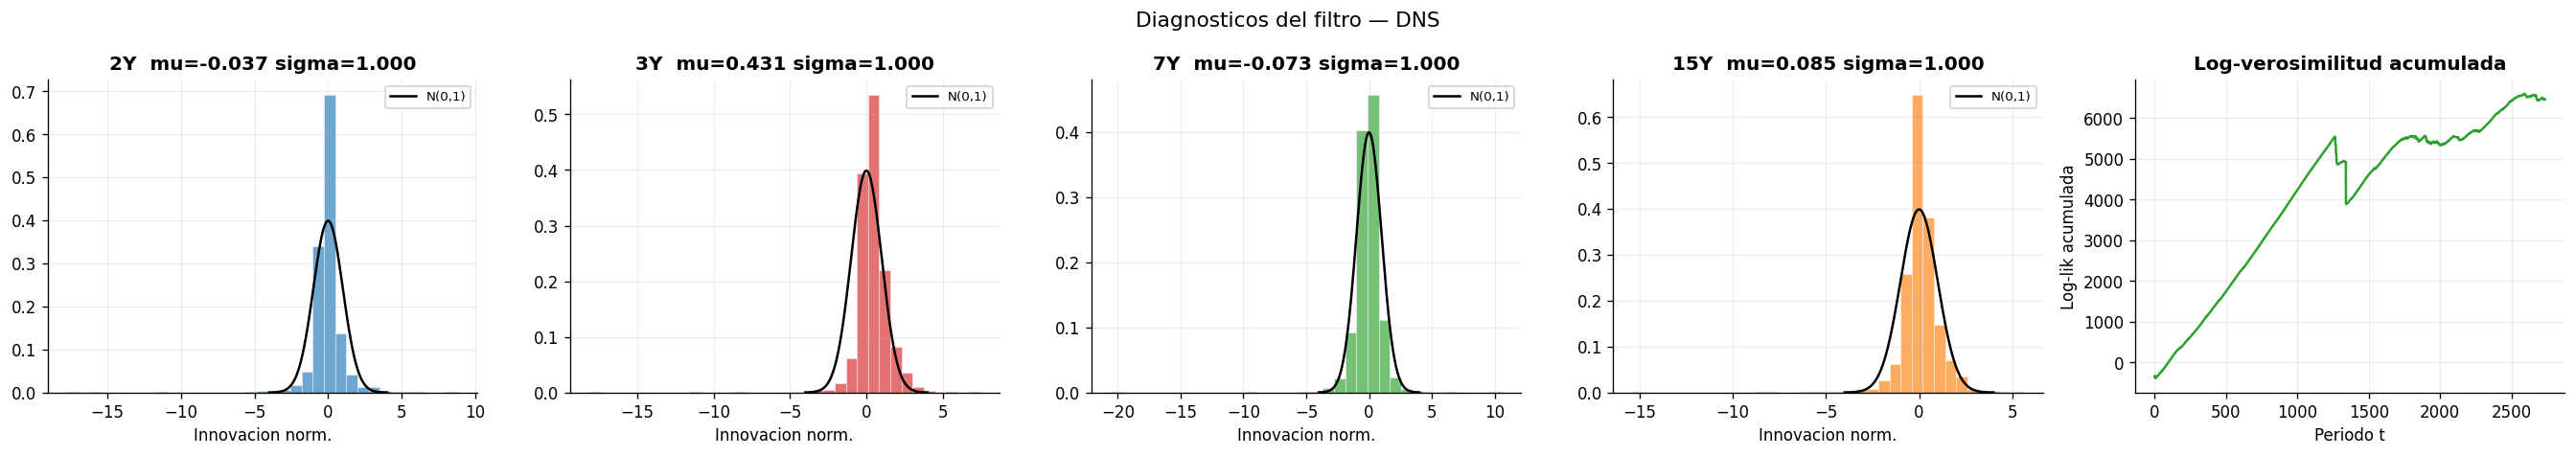


── Test de blancura Ljung-Box (lag 10) — innovaciones DNS ──────────
  Plazo        mu     sigma   LB p-val  Blanco?
  ──────────────────────────────────────────────
     2Y   -0.0367    1.0000     0.0000  No
     3Y   +0.4310    1.0000     0.0000  No
     5Y   -0.0406    1.0000     0.0000  No
     7Y   -0.0727    1.0000     0.0000  No
    10Y   -0.1166    1.0000     0.0000  No
    15Y   +0.0853    1.0000     0.0000  No


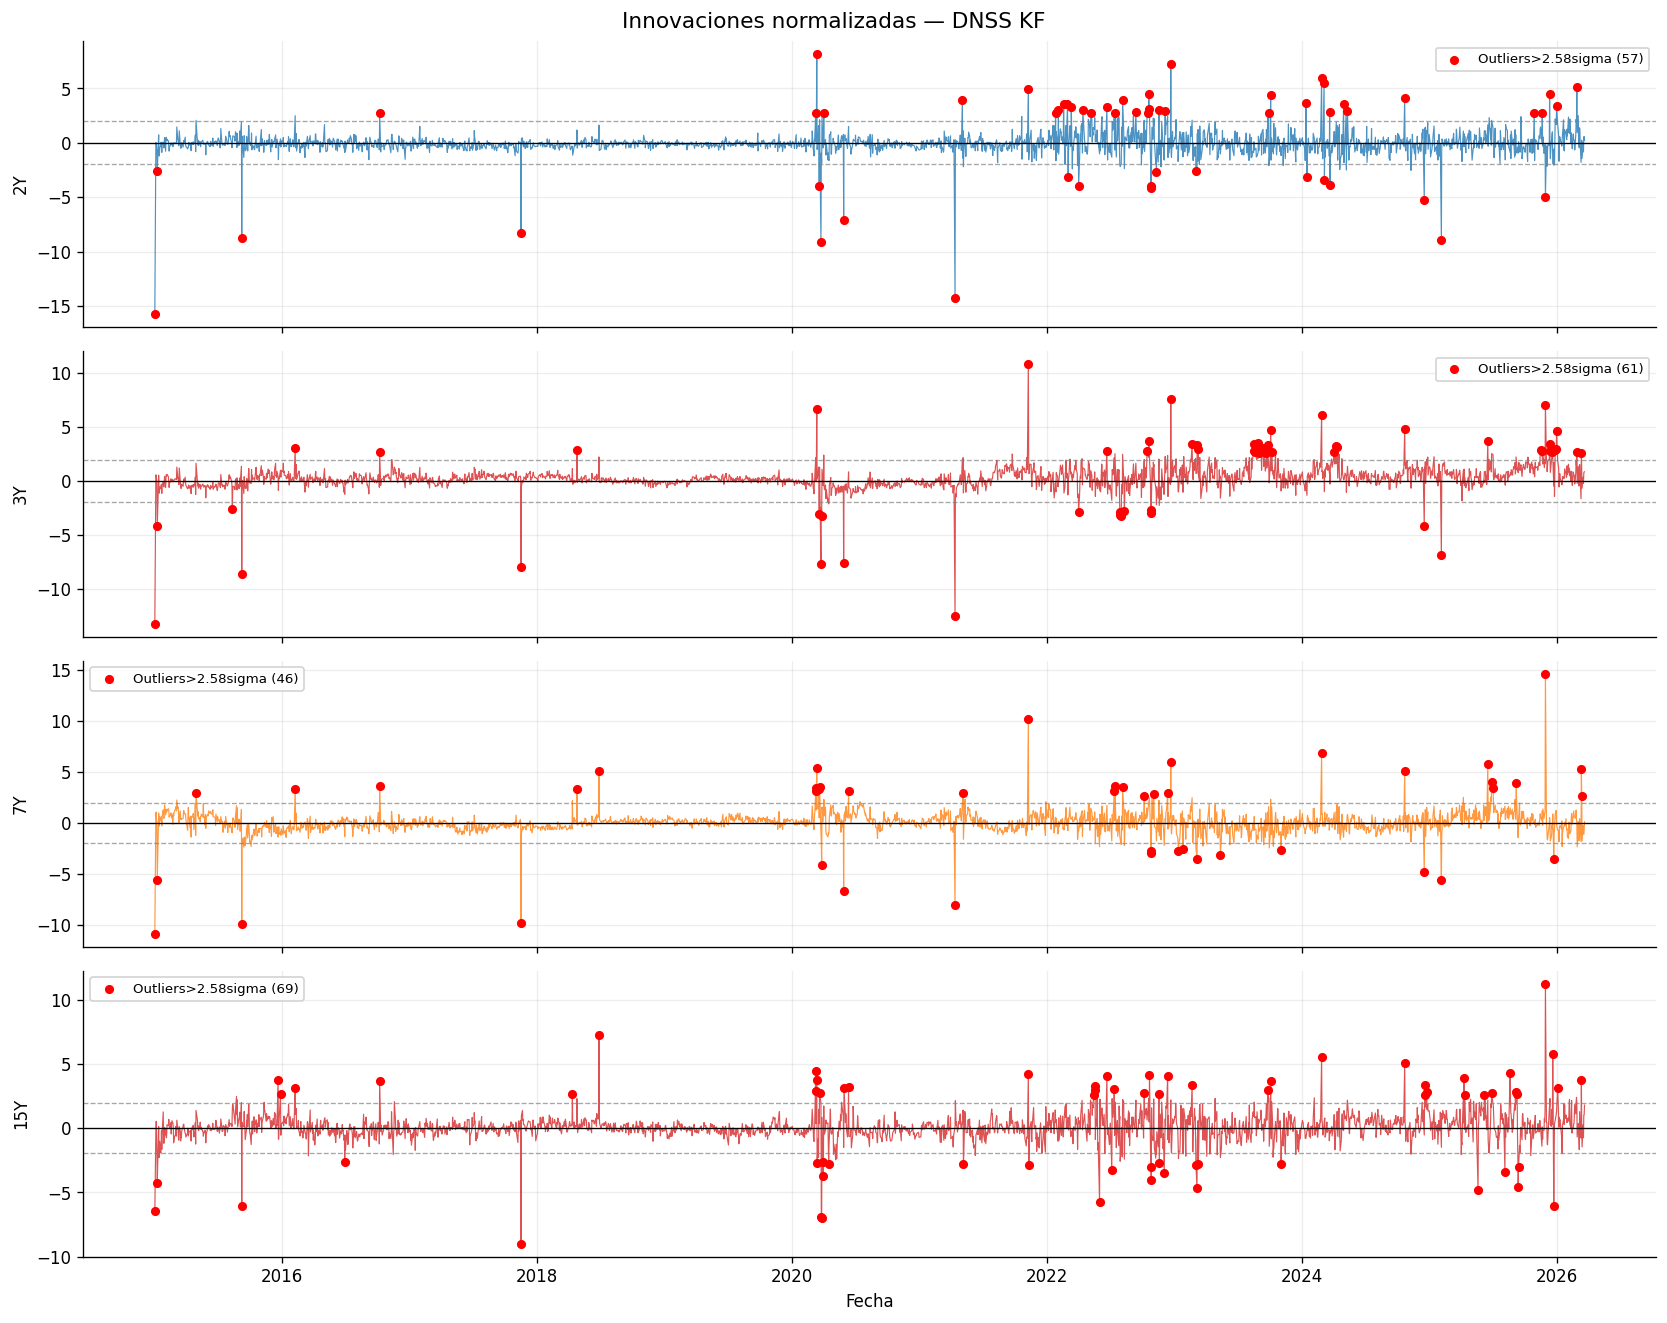

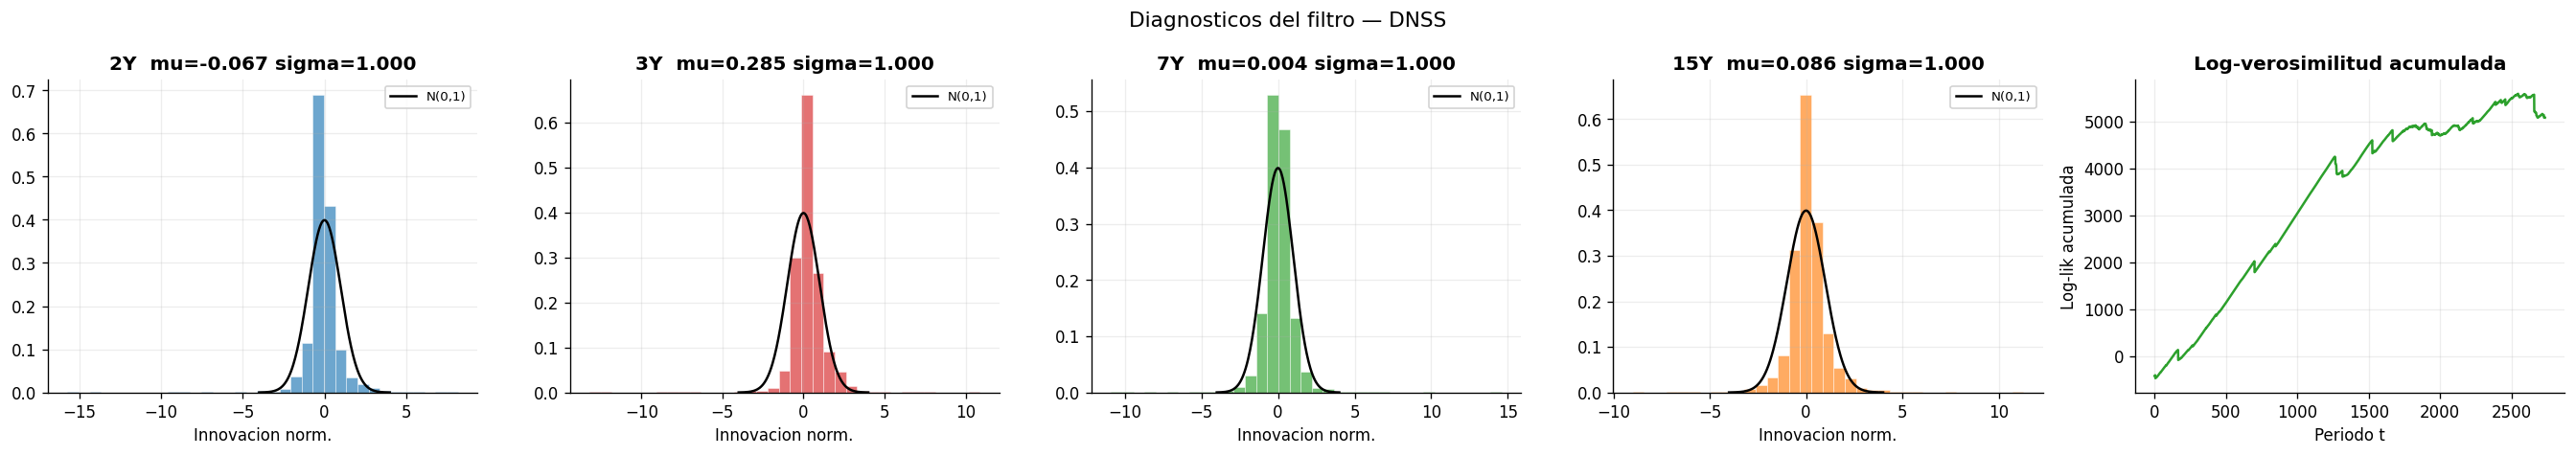


── Test de blancura Ljung-Box (lag 10) — innovaciones DNSS ──────────
  Plazo        mu     sigma   LB p-val  Blanco?
  ──────────────────────────────────────────────
     2Y   -0.0668    1.0000     0.0000  No
     3Y   +0.2847    1.0000     0.0000  No
     5Y   +0.0021    1.0000     0.0000  No
     7Y   +0.0035    1.0000     0.0000  No
    10Y   -0.1029    1.0000     0.0000  No
    15Y   +0.0861    1.0000     0.0000  No


In [49]:
def diagnosticos_filtro(res):
    model   = res['model']
    dates   = res['dates']
    innov   = res['innovations']
    T, N    = innov.shape
    mats    = res['maturities']

    innov_std = innov.std(axis=0)
    innov_n   = innov / innov_std[np.newaxis, :]

    n_show = min(4, N)
    idx_m  = np.linspace(0, N-1, n_show, dtype=int)

    # ── (1) Innovaciones normalizadas en el tiempo ────────────────────────────
    fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.8*n_show), sharex=True)
    if n_show == 1: axes = [axes]

    for ax, i in zip(axes, idx_m):
        col = COLORES_FACTOR[i%4]
        ax.plot(dates, innov_n[:, i], color=col, lw=0.7, alpha=0.8)
        ax.axhline(0,     color='k',    lw=0.8)
        ax.axhline( 1.96, color='gray', lw=0.8, ls='--', alpha=0.7)
        ax.axhline(-1.96, color='gray', lw=0.8, ls='--', alpha=0.7)
        out = np.abs(innov_n[:, i]) > 2.58
        ax.scatter(np.array(dates)[out], innov_n[out, i],
                   color='red', s=20, zorder=5, label=f'Outliers>2.58sigma ({out.sum()})')
        ax.set_ylabel(f'{mats[i]:.0f}Y'); ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    axes[-1].set_xlabel('Fecha')
    fig.suptitle(f'Innovaciones normalizadas — {model} KF', fontsize=13)
    plt.tight_layout(); plt.show()

    # ── (2) Distribucion + log-lik acumulada ─────────────────────────────────
    fig, axes = plt.subplots(1, n_show+1, figsize=(4.5*(n_show+1), 4))

    for ci, i in enumerate(idx_m):
        ax = axes[ci]
        r  = innov_n[:, i]
        ax.hist(r, bins=35, density=True, color=COLORES_FACTOR[ci%4],
                alpha=0.65, edgecolor='white', lw=0.4)
        x_r = np.linspace(-4, 4, 200)
        ax.plot(x_r, stats.norm.pdf(x_r), 'k-', lw=1.5, label='N(0,1)')
        ax.set_title(f'{mats[i]:.0f}Y  mu={r.mean():.3f} sigma={r.std():.3f}')
        ax.set_xlabel('Innovacion norm.'); ax.legend(fontsize=8)

    # Log-lik acumulada
    ll_t = np.zeros(T)
    for t in range(T):
        for n in range(N):
            ll_t[t] -= 0.5*(np.log(2*np.pi*innov_std[n]**2) + innov_n[t,n]**2)
    ax = axes[-1]
    ax.plot(np.arange(T), np.cumsum(ll_t), color='#2ca02c', lw=1.5)
    ax.set_xlabel('Periodo t'); ax.set_ylabel('Log-lik acumulada')
    ax.set_title('Log-verosimilitud acumulada')

    plt.suptitle(f'Diagnosticos del filtro — {model}', fontsize=13)
    plt.tight_layout(); plt.show()

    # ── (3) Test de blancura ──────────────────────────────────────────────────
    print(f"\n── Test de blancura Ljung-Box (lag 10) — innovaciones {model} ──────────")
    print(f"  {'Plazo':>5}  {'mu':>8}  {'sigma':>8}  {'LB p-val':>9}  Blanco?")
    print("  " + "─"*46)

    for i, m in enumerate(mats):
        r = innov_n[:, i]
        try:
            r_c = r - r.mean()
            lb_s = T*(T+2)*sum(
                np.corrcoef(r_c[:-lag],r_c[lag:])[0,1]**2/(T-lag)
                for lag in range(1, 11))
            lb_p = 1.0 - stats.chi2.cdf(lb_s, df=10)
        except Exception:
            lb_p = np.nan
        blanco = 'Si' if (np.isnan(lb_p) or lb_p > 0.05) else 'No'
        print(f"  {m:>4.0f}Y  {r.mean():>+8.4f}  {r.std():>8.4f}  {lb_p:>9.4f}  {blanco}")


diagnosticos_filtro(res_dns)
diagnosticos_filtro(res_dnss)


## CELDA 16: Analisis post-ajuste — Parametros MLE estimados


  Parametros MLE — DNS  F_type='diagonal'

  mu (media de largo plazo):
    mu_beta0 =  +10.5968
    mu_beta1 =   -4.2790
    mu_beta2 =   -1.2573

  F (matriz de transicion):
    [+0.9950  +0.0000  +0.0000]
    [+0.0000  +0.9950  +0.0000]
    [+0.0000  +0.0000  +0.9950]
    |lambda| = [0.995 0.995 0.995]
    max|lambda|=0.9950  → Estable

  Semividas (diag F):
    beta0(nivel): f_ii=0.9950  semivida~138.3 periodos
    beta1(pend.): f_ii=0.9950  semivida~138.3 periodos
    beta2(curv.): f_ii=0.9950  semivida~138.3 periodos

  sigma_eta (sqrt diag Q) — innovaciones de estado:
    sigma_eta(beta0) = 0.10472
    sigma_eta(beta1) = 0.13612
    sigma_eta(beta2) = 0.31425

  sigma_eps (sqrt R) — error de medicion por plazo:
    2Y: sigma_eps = 4.334 pb
    3Y: sigma_eps = 12.075 pb
    5Y: sigma_eps = 4.598 pb
    7Y: sigma_eps = 10.454 pb
    10Y: sigma_eps = 18.638 pb
    15Y: sigma_eps = 10.782 pb


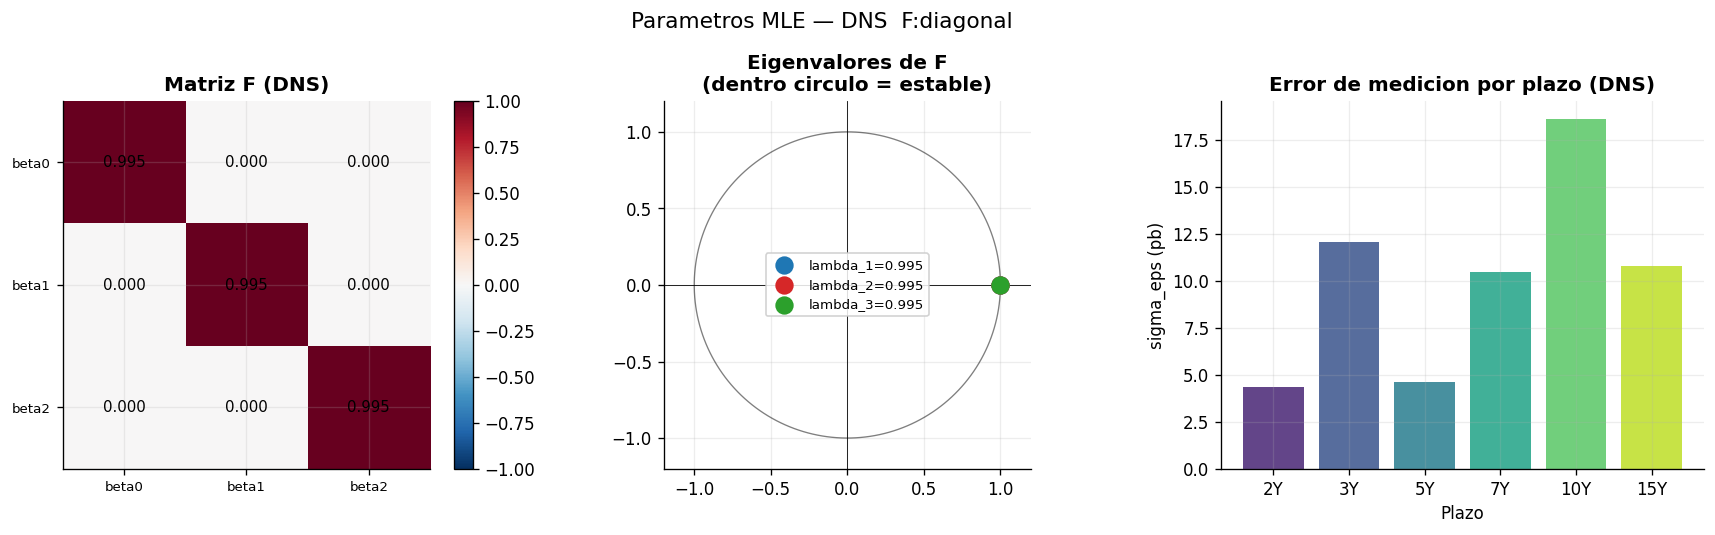


  Parametros MLE — DNSS  F_type='diagonal'

  mu (media de largo plazo):
    mu_beta0 =  +10.8856
    mu_beta1 =   -7.0216
    mu_beta2 =   -1.0014
    mu_beta3 =   +7.1309

  F (matriz de transicion):
    [+0.9950  +0.0000  +0.0000  +0.0000]
    [+0.0000  +0.9950  +0.0000  +0.0000]
    [+0.0000  +0.0000  +0.9950  +0.0000]
    [+0.0000  +0.0000  +0.0000  +0.9950]
    |lambda| = [0.995 0.995 0.995 0.995]
    max|lambda|=0.9950  → Estable

  Semividas (diag F):
    beta0(nivel): f_ii=0.9950  semivida~138.3 periodos
    beta1(pend.): f_ii=0.9950  semivida~138.3 periodos
    beta2(curv.): f_ii=0.9950  semivida~138.3 periodos
    beta3(curv2): f_ii=0.9950  semivida~138.3 periodos

  sigma_eta (sqrt diag Q) — innovaciones de estado:
    sigma_eta(beta0) = 0.12095
    sigma_eta(beta1) = 0.15499
    sigma_eta(beta2) = 0.51331
    sigma_eta(beta3) = 0.47703

  sigma_eps (sqrt R) — error de medicion por plazo:
    2Y: sigma_eps = 2.693 pb
    3Y: sigma_eps = 10.327 pb
    5Y: sigma_eps = 4.240 

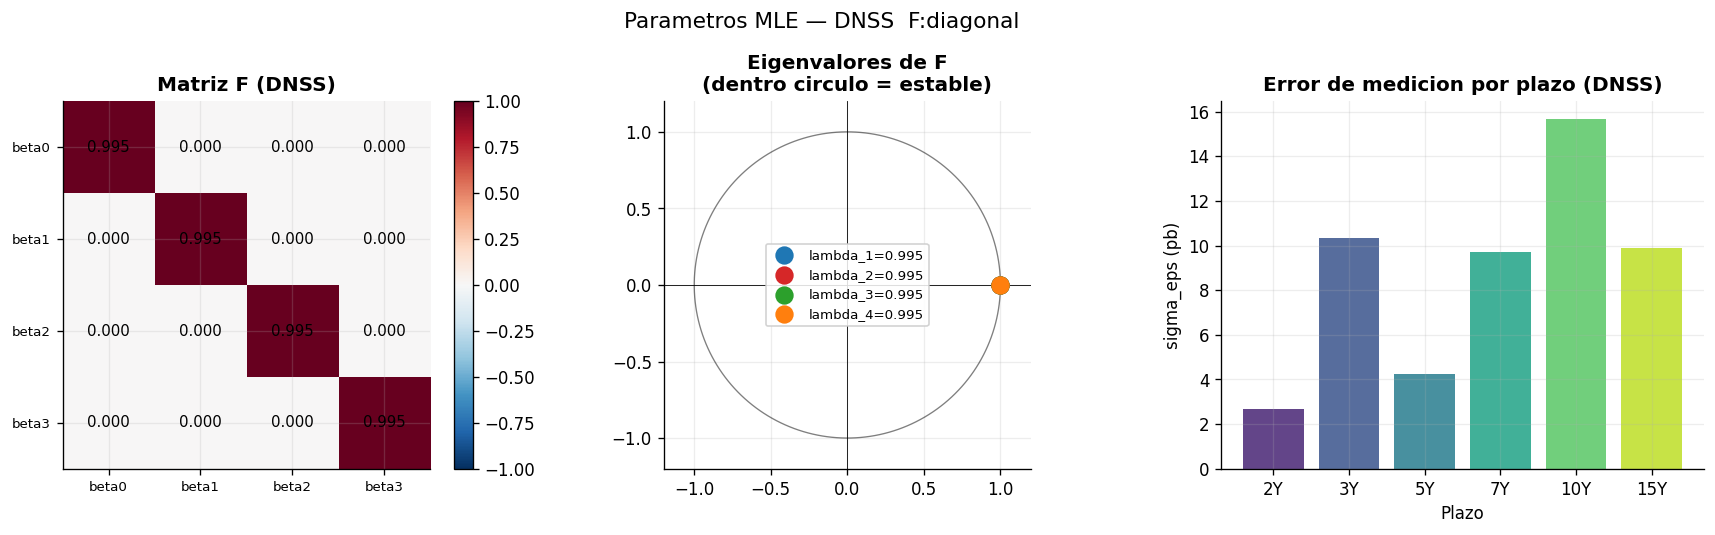

In [17]:
def resumen_parametros(res):
    model  = res['model']
    F      = res['F']
    Q      = res['Q']
    R_diag = res['R_diag']
    mu     = res['mu']
    mats   = res['maturities']
    k      = len(mu)

    noms_b = (['beta0(nivel)','beta1(pend.)','beta2(curv.)']
              + (['beta3(curv2)'] if k==4 else []))

    print(f"\n{'='*58}")
    print(f"  Parametros MLE — {model}  F_type='{res['F_type']}'")
    print(f"{'='*58}")

    print(f"\n  mu (media de largo plazo):")
    for i, nom in enumerate(noms_b):
        print(f"    mu_{nom[:5]} = {mu[i]:+9.4f}")

    print(f"\n  F (matriz de transicion):")
    eigvals = np.linalg.eigvals(F)
    for i in range(k):
        row = '  '.join(f'{F[i,j]:+7.4f}' for j in range(k))
        print(f"    [{row}]")
    print(f"    |lambda| = {np.round(np.abs(eigvals),4)}")
    estable = np.all(np.abs(eigvals) < 1)
    print(f"    max|lambda|={np.abs(eigvals).max():.4f}  → {'Estable' if estable else 'INESTABLE'}")

    hl = -np.log(2) / np.log(np.maximum(np.abs(np.diag(F)), 1e-6))
    print(f"\n  Semividas (diag F):")
    for i, (nom, h) in enumerate(zip(noms_b, hl)):
        print(f"    {nom}: f_ii={F[i,i]:.4f}  semivida~{h:.1f} periodos")

    print(f"\n  sigma_eta (sqrt diag Q) — innovaciones de estado:")
    for i, (nom, s) in enumerate(zip(noms_b, np.sqrt(np.diag(Q)))):
        print(f"    sigma_eta({nom[:5]}) = {s:.5f}")

    print(f"\n  sigma_eps (sqrt R) — error de medicion por plazo:")
    for m, s in zip(mats, np.sqrt(R_diag)*100):
        print(f"    {m:.0f}Y: sigma_eps = {s:.3f} pb")

    # Visualizacion
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # F heatmap
    im0 = axes[0].imshow(F, cmap='RdBu_r', vmin=-1, vmax=1)
    for i in range(k):
        for j in range(k):
            axes[0].text(j, i, f'{F[i,j]:.3f}', ha='center', va='center', fontsize=9)
    axes[0].set_title(f'Matriz F ({model})')
    axes[0].set_xticks(range(k)); axes[0].set_yticks(range(k))
    axes[0].set_xticklabels([n[:5] for n in noms_b], fontsize=8)
    axes[0].set_yticklabels([n[:5] for n in noms_b], fontsize=8)
    plt.colorbar(im0, ax=axes[0], fraction=0.04)

    # Eigenvalores en circulo unitario
    theta = np.linspace(0, 2*np.pi, 200)
    axes[1].plot(np.cos(theta), np.sin(theta), 'k-', lw=0.8, alpha=0.5)
    axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)
    for i, ev in enumerate(eigvals):
        axes[1].scatter(ev.real, ev.imag, s=100, zorder=5,
                        color=COLORES_FACTOR[i%4], label=f'lambda_{i+1}={abs(ev):.3f}')
    axes[1].set_xlim(-1.2, 1.2); axes[1].set_ylim(-1.2, 1.2)
    axes[1].set_aspect('equal'); axes[1].legend(fontsize=8)
    axes[1].set_title('Eigenvalores de F\n(dentro circulo = estable)')

    # sigma_eps por plazo
    axes[2].bar(range(len(mats)), np.sqrt(R_diag)*100,
                color=plt.cm.viridis(np.linspace(0.1,0.9,len(mats))), alpha=0.85)
    axes[2].set_xticks(range(len(mats)))
    axes[2].set_xticklabels([f'{m:.0f}Y' for m in mats])
    axes[2].set_ylabel('sigma_eps (pb)'); axes[2].set_xlabel('Plazo')
    axes[2].set_title(f'Error de medicion por plazo ({model})')

    plt.suptitle(f'Parametros MLE — {model}  F:{res["F_type"]}', fontsize=13)
    plt.tight_layout(); plt.show()


resumen_parametros(res_dns)
resumen_parametros(res_dnss)


## CELDA 17: Analisis del perfil SSE de $\tau$ en el tiempo (DNS)

Visualizacion del perfil de SSE para cada $\tau$ candidato a lo largo del tiempo.
Muestra cuan plano o punteado es el paisaje de optimizacion y la robustez de la seleccion.


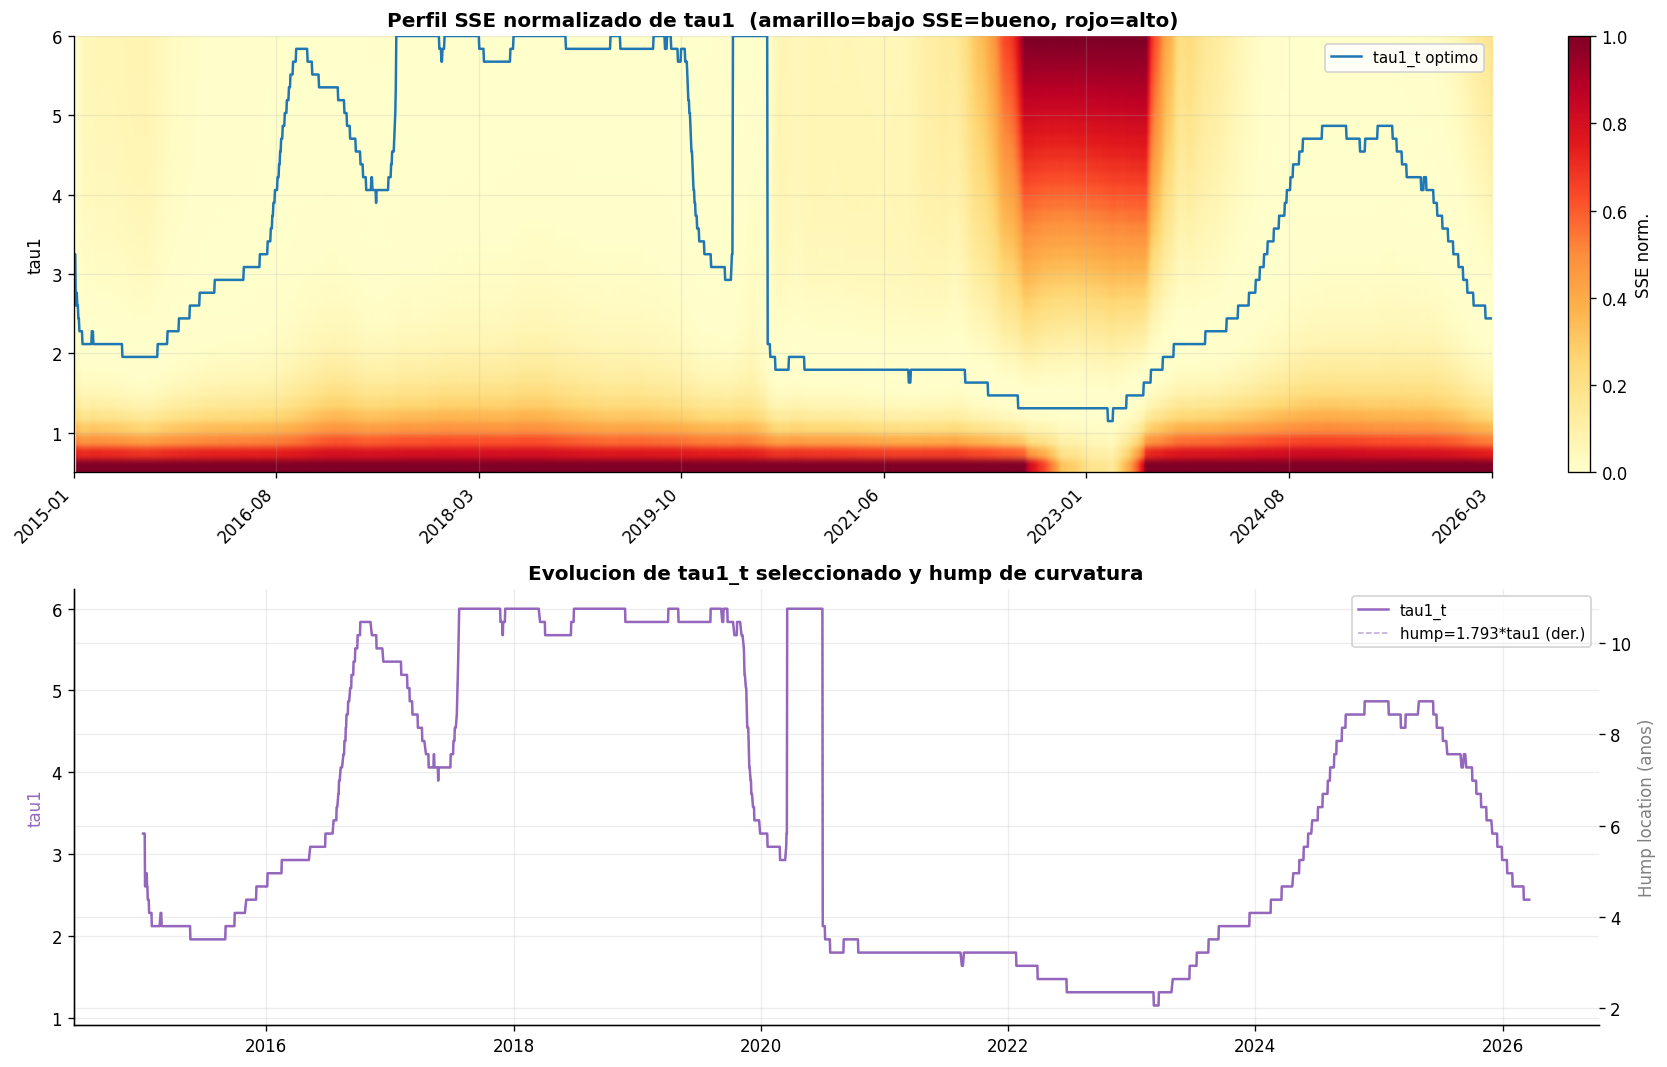

No hay sse_grid en res. Recomputando perfil SSE (puede tardar).


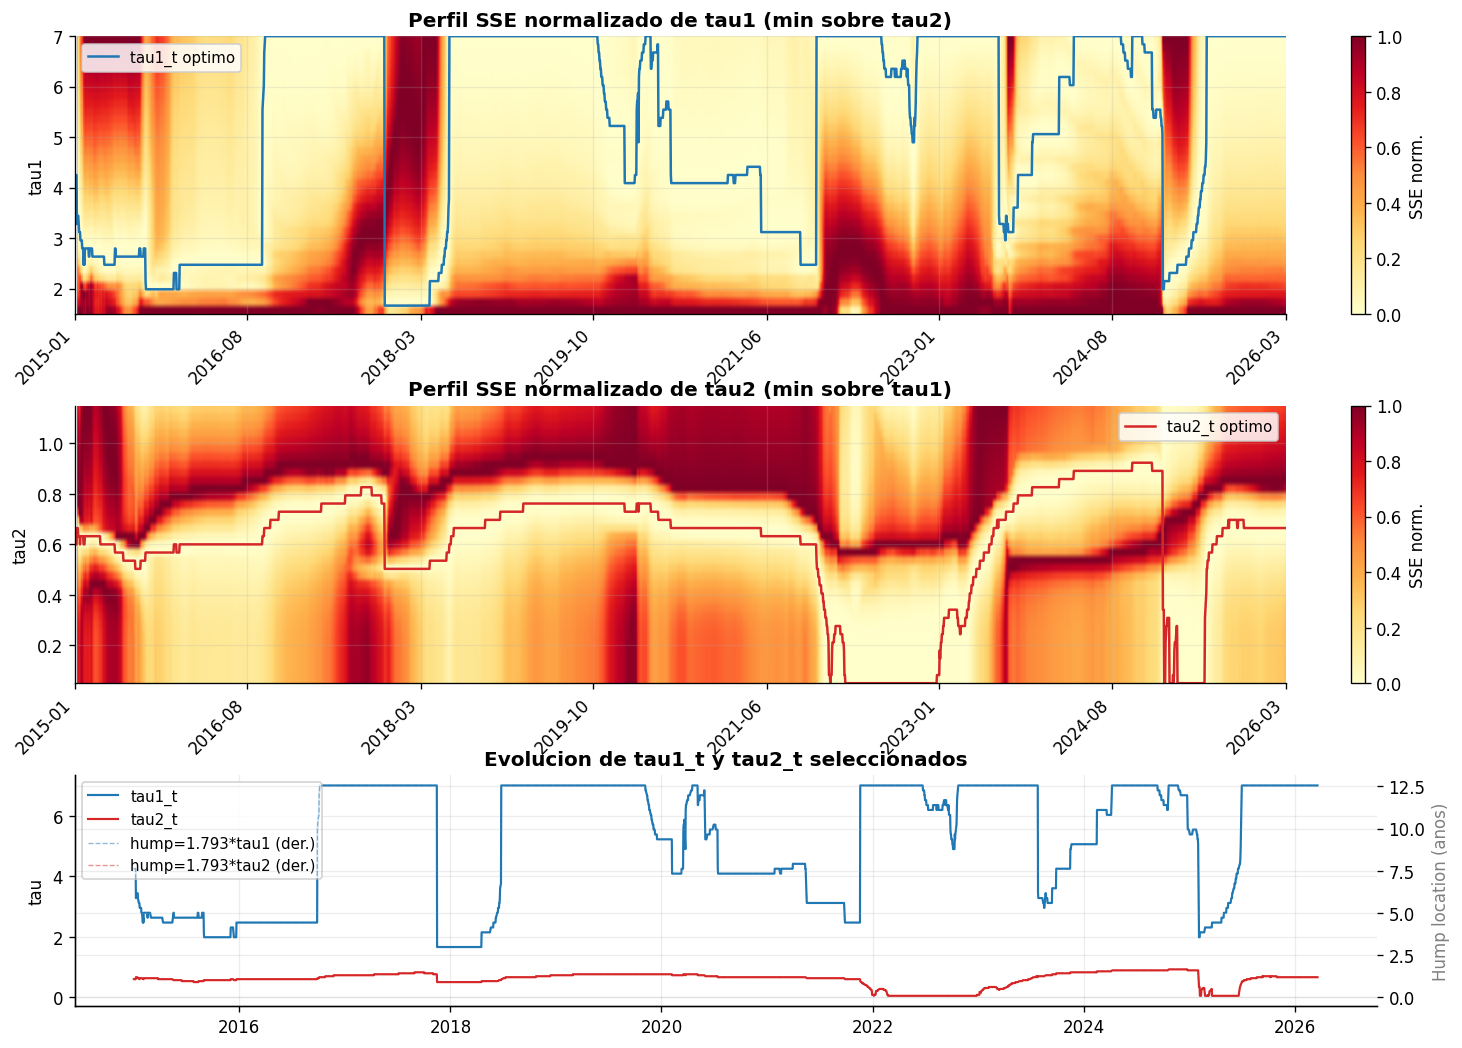

In [27]:
def plot_perfil_sse_tau(res):
    '''Heatmap del perfil SSE(tau, t) para DNS.'''
    if res['model'] != 'DNS':
        print("(Esta grafica aplica solo a DNS)")
        return
    sse_grid = res['sse_grid']       # (T, G1) — puede tener NaN en las primeras filas
    tau1_g   = res['tau1_grid']
    dates    = res['dates']
    tau1_t   = res['tau1_t']
    T        = len(dates)

    # Normalizar SSE fila a fila (percentil) para comparabilidad
    sse_norm = np.zeros_like(sse_grid)
    for t in range(T):
        row = sse_grid[t]
        if np.all(np.isnan(row)): continue
        mn, mx = np.nanmin(row), np.nanmax(row)
        if mx > mn:
            sse_norm[t] = (row - mn) / (mx - mn)
        else:
            sse_norm[t] = 0.0

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # Heatmap (SSE normalizada: 0=mejor, 1=peor)
    im = axes[0].imshow(sse_norm.T, aspect='auto',
                        cmap='YlOrRd', origin='lower',
                        extent=[0, T-1, tau1_g[0], tau1_g[-1]])
    axes[0].plot(range(T), tau1_t, color='#1f77b4', lw=1.5, label='tau1_t optimo')
    n_t = min(8, T//50+1)
    t_ticks = np.linspace(0, T-1, n_t, dtype=int)
    axes[0].set_xticks(t_ticks)
    axes[0].set_xticklabels([str(dates[i])[:7] for i in t_ticks], rotation=45, ha='right')
    axes[0].set_ylabel('tau1'); axes[0].legend(fontsize=9)
    axes[0].set_title('Perfil SSE normalizado de tau1  (amarillo=bajo SSE=bueno, rojo=alto)')
    plt.colorbar(im, ax=axes[0], fraction=0.02, label='SSE norm.')

    # Serie tau1_t
    hump_t = 1.793 * tau1_t
    axes[1].plot(dates, tau1_t, color='#9467bd', lw=1.5, label='tau1_t')
    ax1b = axes[1].twinx()
    ax1b.plot(dates, hump_t, color='#9467bd', lw=0.9, ls='--', alpha=0.6,
              label='hump=1.793*tau1 (der.)')
    axes[1].set_ylabel('tau1', color='#9467bd')
    ax1b.set_ylabel('Hump location (anos)', color='gray')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[1].set_title('Evolucion de tau1_t seleccionado y hump de curvatura')
    h1, l1 = axes[1].get_legend_handles_labels()
    h2, l2 = ax1b.get_legend_handles_labels()
    axes[1].legend(h1+h2, l1+l2, fontsize=9)

    plt.tight_layout(); plt.show()

def plot_perfil_sse_tau_dnss(res, compute_if_missing=True):
    '''Heatmap del perfil SSE(tau1, tau2, t) para DNSS.'''
    if res['model'] != 'DNSS':
        print("(Esta grafica aplica solo a DNSS)")
        return
    sse_grid = res.get('sse_grid', None)
    tau1_g   = res['tau1_grid']
    tau2_g   = res['tau2_grid']
    dates    = res['dates']
    tau1_t   = res['tau1_t']
    tau2_t   = res['tau2_t']
    T        = len(dates)

    if sse_grid is None:
        if not compute_if_missing:
            print("No hay sse_grid en res. Reestima el modelo o activa compute_if_missing.")
            return
        print("No hay sse_grid en res. Recomputando perfil SSE (puede tardar).")
        yields      = res['yields']
        maturities  = res['maturities']
        window_size = res.get('window_size', None)

        G1, G2 = len(tau1_g), len(tau2_g)
        N      = len(maturities)
        k      = 4
        sep_min = 0.30

        M_arr = np.zeros((G1, G2, N, N))
        valid = np.zeros((G1, G2), dtype=bool)
        for i, tau1 in enumerate(tau1_g):
            for j, tau2 in enumerate(tau2_g):
                if tau1 <= tau2 + sep_min:
                    continue
                H  = nss_loadings(maturities, tau1, tau2)
                Mv = _residual_maker(H)
                if Mv is not None:
                    M_arr[i, j] = Mv
                    valid[i, j] = True

        YYt_cum = _build_YYt_cumsum(yields)
        sse_grid = np.full((T, G1, G2), np.nan)
        for t in range(T):
            if window_size is None:
                Sigma = YYt_cum[t+1]; n_win = t+1
            else:
                t0 = max(0, t - window_size + 1)
                Sigma = YYt_cum[t+1] - YYt_cum[t0]; n_win = t - t0 + 1
            if n_win < k + 2:
                continue
            sse_t = np.einsum('ghjk,kj->gh', M_arr, Sigma)
            sse_t[~valid] = np.nan
            sse_grid[t] = sse_t

    sse_min_tau1 = np.full((T, len(tau1_g)), np.nan)
    sse_min_tau2 = np.full((T, len(tau2_g)), np.nan)
    for t in range(T):
        grid_t = sse_grid[t]
        if np.all(np.isnan(grid_t)):
            continue
        sse_min_tau1[t] = np.nanmin(grid_t, axis=1)
        sse_min_tau2[t] = np.nanmin(grid_t, axis=0)

    def _row_norm(mat):
        out = np.full_like(mat, np.nan, dtype=float)
        for t in range(mat.shape[0]):
            row = mat[t]
            if np.all(np.isnan(row)):
                continue
            mn, mx = np.nanmin(row), np.nanmax(row)
            if mx > mn:
                out[t] = (row - mn) / (mx - mn)
            else:
                out[t] = 0.0
        return out

    sse_norm_tau1 = _row_norm(sse_min_tau1)
    sse_norm_tau2 = _row_norm(sse_min_tau2)

    fig = plt.figure(figsize=(14, 10.5))
    gs  = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[1.2, 1.2, 1.0], hspace=0.35)

    ax0 = fig.add_subplot(gs[0])
    im0 = ax0.imshow(sse_norm_tau1.T, aspect='auto',
                     cmap='YlOrRd', origin='lower',
                     extent=[0, T-1, tau1_g[0], tau1_g[-1]])
    ax0.plot(range(T), tau1_t, color='#1f77b4', lw=1.5, label='tau1_t optimo')
    n_t = min(8, T//50+1)
    t_ticks = np.linspace(0, T-1, n_t, dtype=int)
    ax0.set_xticks(t_ticks)
    ax0.set_xticklabels([str(dates[i])[:7] for i in t_ticks], rotation=45, ha='right')
    ax0.set_ylabel('tau1'); ax0.legend(fontsize=9)
    ax0.set_title('Perfil SSE normalizado de tau1 (min sobre tau2)')
    plt.colorbar(im0, ax=ax0, fraction=0.02, label='SSE norm.')

    ax1 = fig.add_subplot(gs[1])
    im1 = ax1.imshow(sse_norm_tau2.T, aspect='auto',
                     cmap='YlOrRd', origin='lower',
                     extent=[0, T-1, tau2_g[0], tau2_g[-1]])
    ax1.plot(range(T), tau2_t, color='#d62728', lw=1.5, label='tau2_t optimo')
    ax1.set_xticks(t_ticks)
    ax1.set_xticklabels([str(dates[i])[:7] for i in t_ticks], rotation=45, ha='right')
    ax1.set_ylabel('tau2'); ax1.legend(fontsize=9)
    ax1.set_title('Perfil SSE normalizado de tau2 (min sobre tau1)')
    plt.colorbar(im1, ax=ax1, fraction=0.02, label='SSE norm.')

    ax2 = fig.add_subplot(gs[2])
    ax2.plot(dates, tau1_t, color='#1f77b4', lw=1.3, label='tau1_t')
    ax2.plot(dates, tau2_t, color='#d62728', lw=1.3, label='tau2_t')
    ax2.set_ylabel('tau')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax2.set_title('Evolucion de tau1_t y tau2_t seleccionados')
    ax2b = ax2.twinx()
    ax2b.plot(dates, 1.793 * tau1_t, color='#1f77b4', lw=0.8, ls='--', alpha=0.5,
              label='hump=1.793*tau1 (der.)')
    ax2b.plot(dates, 1.793 * tau2_t, color='#d62728', lw=0.8, ls='--', alpha=0.5,
              label='hump=1.793*tau2 (der.)')
    ax2b.set_ylabel('Hump location (anos)', color='gray')
    h1, l1 = ax2.get_legend_handles_labels()
    h2, l2 = ax2b.get_legend_handles_labels()
    ax2.legend(h1+h2, l1+l2, fontsize=9)

    plt.tight_layout(); plt.show()


plot_perfil_sse_tau(res_dns)

plot_perfil_sse_tau_dnss(res_dnss)

## CELDA 18: Funcion principal `fit_dns_kalman()`

Interfaz de alto nivel. Recibe los datos crudos y orquesta todo el pipeline:
Grid Search adaptativo de $\tau_t$ → MLE de $(F, Q, R, \mu)$ → KF forward → RTS backward → diagnosticos.


In [ ]:
def fit_dns_kalman(
    dates,
    yields,
    maturities,
    model        = 'DNS',
    F_type       = 'diagonal',
    tau1_grid    = None,
    tau2_grid    = None,
    window_size  = None,
    n_starts     = 5,
    sep_min_dnss = 0.15,
    plot         = True,
    verbose      = True,
    obs_weights      = None,          # <<< NUEVO Opción C
    r_mode           = 'libre',       # <<< NUEVO Opción A
    group_thresholds = (3.0, 10.0),   # <<< NUEVO Opción A
):
    '''
    Ajuste DNS o DNSS con Filtro de Kalman y tau adaptativo via Grid Search.

    Parametros
    ----------
    dates        : pd.DatetimeIndex o array de fechas
    yields       : pd.DataFrame (T x N) o np.ndarray (T x N) de rendimientos
    maturities   : array (N,) de plazos en anos
    model        : "DNS"  → Nelson-Siegel (3 factores)
                   "DNSS" → Nelson-Siegel-Svensson (4 factores)
    F_type       : "diagonal"   → F = diag(f1,...,fk)  [consenso empirico]
                   "triangular" → F triangular inferior (VAR estructural)
                   "completa"   → F irrestricta (VAR-1 completo)
    tau1_grid    : array de candidatos para tau1
                   None → automatico: linspace(0.5, 5.0, 35)
    tau2_grid    : array de candidatos para tau2 (solo DNSS)
                   None → automatico: linspace(0.15, 3.0, 20)
    window_size  : int  → ventana rodante de W periodos para el Grid Search
                   None → ventana expandiente (causal; recomendado para pronostico)
    n_starts     : intentos multi-start en la optimizacion MLE
    sep_min_dnss : separacion minima tau1 > tau2 + sep_min_dnss para evitar colinealidad (DNSS)
    plot         : si True, genera todos los graficos de diagnostico
    verbose      : si True, imprime progreso
    obs_weights      : (N,) pesos por plazo para la log-verosimilitud (Opción C)
                       None → todos iguales (comportamiento original)
                       Ejemplo: np.array([1,1,1,1,1,1,2,3]) da peso doble a 20Y
                       y triple a 30Y, forzando mejor ajuste en plazos largos
    r_mode           : 'libre'  → N varianzas de medición independientes (original)
                       'grupos' → solo 3 varianzas: corto/medio/largo (Opción A)
                       Reducción de parámetros: N → 3, más parsimonia en R
    group_thresholds : (th1, th2) fronteras de los grupos en años
                       Defecto (3.0, 10.0) → corto≤3Y, medio≤10Y, largo>10Y

    Retorna
    -------
    dict con las claves:
      model, F_type, window_size
      tau1_t, tau2_t            : secuencias de tau adaptativas (T,)
      beta_filtered             : estados filtrados beta_{t|t}   (T, k)
      beta_smoothed             : estados suavizados beta_{t|T}  (T, k)
      P_filtered, P_smoothed    : covarianzas (T, k, k)
      fitted                    : rendimientos ajustados (T, N)
      residuals                 : residuos (T, N)
      loglik, aic, bic
      rmse_total, mae_total
      rmse_mat, mae_mat         : por plazo (N,)
      mu, F, Q, R_diag          : parametros MLE
      maturities, dates, yields

    Ejemplo
    -------
    res = fit_dns_kalman(
        dates       = df.index,
        yields      = df[yield_cols].values,
        maturities  = np.array([1, 2, 3, 5, 10, 20]),
        model       = "DNSS",
        F_type      = "diagonal",
        window_size = 52,
        n_starts    = 5,
    )
    print(f"RMSE = {res['rmse_total']*100:.3f} pb")
    print(f"AIC  = {res['aic']:,.1f}")
    '''
    # ── Validaciones ──────────────────────────────────────────────────────────
    if isinstance(yields, pd.DataFrame):
        yields = yields.values
    yields     = np.asarray(yields, dtype=float)
    maturities = np.asarray(maturities, dtype=float)

    if not isinstance(dates, pd.DatetimeIndex):
        dates = pd.DatetimeIndex(dates)

    assert yields.ndim == 2, "yields debe ser (T, N)"
    T, N = yields.shape
    assert len(maturities) == N, \
        f"len(maturities)={len(maturities)} != columnas yields={N}"
    assert model  in ('DNS', 'DNSS'), "model debe ser 'DNS' o 'DNSS'"
    assert F_type in ('diagonal','triangular','completa'), \
        "F_type debe ser 'diagonal', 'triangular' o 'completa'"

    if tau1_grid is None:
        tau1_grid = np.linspace(0.5, 5.0, 35)
    if tau2_grid is None and model == 'DNSS':
        tau2_grid = np.linspace(0.15, 3.0, 20)

    # ── Ajuste ────────────────────────────────────────────────────────────────
    res = fit_model(
        yields      = yields,
        maturities  = maturities,
        dates       = dates,
        model       = model,
        F_type      = F_type,
        tau1_grid   = tau1_grid,
        tau2_grid   = tau2_grid,
        window_size = window_size,
        n_starts    = n_starts,
        verbose     = verbose,
        obs_weights      = obs_weights,
        r_mode           = r_mode,
        group_thresholds = group_thresholds,
    )

    # ── Graficos automaticos ──────────────────────────────────────────────────
    if plot:
        plot_factores(res)
        plot_tau_evolution(res)
        plot_curvas_ajustadas(res)
        plot_heatmap_residuos(res)
        if res['model'] == 'DNS' and res['sse_grid'] is not None:
            plot_perfil_sse_tau(res)
        analisis_residuos(res)
        diagnosticos_filtro(res)
        resumen_parametros(res)

    return res


print("fit_dns_kalman() definido — listo para usar")
print()
print("Uso minimo:")
print("  res = fit_dns_kalman(")
print("      dates      = df.index,")
print("      yields     = df[yield_cols].values,")
print("      maturities = np.array([1, 2, 3, 5, 10, 20]),")
print("      model      = 'DNS',   # o 'DNSS'")
print("      F_type     = 'diagonal',")
print("      window_size= 52,")
print("  )")


fit_dns_kalman() definido — listo para usar

Uso minimo:
  res = fit_dns_kalman(
      dates      = df.index,
      yields     = df[yield_cols].values,
      maturities = np.array([1, 2, 3, 5, 10, 20]),
      model      = 'DNS',   # o 'DNSS'
      F_type     = 'diagonal',
      window_size= 52,
  )


## CELDA 19: Experimento — Impacto del tipo de $F$ en el ajuste

Compara los tres tipos de $F$ en el modelo DNS para evaluar si la estructura
de la transicion importa en terminos de ajuste in-sample y criterios de informacion.
La literatura (Caldeira et al. 2010, Cakmaklı 2013) reporta que la F diagonal
domina o empata en la mayoria de especificaciones.


Experimento: impacto del tipo de F en DNS

  F_type = 'diagonal' ...
    RMSE=10.6604pb  log-lik=10,276.0  AIC=-20,521.9  BIC=-20,433.2

  F_type = 'triangular' ...
    RMSE=10.6604pb  log-lik=10,278.9  AIC=-20,521.8  BIC=-20,415.3

  F_type = 'completa' ...
    RMSE=41.7841pb  log-lik=-48,236.6  AIC=96,515.2  BIC=96,639.4

──────────────────────────────────────────────────────────
  F_type        RMSE(pb)      Log-lik        AIC        BIC
  ──────────────────────────────────────────────────────────
  diagonal       10.6604     10,276.0  -20,521.9  -20,433.2
  triangular     10.6604     10,278.9  -20,521.8  -20,415.3
  completa       41.7841    -48,236.6   96,515.2   96,639.4

  Mejor por AIC: F_type='diagonal'
  Mejor por BIC: F_type='diagonal'

  Generando graficos completos para F_type='diagonal' ...


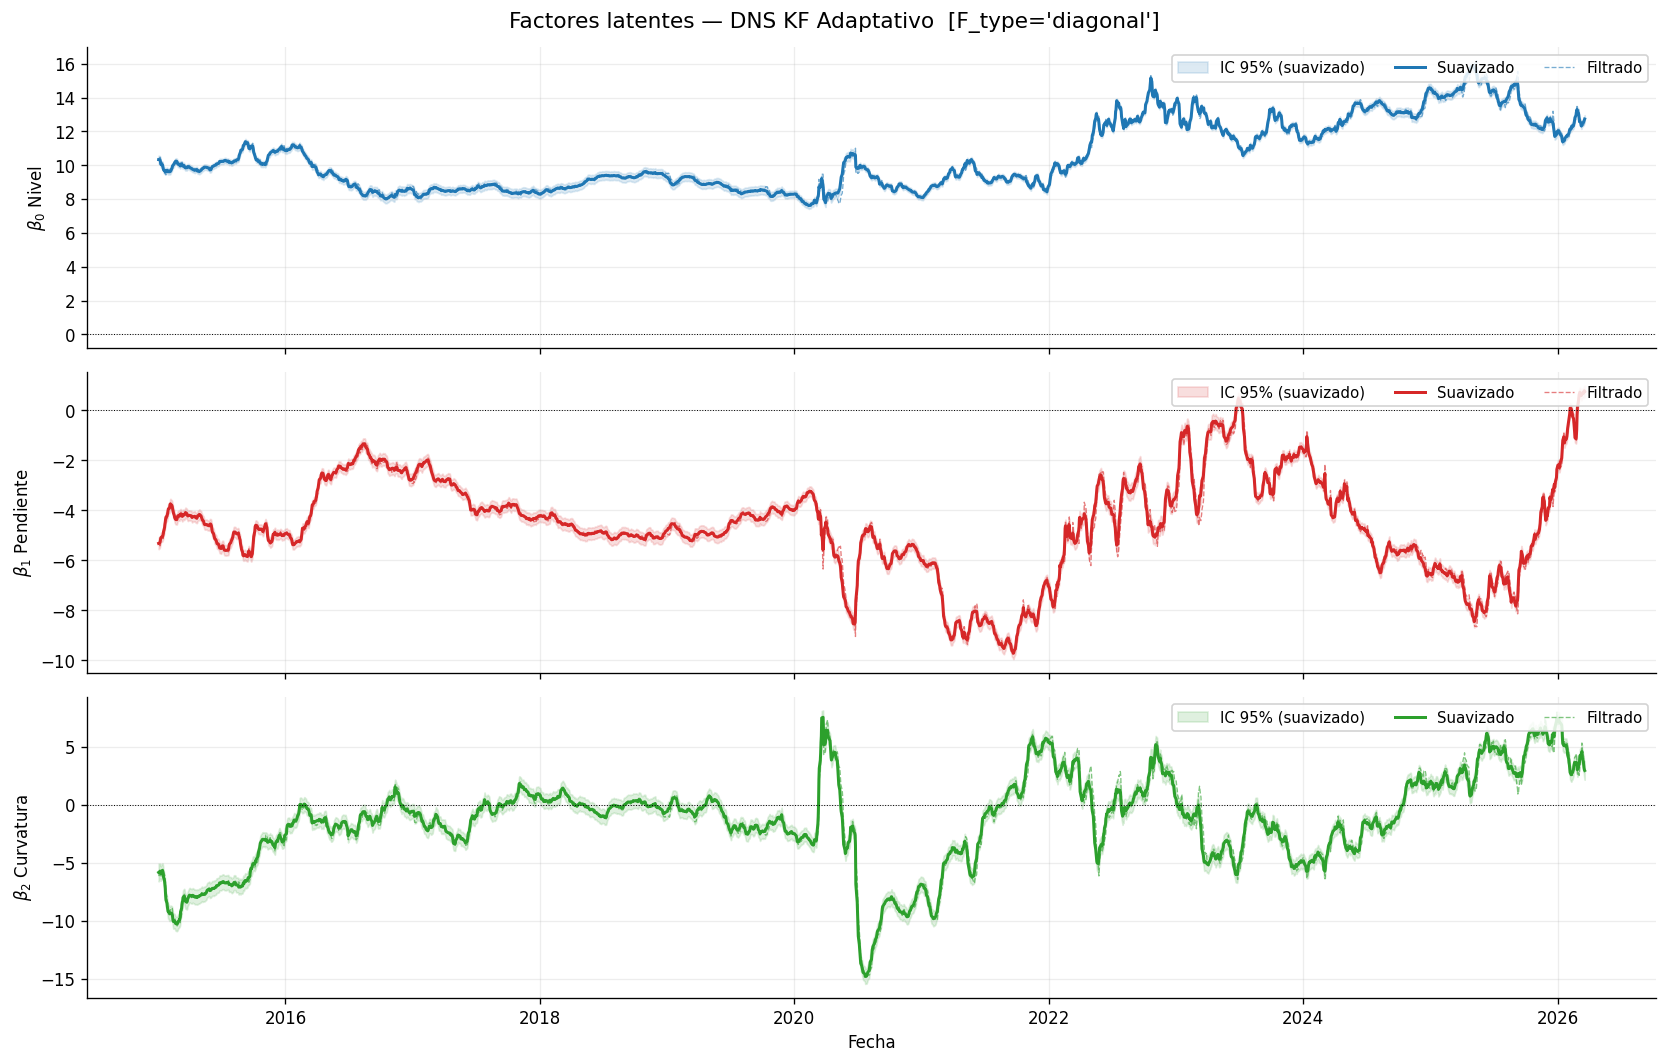


── Estadisticos de factores suavizados (DNS) ───────────────
Factor        Media    Std     Min     Q25     Med     Q75     Max
──────────────────────────────────────────────────────────────────
  $\beta_0$ Ni  +10.477   2.025   +7.607  +8.734  +9.707 +12.300 +15.866
  $\beta_1$ Pe   -4.570   1.998   -9.720  -5.592  -4.587  -3.317  +0.788
  $\beta_2$ Cu   -1.304   3.857  -14.795  -3.142  -0.909  +0.776  +7.563

── Autocorrelaciones lag-1 y lag-5 (suavizado) ─────────────────
  $\beta_0$ Nive  rho(1)=0.9993   rho(5)=0.9914
  $\beta_1$ Pend  rho(1)=0.9989   rho(5)=0.9838
  $\beta_2$ Curv  rho(1)=0.9986   rho(5)=0.9785


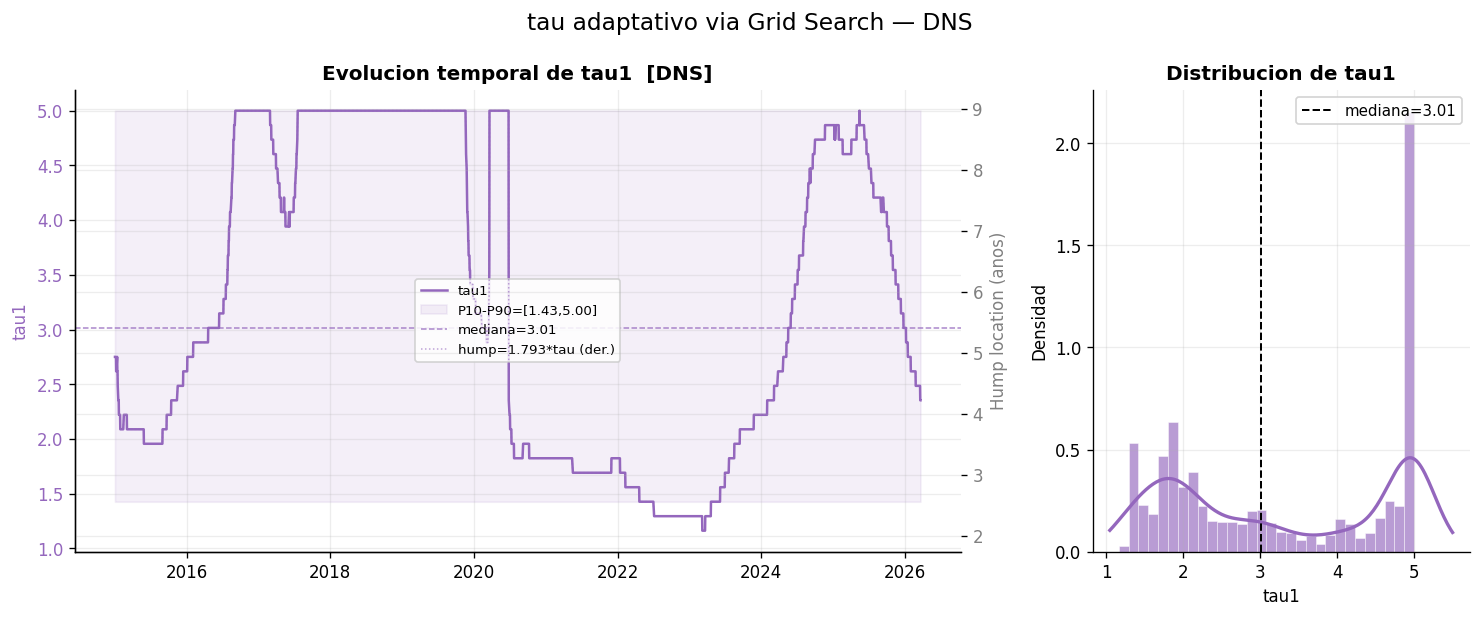


── Estadisticos de tau_t (DNS) ──────────────────────────────
  tau1: min=1.162  med=3.015  max=5.000  std=1.433  rho(1)=0.999
    hump: min=2.08Y  med=5.41Y  max=8.96Y


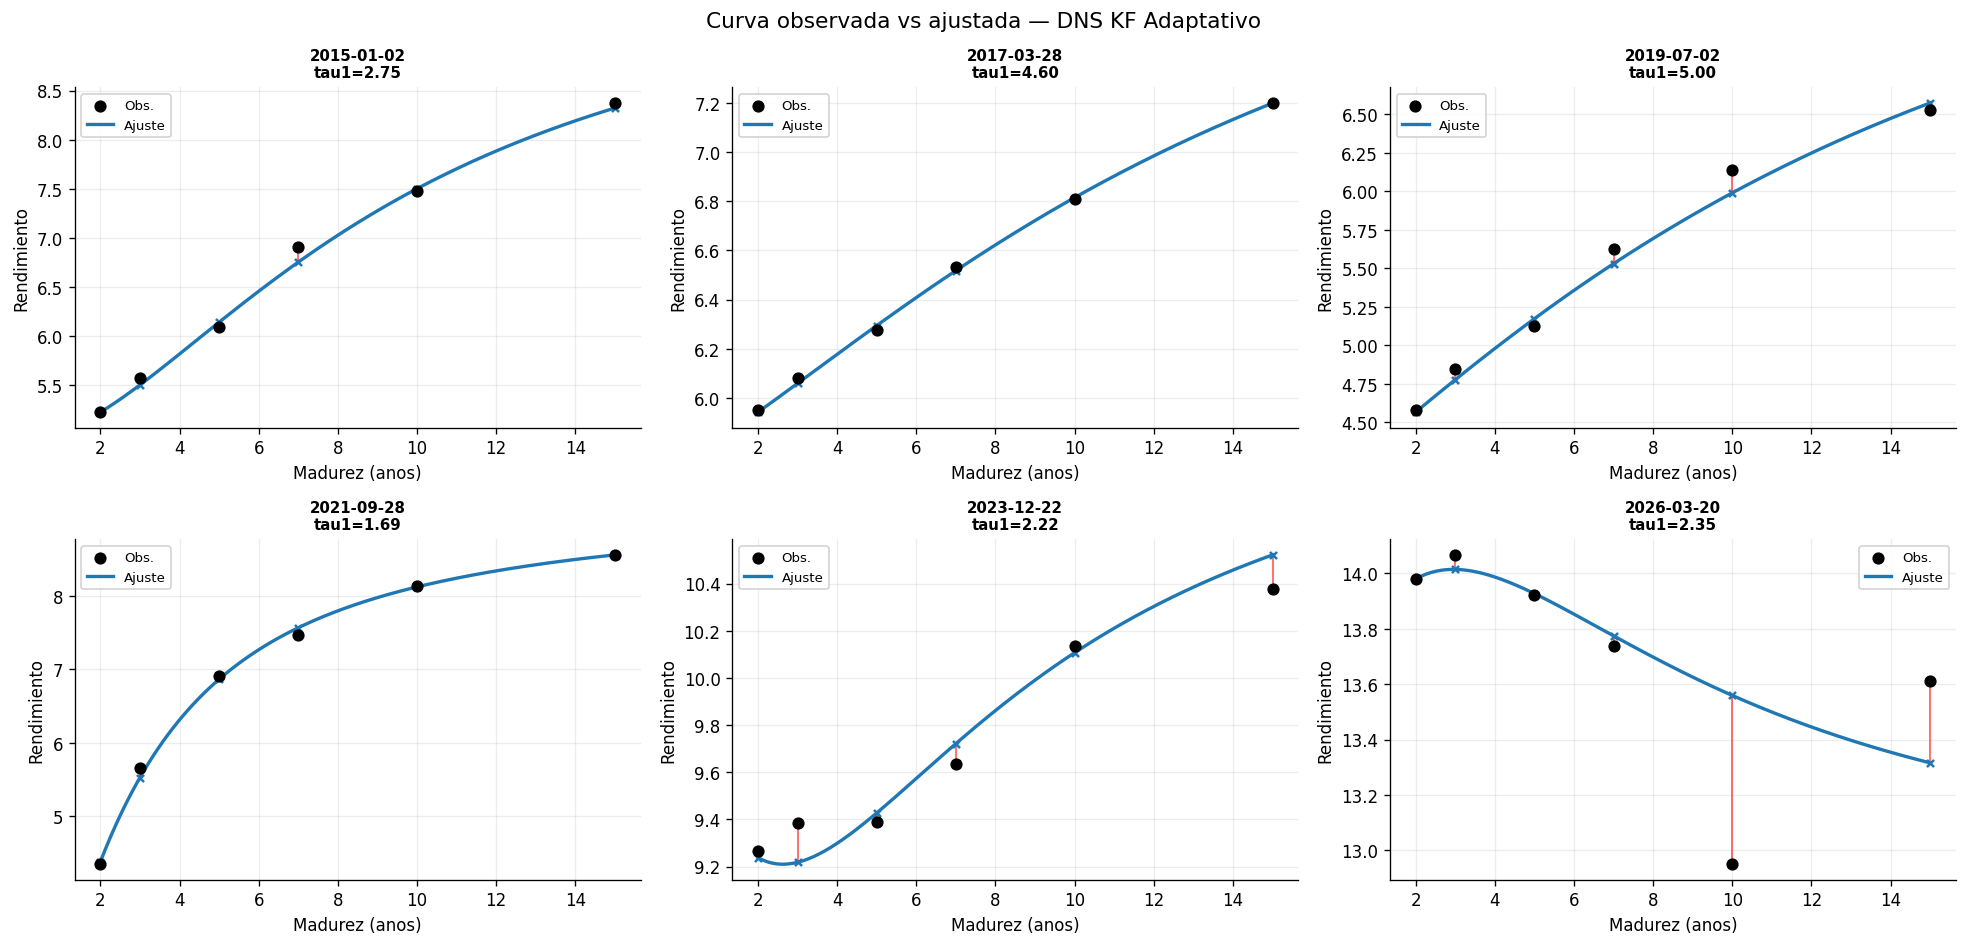

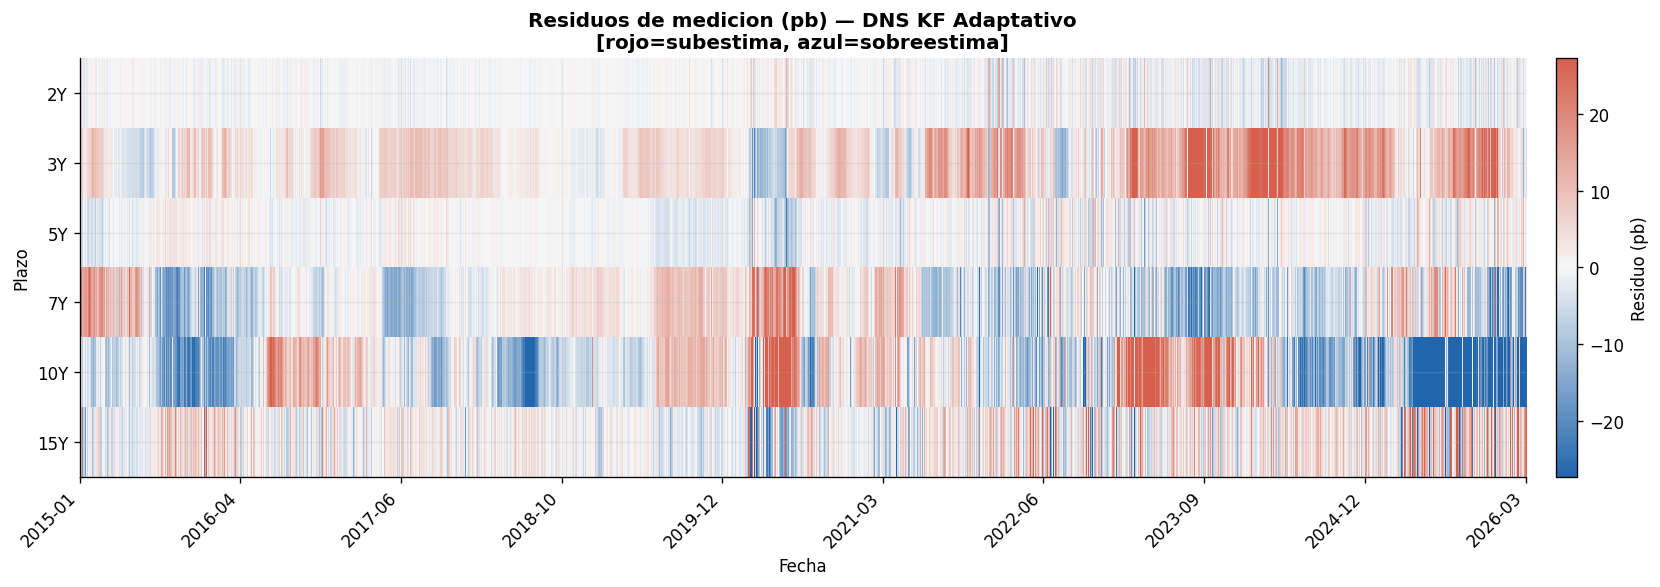

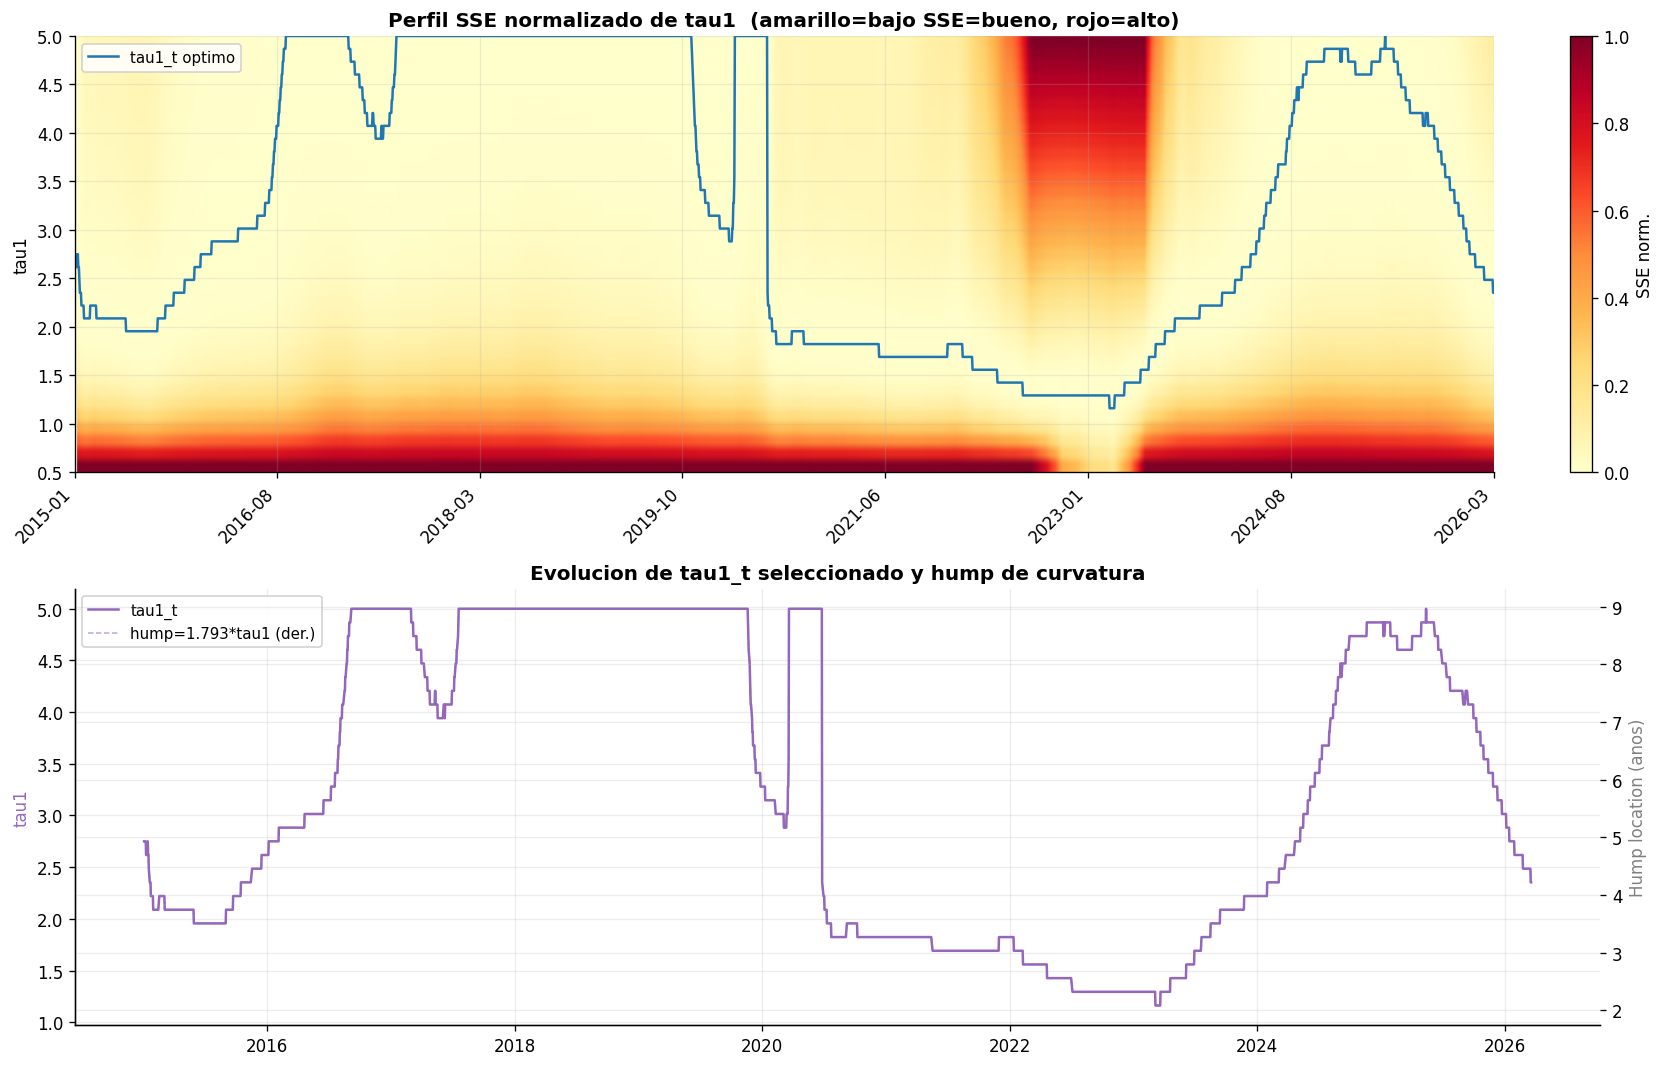

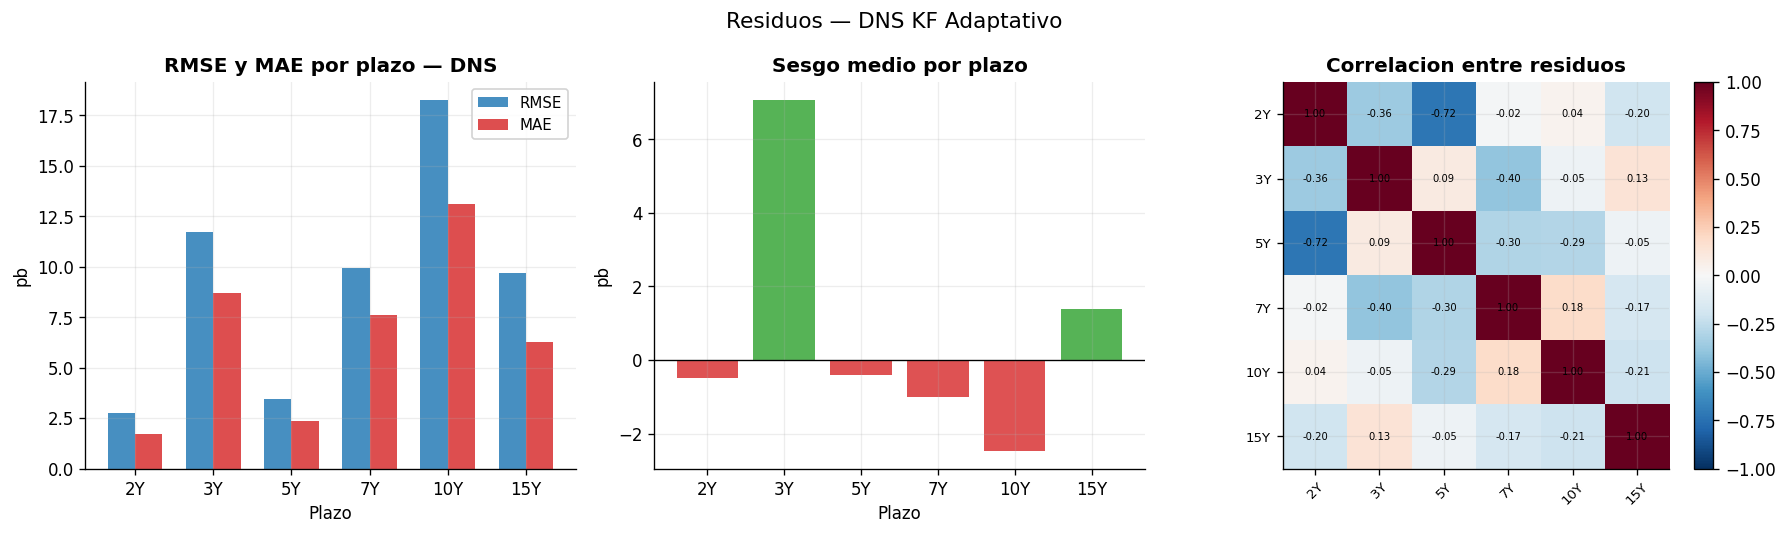

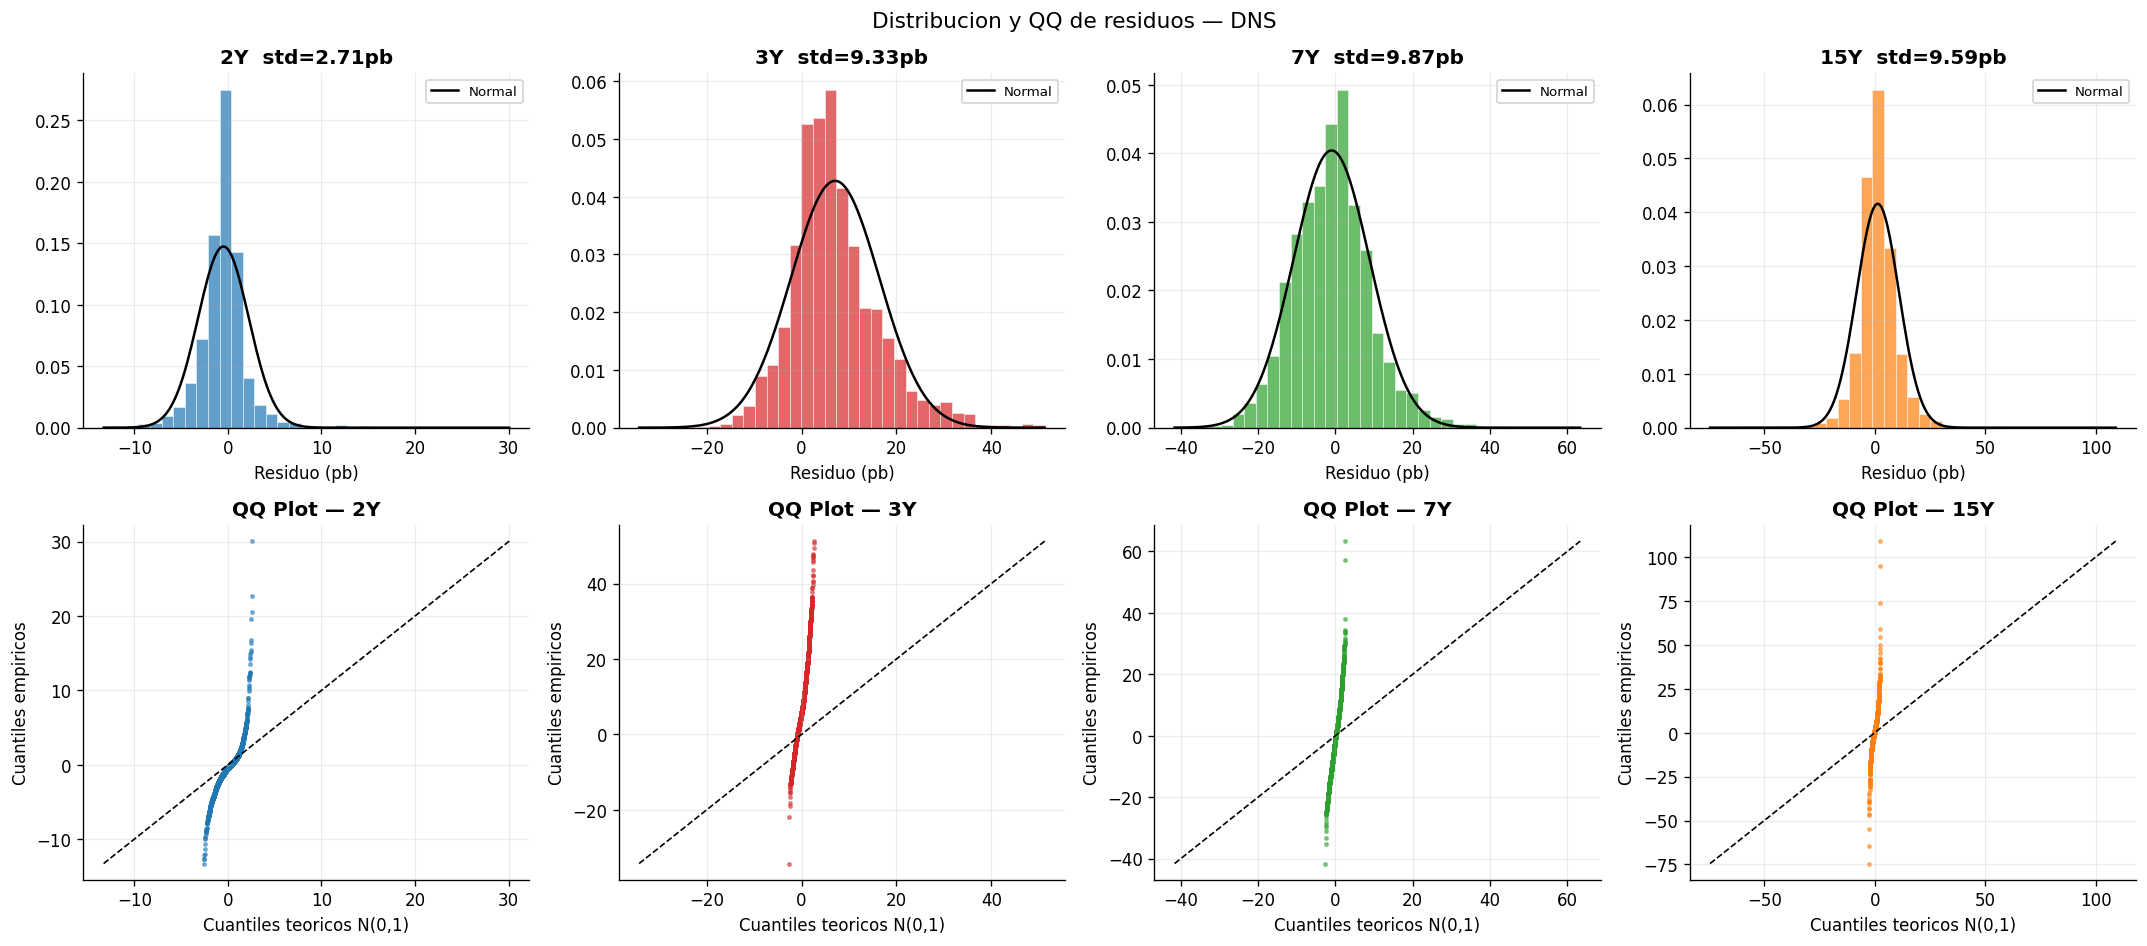

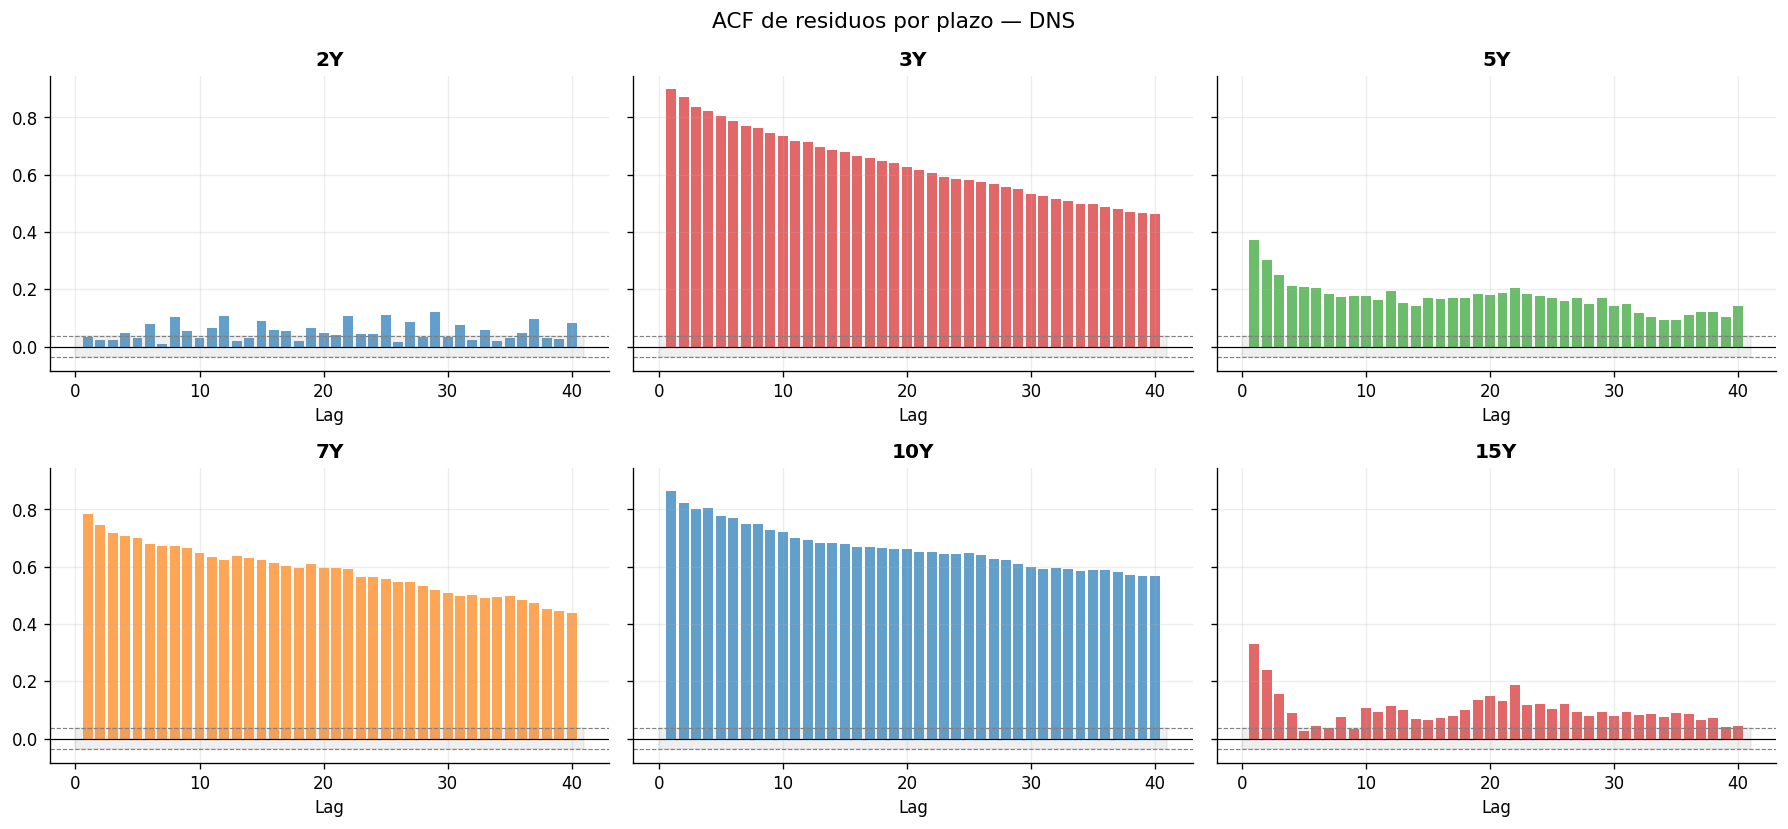


── Tests de residuos — DNS ────────────────────────────────────────
  Plazo      RMSE     Sesgo   JB p-val   LB(10)p  Normal?  SerialCorr?
  ────────────────────────────────────────────────────────────────────────
     2Y     2.748    -0.481     0.0000    0.0000  No      Si
     3Y    11.712    +7.082     0.0000    0.0000  No      Si
     5Y     3.445    -0.395     0.0000    0.0000  No      Si
     7Y     9.919    -0.995     0.0000    0.0000  No      Si
    10Y    18.247    -2.475     0.0000    0.0000  No      Si
    15Y     9.691    +1.392     0.0000    0.0000  No      Si


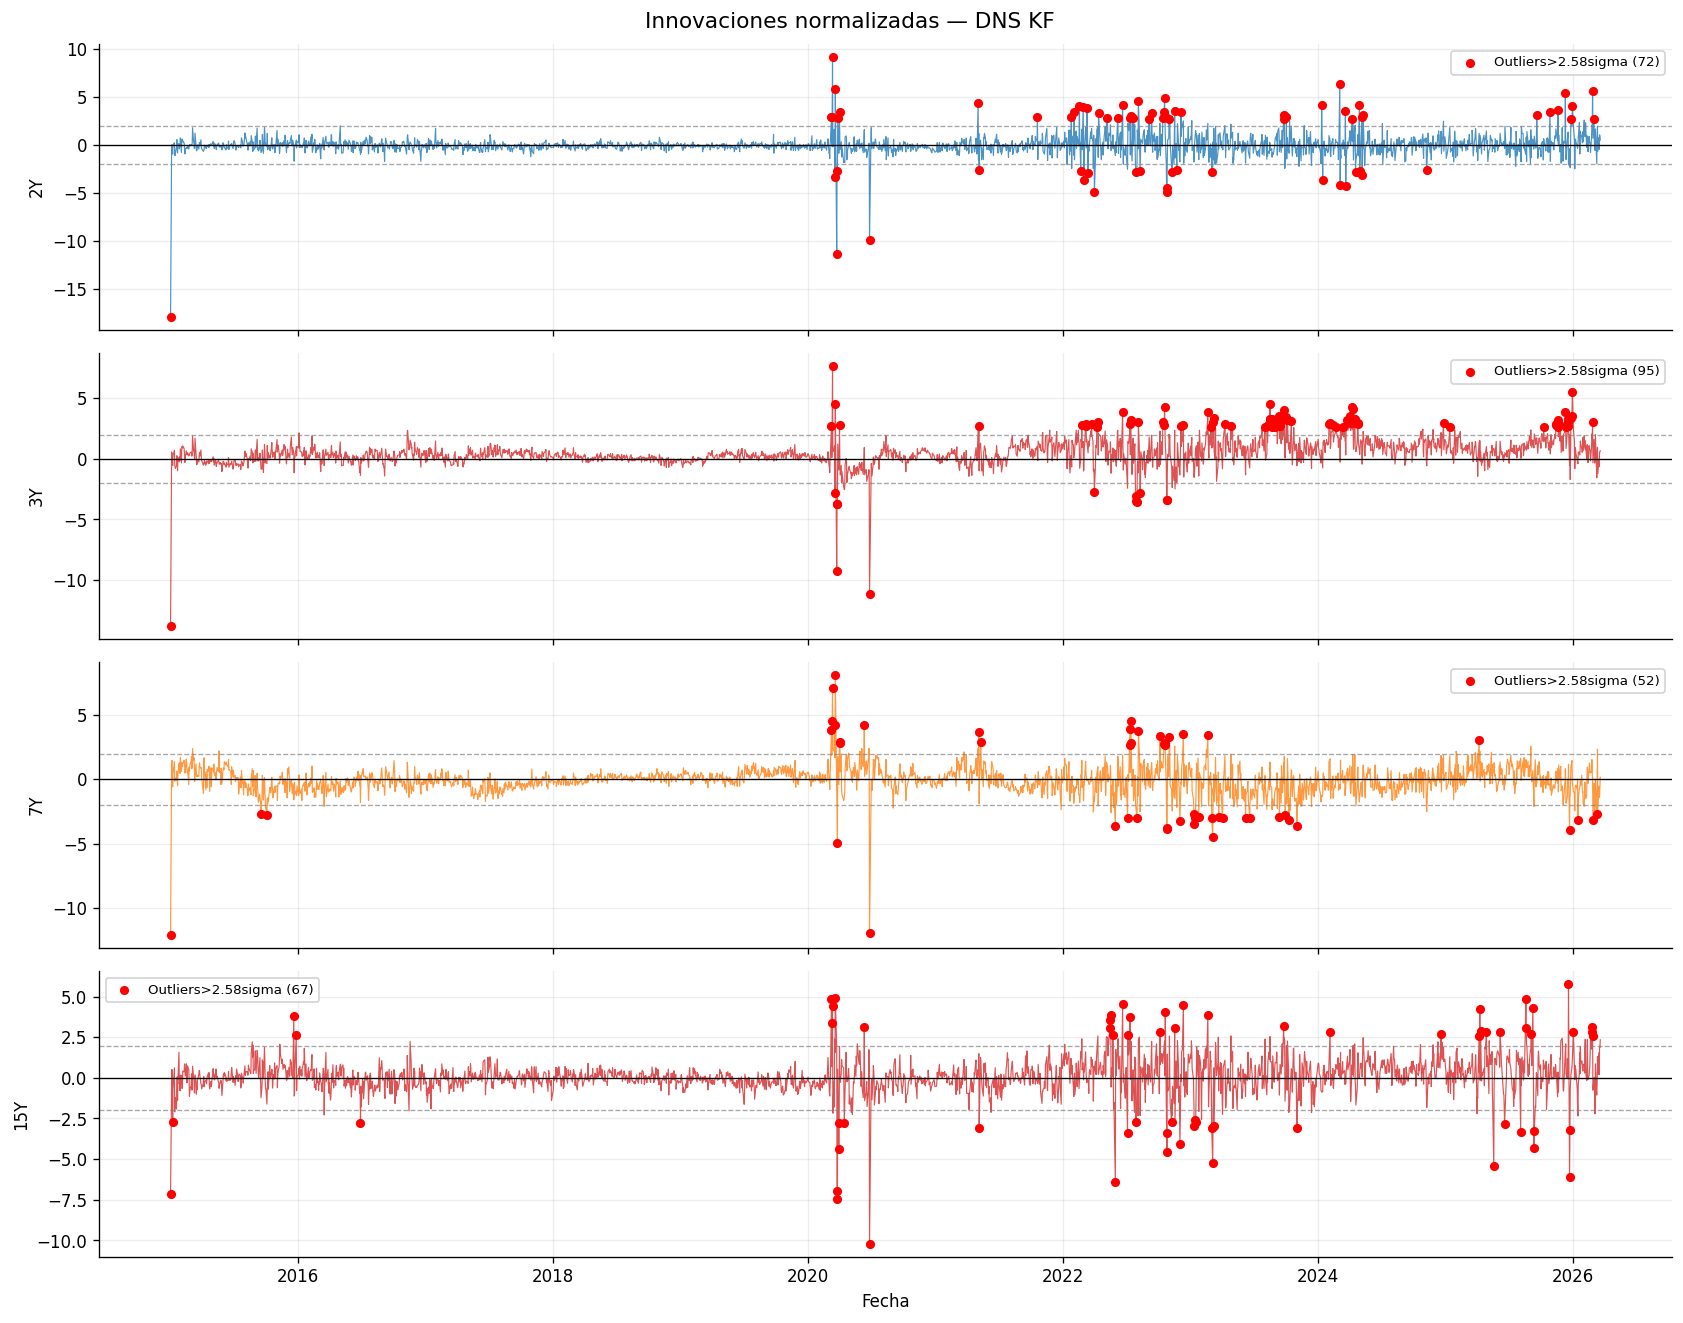

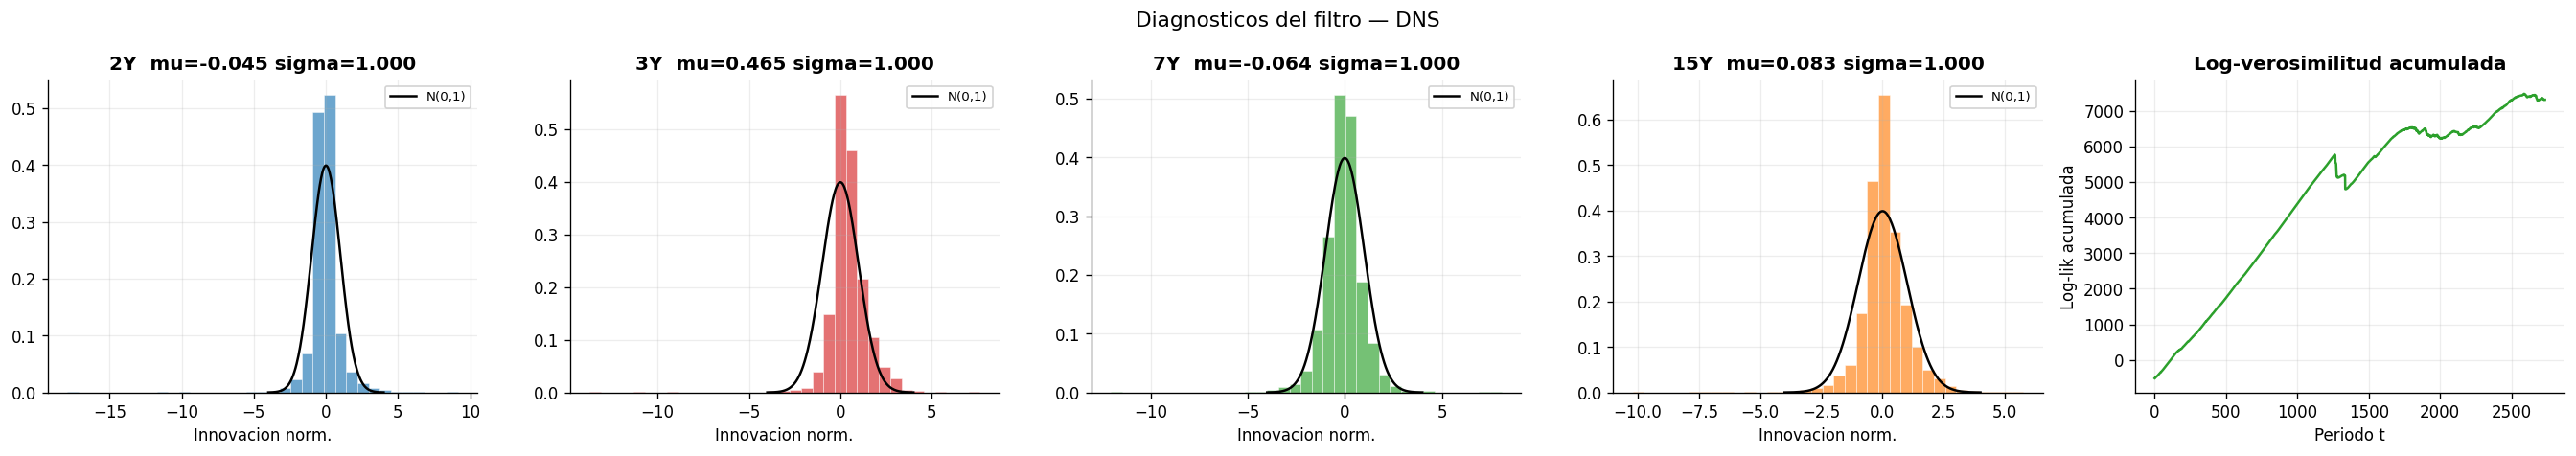


── Test de blancura Ljung-Box (lag 10) — innovaciones DNS ──────────
  Plazo        mu     sigma   LB p-val  Blanco?
  ──────────────────────────────────────────────
     2Y   -0.0452    1.0000     0.0000  No
     3Y   +0.4655    1.0000     0.0000  No
     5Y   -0.0299    1.0000     0.0000  No
     7Y   -0.0644    1.0000     0.0000  No
    10Y   -0.1143    1.0000     0.0000  No
    15Y   +0.0835    1.0000     0.0000  No

  Parametros MLE — DNS  F_type='diagonal'

  mu (media de largo plazo):
    mu_beta0 =  +10.6159
    mu_beta1 =   -4.2760
    mu_beta2 =   -1.3123

  F (matriz de transicion):
    [+0.9950  +0.0000  +0.0000]
    [+0.0000  +0.9950  +0.0000]
    [+0.0000  +0.0000  +0.9950]
    |lambda| = [0.995 0.995 0.995]
    max|lambda|=0.9950  → Estable

  Semividas (diag F):
    beta0(nivel): f_ii=0.9950  semivida~138.3 periodos
    beta1(pend.): f_ii=0.9950  semivida~138.3 periodos
    beta2(curv.): f_ii=0.9950  semivida~138.3 periodos

  sigma_eta (sqrt diag Q) — innovaciones de 

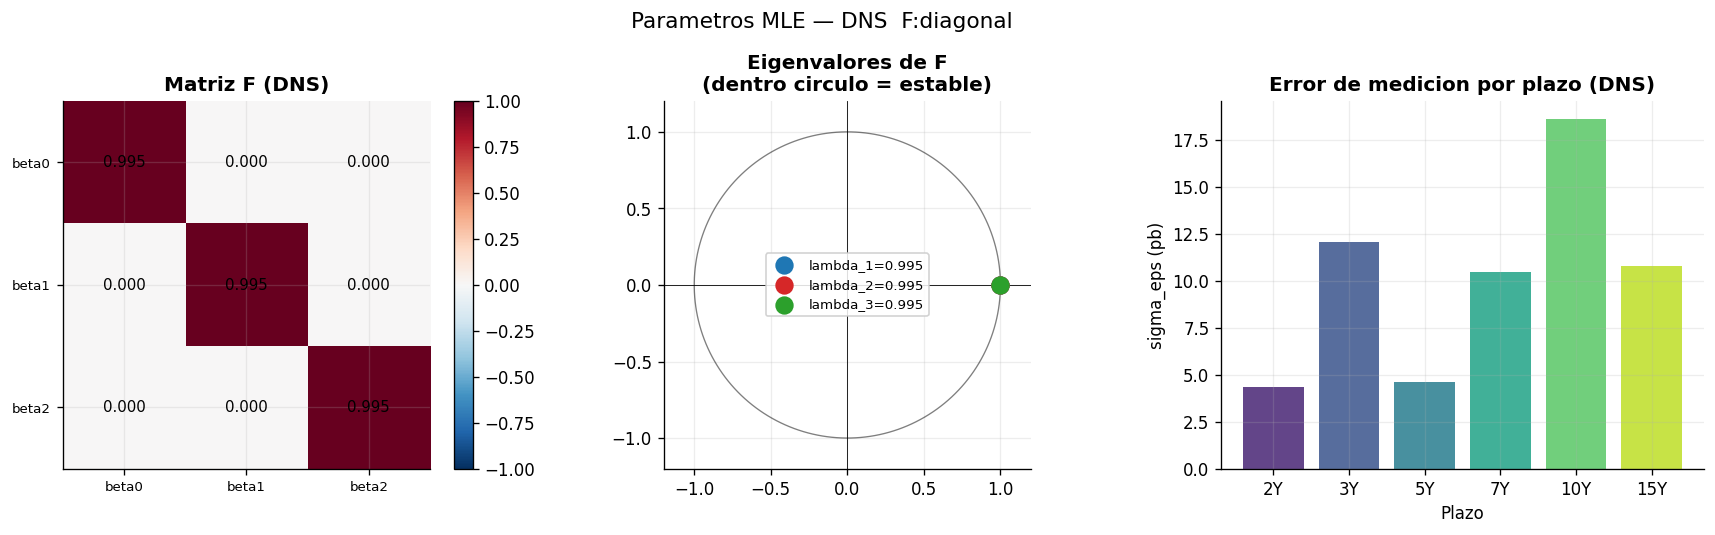


Seccion: valores de F y significancia estadistica

F_type='diagonal':
  [+0.9950  +0.0000  +0.0000]
  [+0.0000  +0.9950  +0.0000]
  [+0.0000  +0.0000  +0.9950]
  max|lambda|=0.9950

F_type='triangular':
  [+0.9950  +0.0000  +0.0000]
  [+0.0028  +0.9950  +0.0000]
  [+0.0023  -0.0022  +0.9950]
  max|lambda|=0.9950

F_type='completa':
  [+1.1665  +0.5533  -0.2861]
  [-0.3352  +0.0343  +0.2173]
  [-0.1267  +0.1283  -0.1270]
  max|lambda|=0.9995

Resumen SSE y parametros estimados:
F_type                  SSE     nobs   params
diagonal            186.491    16410       15
triangular          186.491    16410       18
completa           2865.043    16410       21

Test F: restringido (diagonal) vs no restringido
Comparacion                      F-stat      p-value   Signif(0.05)
diagonal vs triangular           0.0094       0.9987             NO
diagonal vs completa             0.0000            1             NO

Nota: p-value < 0.05 sugiere que la estructura mas flexible mejora el ajuste d

In [20]:
print("Experimento: impacto del tipo de F en DNS")
print("="*55)

resultados_F = {}
for f_type in ['diagonal', 'triangular', 'completa']:
    print(f"\n  F_type = '{f_type}' ...")
    r = fit_dns_kalman(
        dates       = dates_dt,
        yields      = yields_data,
        maturities  = maturities,
        model       = 'DNS',
        F_type      = f_type,
        window_size = max(52, T//8),
        n_starts    = 2,
        plot        = False,
        verbose     = False,
    )
    resultados_F[f_type] = r
    print(f"    RMSE={r['rmse_total']*100:.4f}pb  "
          f"log-lik={r['loglik']:,.1f}  "
          f"AIC={r['aic']:,.1f}  BIC={r['bic']:,.1f}")

print(f"\n{'─'*58}")
print(f"  {'F_type':<12} {'RMSE(pb)':>9} {'Log-lik':>12} {'AIC':>10} {'BIC':>10}")
print(f"  {'─'*58}")
for ft, r in resultados_F.items():
    print(f"  {ft:<12} {r['rmse_total']*100:>9.4f} {r['loglik']:>12,.1f} "
          f"{r['aic']:>10,.1f} {r['bic']:>10,.1f}")

best_aic = min(resultados_F, key=lambda k: resultados_F[k]['aic'])
best_bic = min(resultados_F, key=lambda k: resultados_F[k]['bic'])
print(f"\n  Mejor por AIC: F_type='{best_aic}'")
print(f"  Mejor por BIC: F_type='{best_bic}'")

# Graficos completos del mejor modelo
print(f"\n  Generando graficos completos para F_type='{best_aic}' ...")
res_best = resultados_F[best_aic]
plot_factores(res_best,       titulo_extra=f"[F_type='{best_aic}']")
plot_tau_evolution(res_best)
plot_curvas_ajustadas(res_best, n_fechas=6)
plot_heatmap_residuos(res_best)
plot_perfil_sse_tau(res_best)
analisis_residuos(res_best)
diagnosticos_filtro(res_best)
resumen_parametros(res_best)

# --- Seccion: valores de F y significancia estadistica -----------------
print("\nSeccion: valores de F y significancia estadistica")

# Mostrar matrices F por tipo
for ft, r in resultados_F.items():
    print(f"\nF_type='{ft}':")
    F = r.get('F', None)
    if F is None:
        print("  (F no disponible)")
        continue
    for row in F:
        print("  [" + "  ".join(f"{v:+.4f}" for v in row) + "]")
    eig = np.linalg.eigvals(F)
    print(f"  max|lambda|={np.max(np.abs(eig)):.4f}")

def _get_resid(r):
    if 'residuals' in r and r['residuals'] is not None:
        return r['residuals']
    if 'innovations' in r and r['innovations'] is not None:
        return r['innovations']
    if 'fitted' in r and r['fitted'] is not None and 'yields' in r:
        return r['yields'] - r['fitted']
    return None

def _param_count(r, ft):
    if 'mu' in r and getattr(r['mu'], 'shape', None):
        k = r['mu'].shape[0]
    elif 'beta_smoothed' in r and getattr(r['beta_smoothed'], 'shape', None):
        k = r['beta_smoothed'].shape[1]
    else:
        k = 3
    if 'yields' in r and getattr(r['yields'], 'shape', None):
        N = r['yields'].shape[1]
    elif 'residuals' in r and getattr(r['residuals'], 'shape', None):
        N = r['residuals'].shape[1]
    else:
        N = len(maturities)
    if ft == 'diagonal':
        f_params = k
    elif ft == 'triangular':
        f_params = k * (k + 1) // 2
    else:
        f_params = k * k
    # mu (k) + Q_diag (k) + R_diag (N) + F_params
    return (2*k + N + f_params)

sse_by_type = {}
nobs_by_type = {}
p_by_type = {}
for ft, r in resultados_F.items():
    resid = _get_resid(r)
    if resid is None:
        print(f"  No hay residuos para F_type='{ft}', omitiendo test F.")
        continue
    resid = np.asarray(resid)
    sse_by_type[ft] = float(np.sum(resid**2))
    nobs_by_type[ft] = resid.size
    p_by_type[ft] = _param_count(r, ft)

print("\nResumen SSE y parametros estimados:")
print(f"{'F_type':<12} {'SSE':>14} {'nobs':>8} {'params':>8}")
for ft in resultados_F:
    if ft in sse_by_type:
        print(f"{ft:<12} {sse_by_type[ft]:>14.3f} {nobs_by_type[ft]:>8d} {p_by_type[ft]:>8d}")

base = 'diagonal'
if base in sse_by_type:
    print("\nTest F: restringido (diagonal) vs no restringido")
    print(f"{'Comparacion':<26} {'F-stat':>12} {'p-value':>12} {'Signif(0.05)':>14}")
    for ft in ['triangular', 'completa']:
        if ft not in sse_by_type:
            continue
        sse_r = sse_by_type[base]
        sse_u = sse_by_type[ft]
        p_r = p_by_type[base]
        p_u = p_by_type[ft]
        nobs = nobs_by_type[ft]
        df1 = p_u - p_r
        df2 = max(nobs - p_u, 1)
        if df1 <= 0 or sse_r <= sse_u:
            Fstat = 0.0
            pval = 1.0
        else:
            Fstat = ((sse_r - sse_u) / df1) / (sse_u / df2)
            pval = stats.f.sf(Fstat, df1, df2)
        signif = "SI" if pval < 0.05 else "NO"
        print(f"{base+' vs '+ft:<26} {Fstat:12.4f} {pval:12.4g} {signif:>14}")
    print("\nNota: p-value < 0.05 sugiere que la estructura mas flexible mejora el ajuste de forma significativa.")

Plazos disponibles: ['2Y', '3Y', '5Y', '7Y', '10Y', '15Y']

Pesos DNS  : {'2Y': np.float64(1.0), '3Y': np.float64(1.0), '5Y': np.float64(1.0), '7Y': np.float64(1.0), '10Y': np.float64(2.5), '15Y': np.float64(2.5)}
Pesos DNSS : {'2Y': np.float64(1.0), '3Y': np.float64(1.0), '5Y': np.float64(1.0), '7Y': np.float64(1.0), '10Y': np.float64(2.0), '15Y': np.float64(2.0)}

  DNS — R grupos + pesos en plazos largos
  Ajuste DNS | F:diagonal | ventana:rodante W=341

[1/4] Grid search tau_t ...
  tau1: med=3.015  [1.16, 5.00]  hump_med~5.4Y
  → 0.1s

[2/4] Construyendo H_arr ...

[3/4] MLE (mu, F, Q, R) ...
  MLE multi-start (6 intentos) — F:'diagonal'  R:R-grupos  log-lik:ponderada
    Start 1: log-lik=8,433.41 (OK)
    Start 2: log-lik=8,433.41 (OK)
    Start 3: log-lik=8,433.41 (OK)
    Start 4: log-lik=8,433.41 (OK)
    Start 5: log-lik=8,433.39 (OK)
    Start 6: log-lik=8,433.41 (OK)

  Mejor log-lik = 8,433.41
  F estable: True  (max|lambda|=0.9950)
  mu         = [10.321 -4.07  -0.644]
  

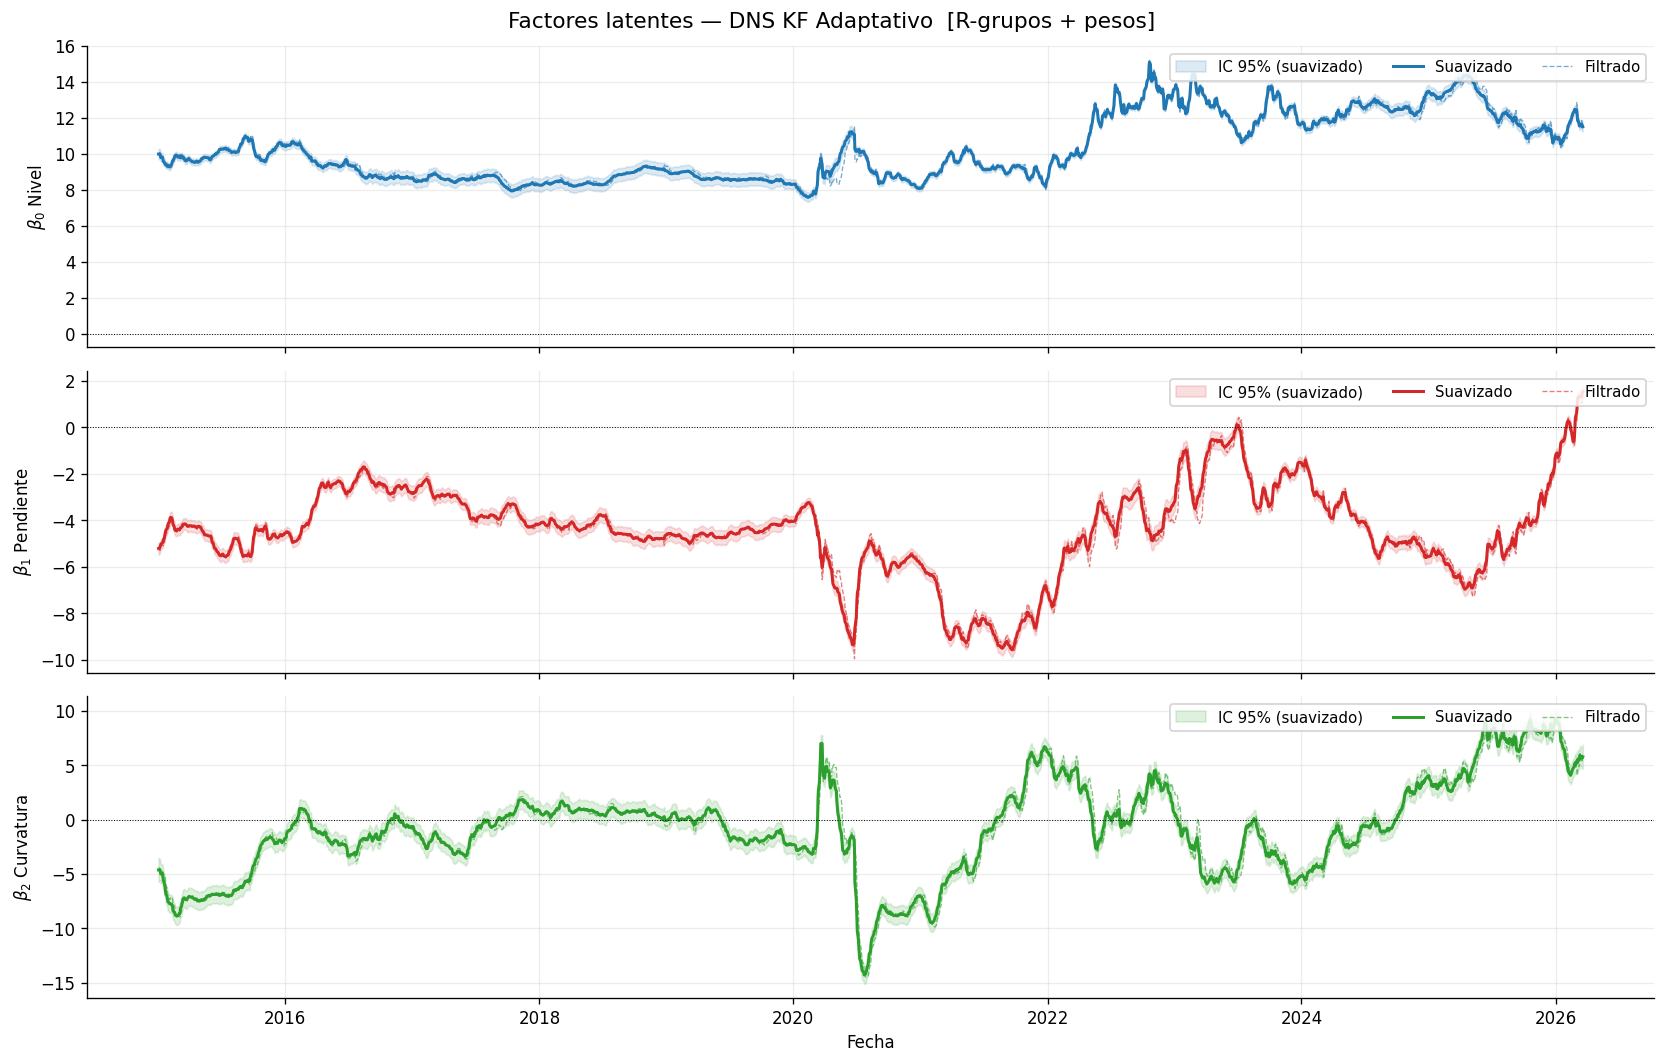


── Estadisticos de factores suavizados (DNS) ───────────────
Factor        Media    Std     Min     Q25     Med     Q75     Max
──────────────────────────────────────────────────────────────────
  $\beta_0$ Ni  +10.258   1.800   +7.576  +8.686  +9.600 +11.933 +15.114
  $\beta_1$ Pe   -4.396   1.929   -9.571  -5.213  -4.367  -3.236  +1.547
  $\beta_2$ Cu   -0.820   4.198  -14.280  -2.931  -0.713  +1.081  +9.239

── Autocorrelaciones lag-1 y lag-5 (suavizado) ─────────────────
  $\beta_0$ Nive  rho(1)=0.9991   rho(5)=0.9900
  $\beta_1$ Pend  rho(1)=0.9994   rho(5)=0.9888
  $\beta_2$ Curv  rho(1)=0.9991   rho(5)=0.9863


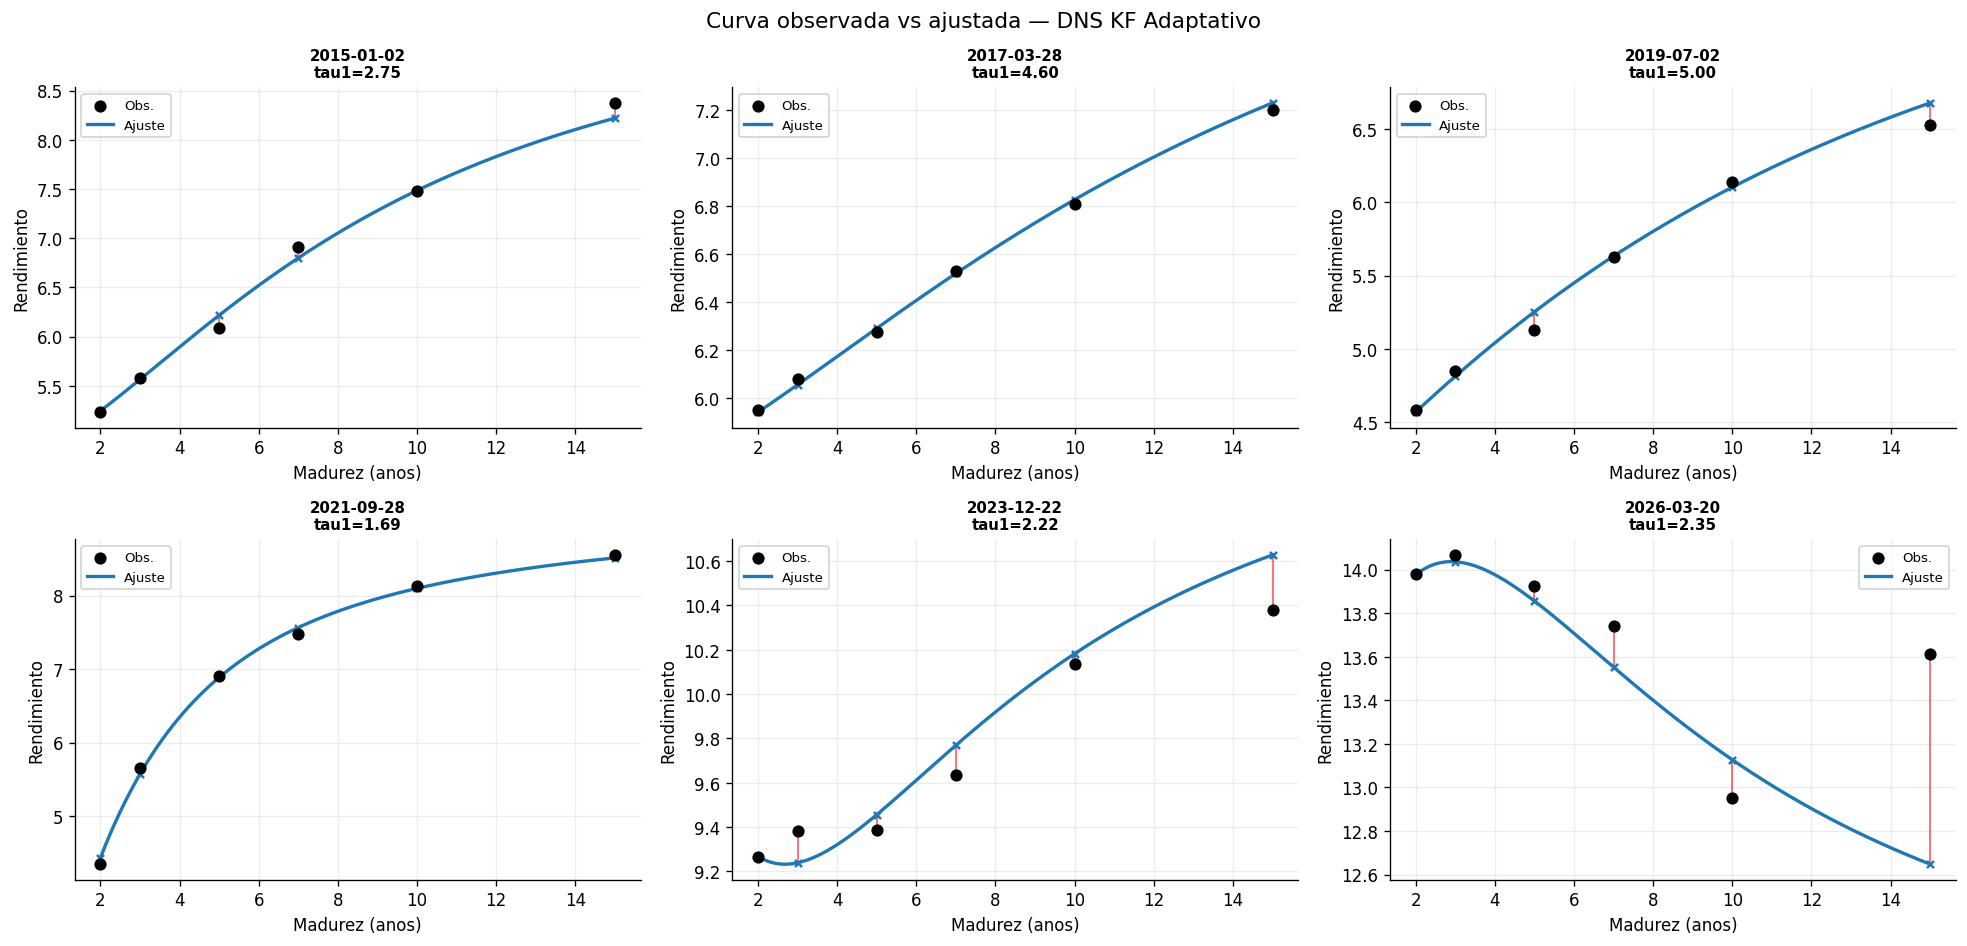

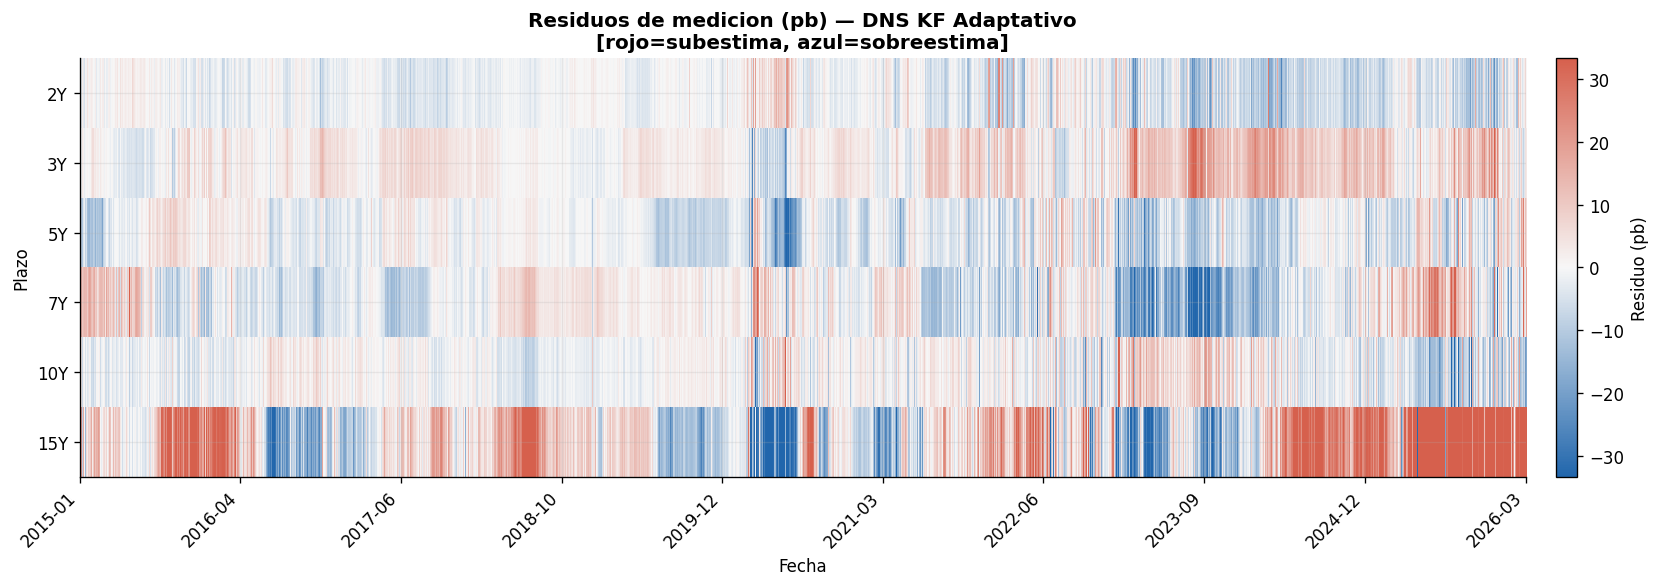

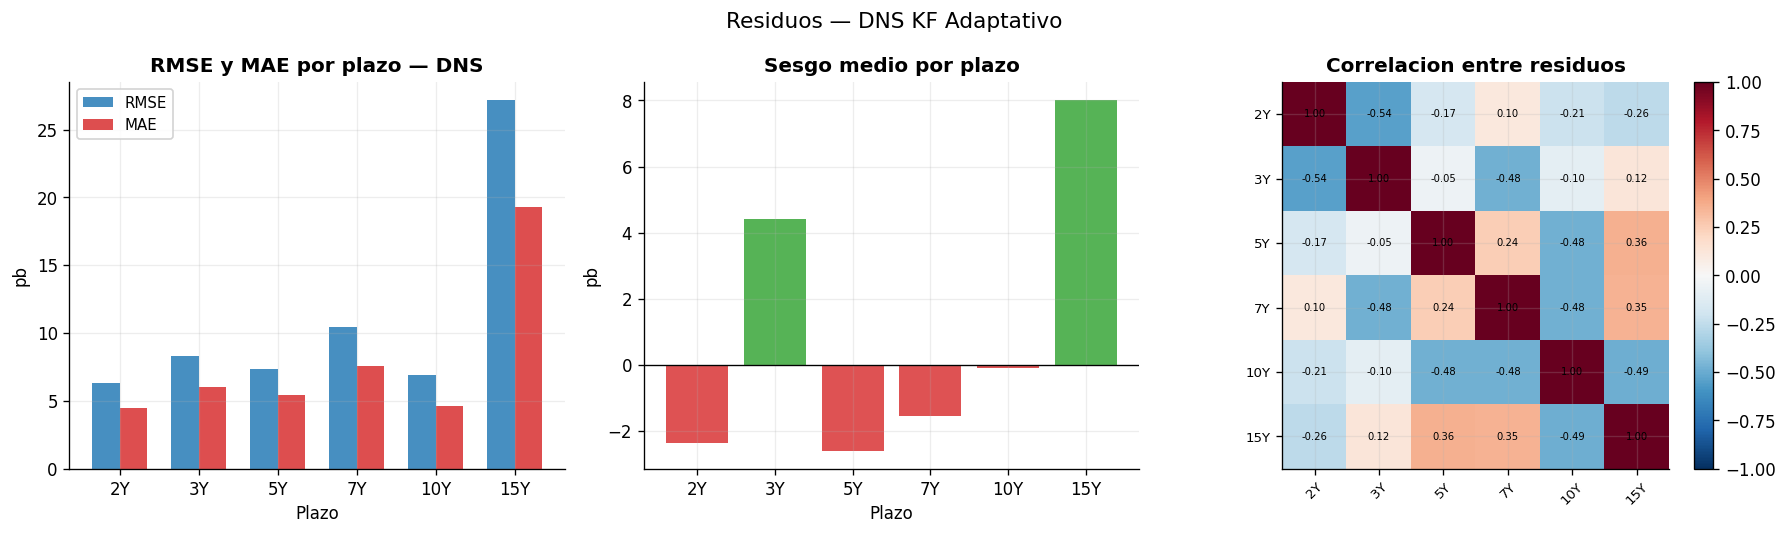

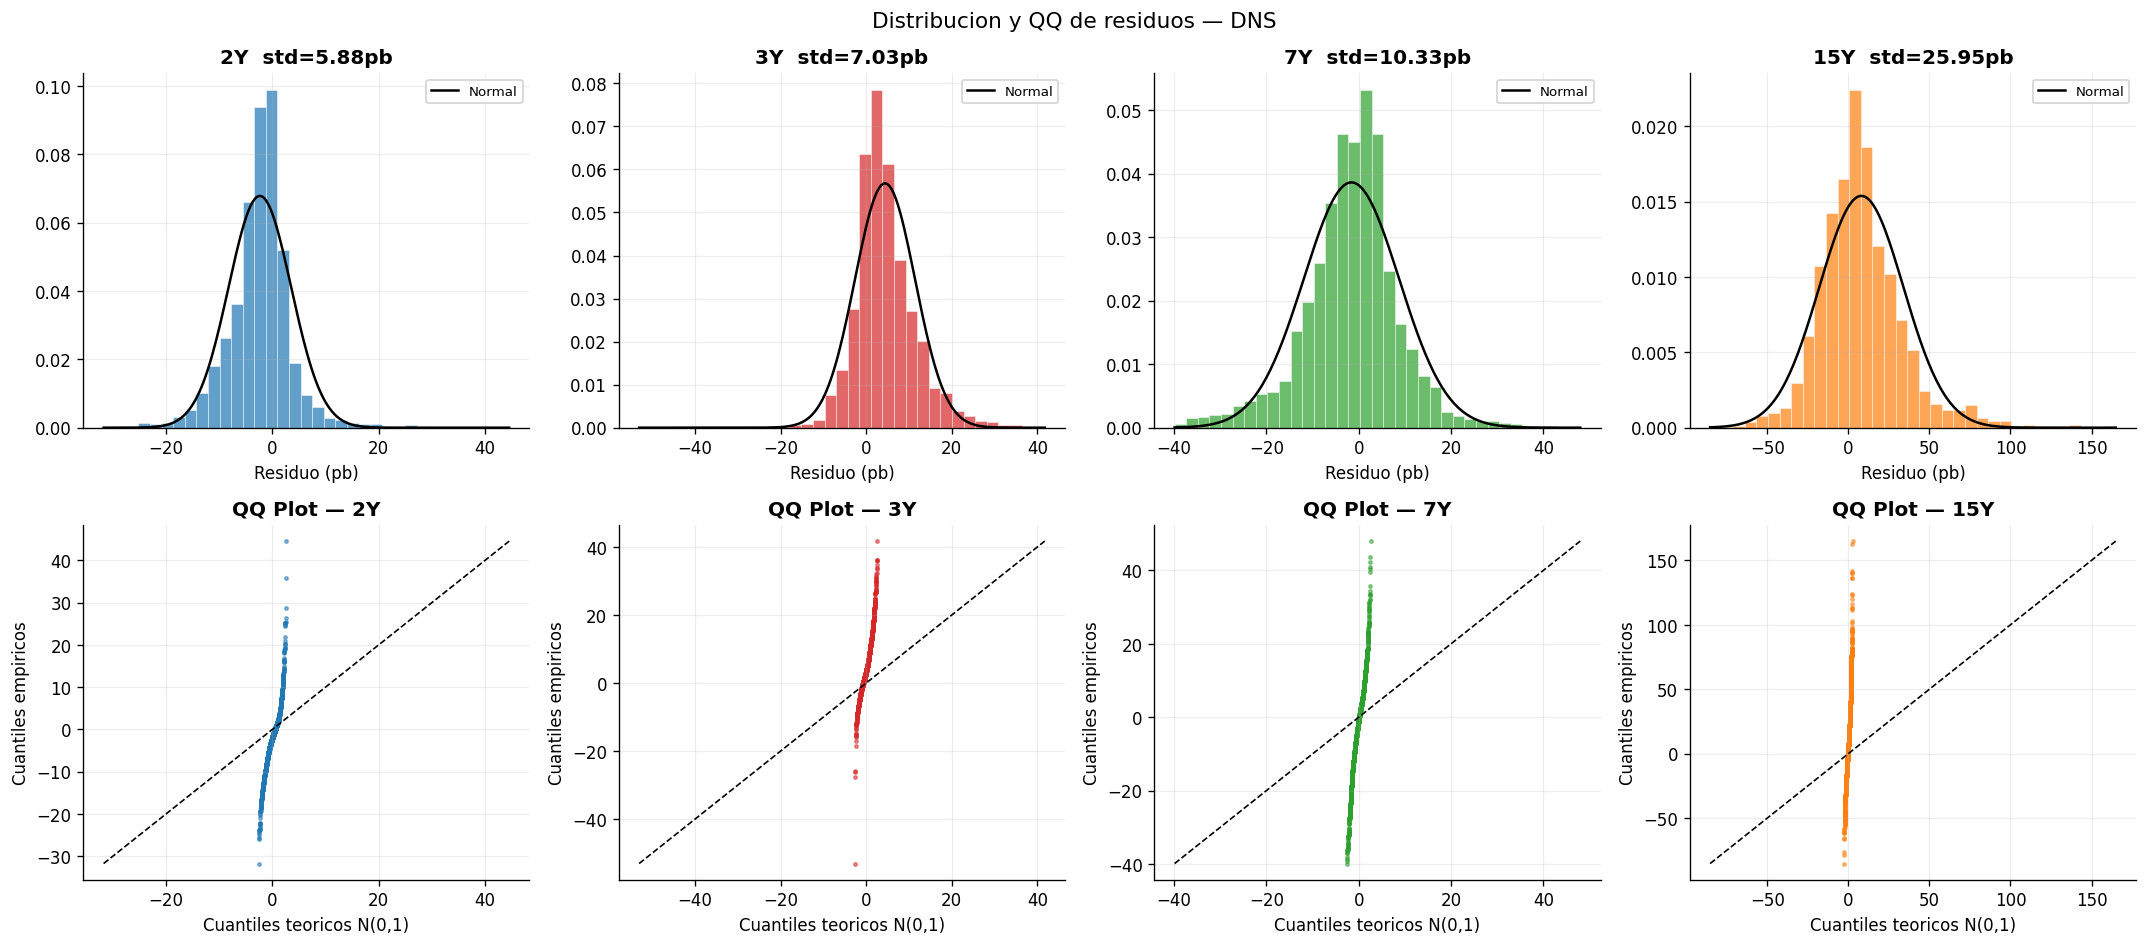

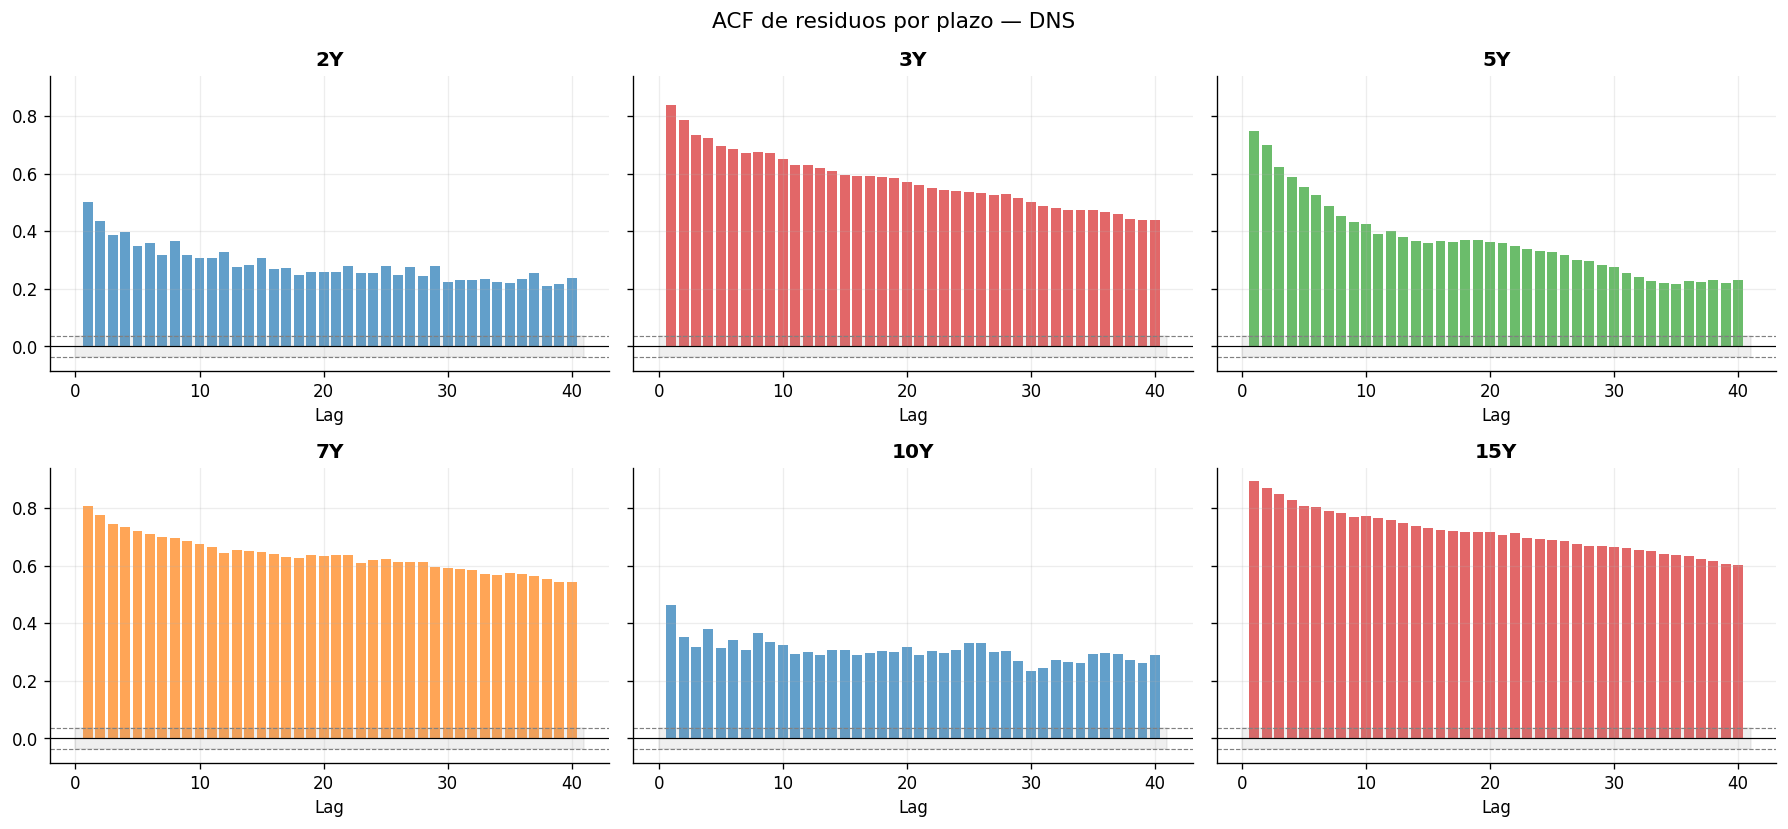


── Tests de residuos — DNS ────────────────────────────────────────
  Plazo      RMSE     Sesgo   JB p-val   LB(10)p  Normal?  SerialCorr?
  ────────────────────────────────────────────────────────────────────────
     2Y     6.338    -2.355     0.0000    0.0000  No      Si
     3Y     8.291    +4.401     0.0000    0.0000  No      Si
     5Y     7.340    -2.614     0.0000    0.0000  No      Si
     7Y    10.445    -1.567     0.0000    0.0000  No      Si
    10Y     6.875    -0.113     0.0000    0.0000  No      Si
    15Y    27.159    +8.026     0.0000    0.0000  No      Si

  Graficos completos DNSS con Opciones A+C ...


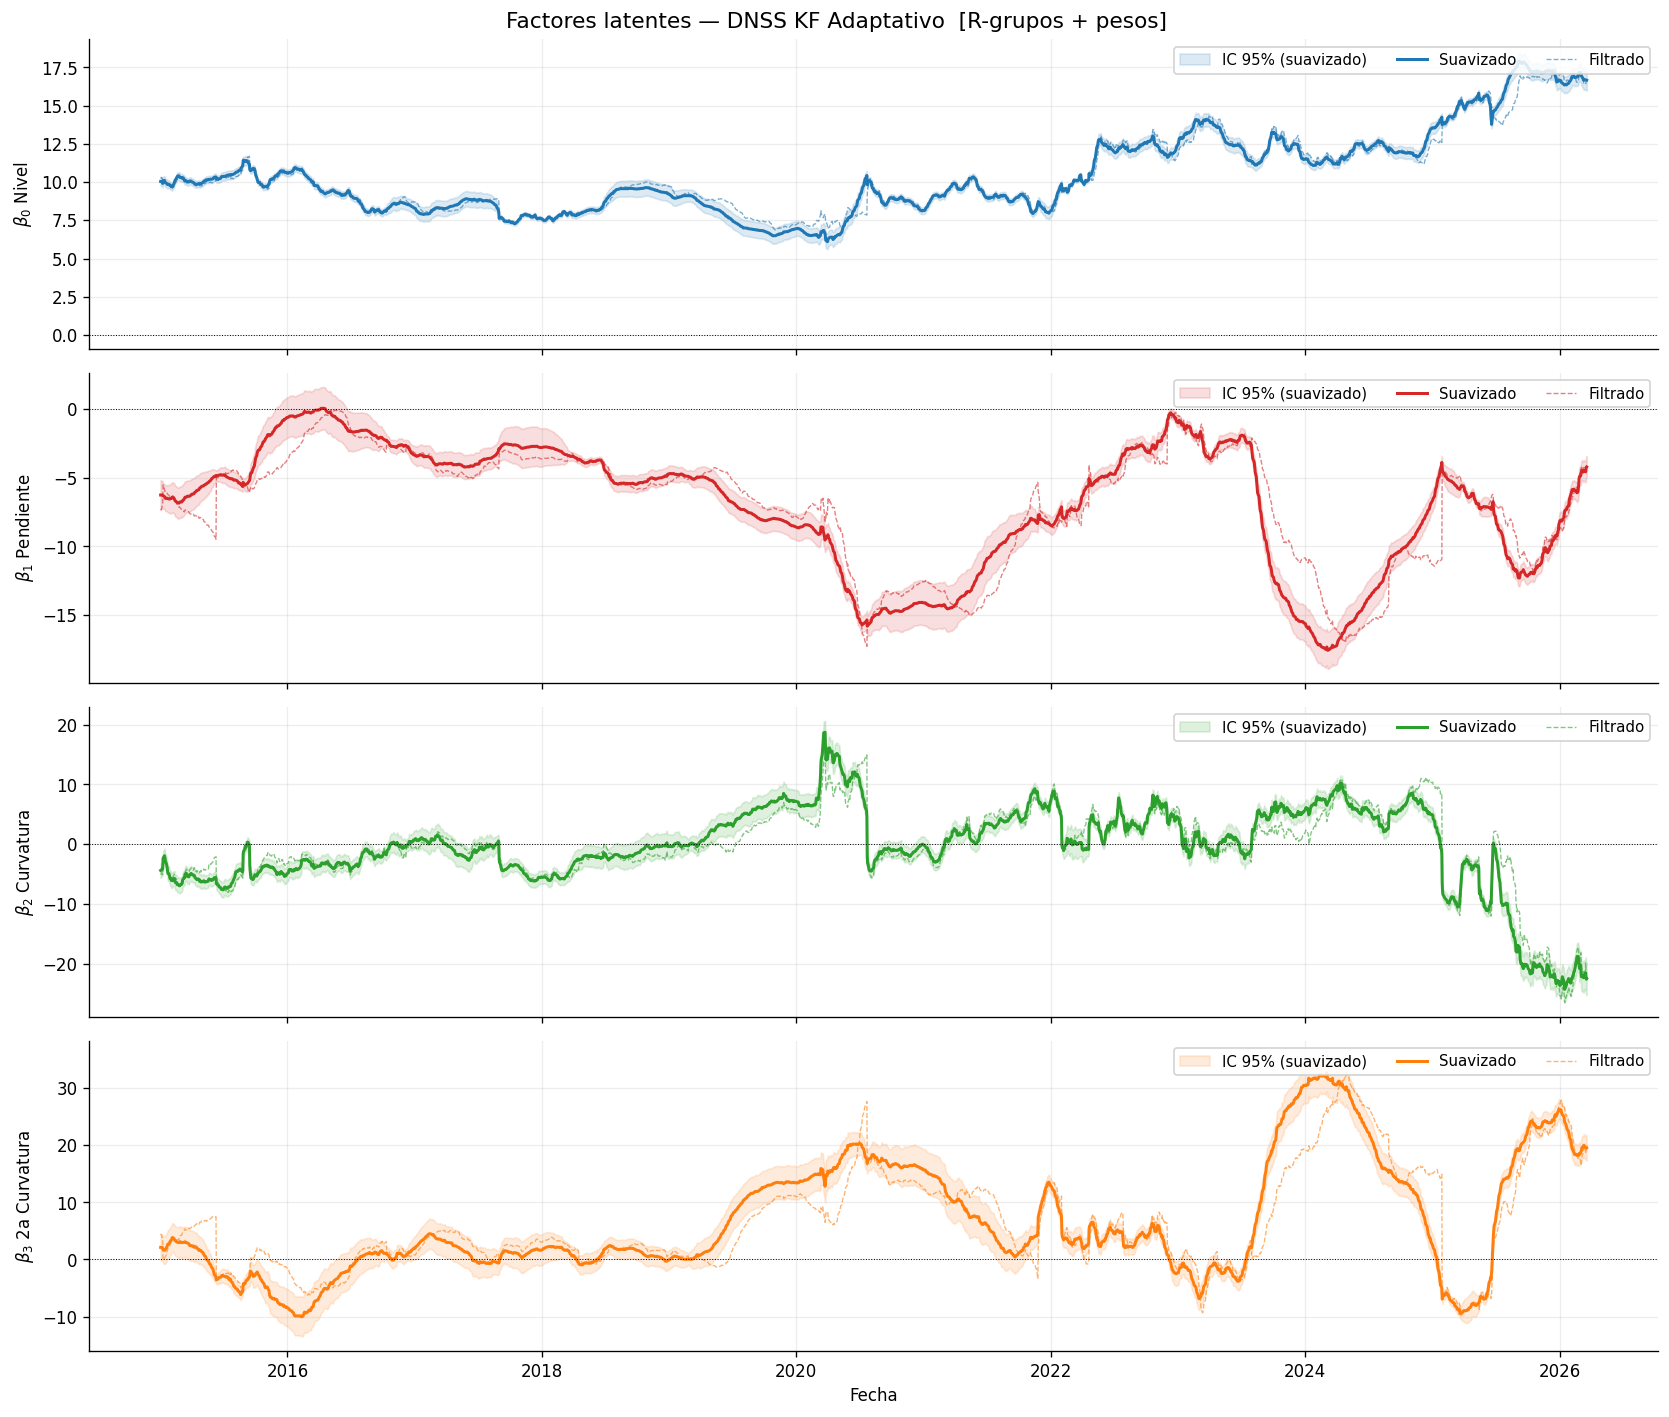


── Estadisticos de factores suavizados (DNSS) ───────────────
Factor        Media    Std     Min     Q25     Med     Q75     Max
──────────────────────────────────────────────────────────────────
  $\beta_0$ Ni  +10.393   2.677   +6.100  +8.431  +9.623 +12.069 +17.915
  $\beta_1$ Pe   -6.950   4.504  -17.586  -9.875  -5.613  -3.363  +0.074
  $\beta_2$ Cu   -0.411   6.894  -24.242  -3.474  -0.231  +4.579 +18.721
  $\beta_3$ 2a   +6.543   9.892  -10.024  +0.151  +2.935 +13.685 +32.625

── Autocorrelaciones lag-1 y lag-5 (suavizado) ─────────────────
  $\beta_0$ Nive  rho(1)=0.9998   rho(5)=0.9969
  $\beta_1$ Pend  rho(1)=0.9999   rho(5)=0.9977
  $\beta_2$ Curv  rho(1)=0.9983   rho(5)=0.9836
  $\beta_3$ 2a C  rho(1)=0.9997   rho(5)=0.9959


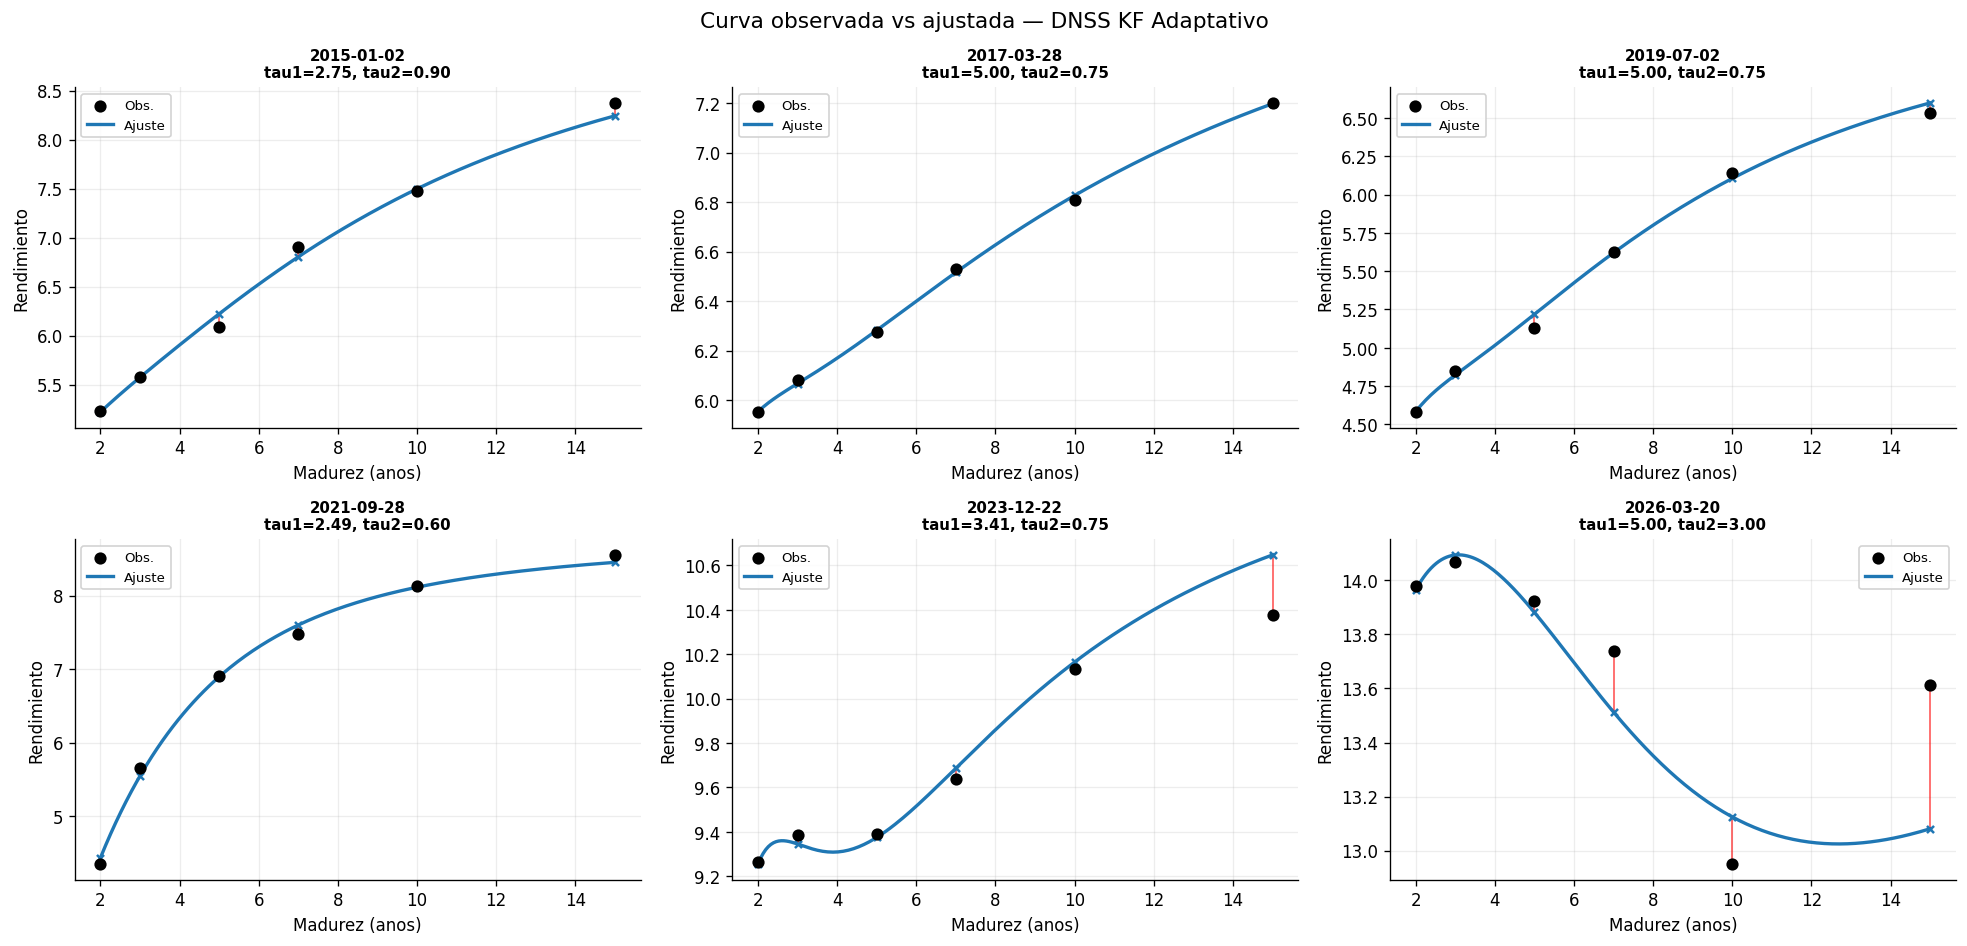

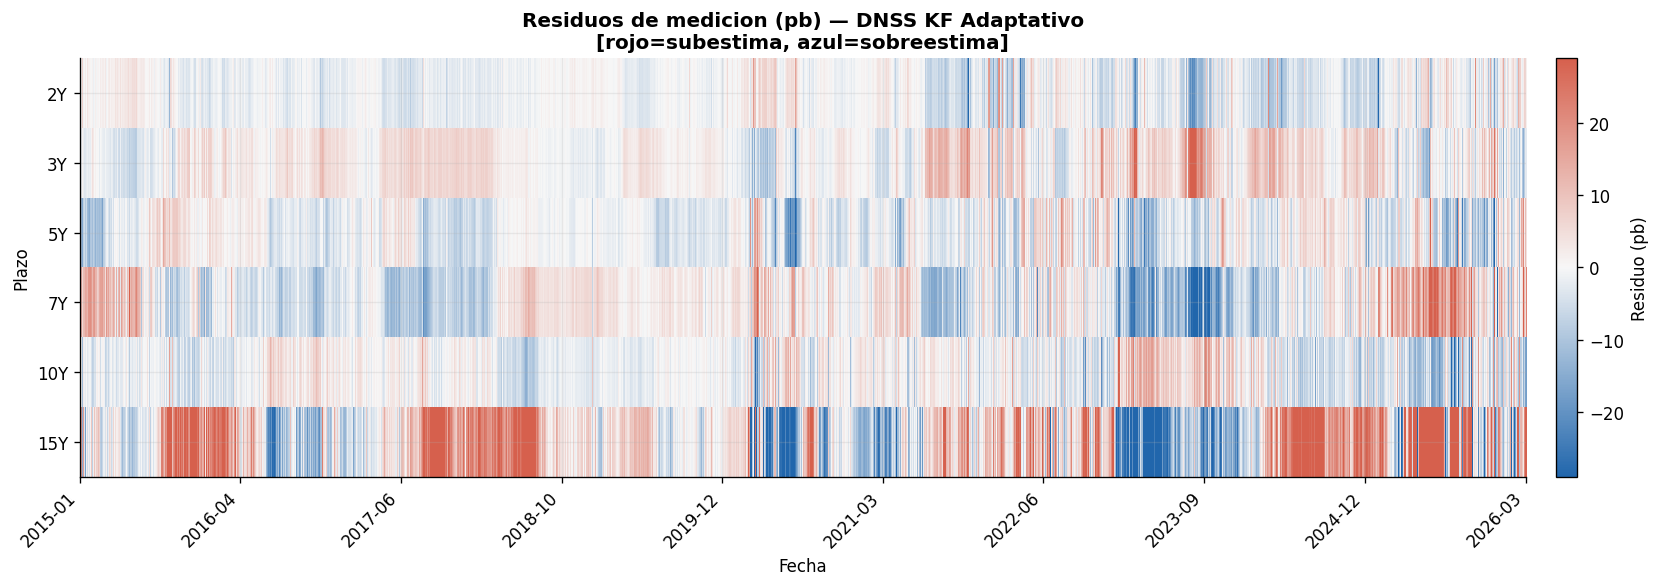

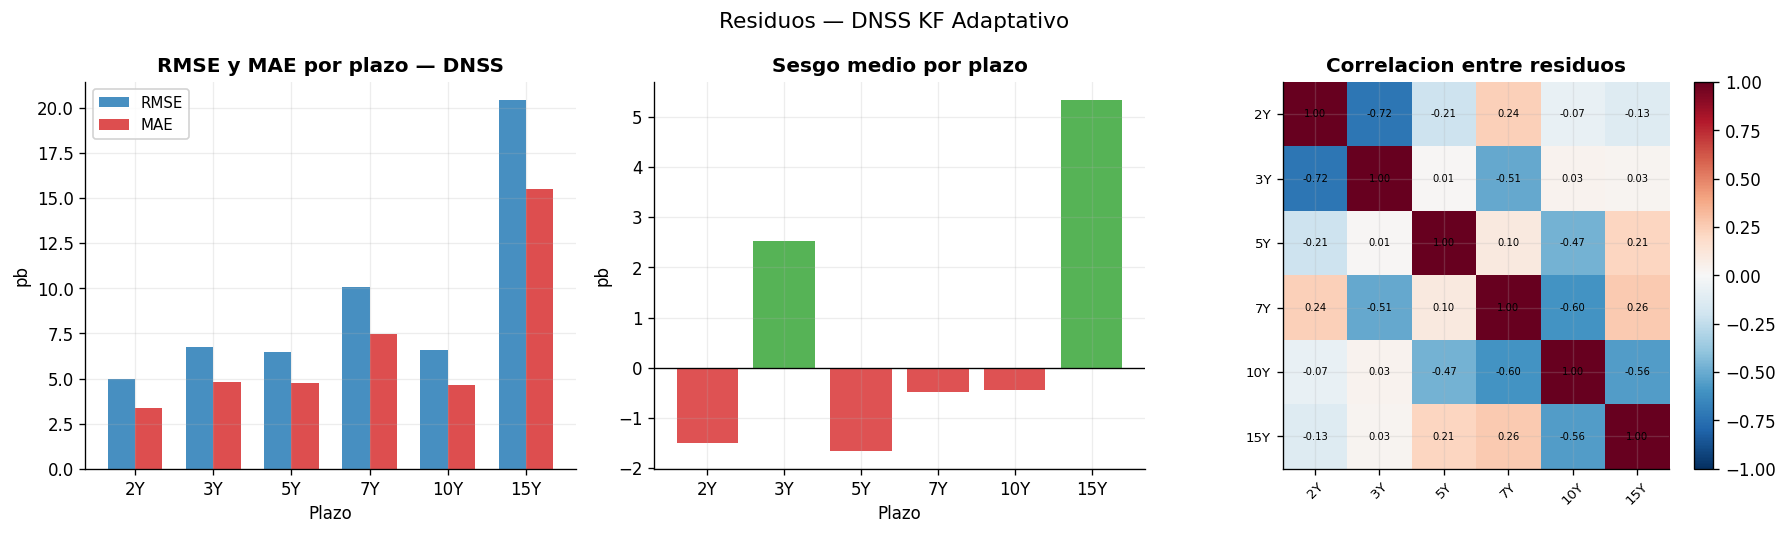

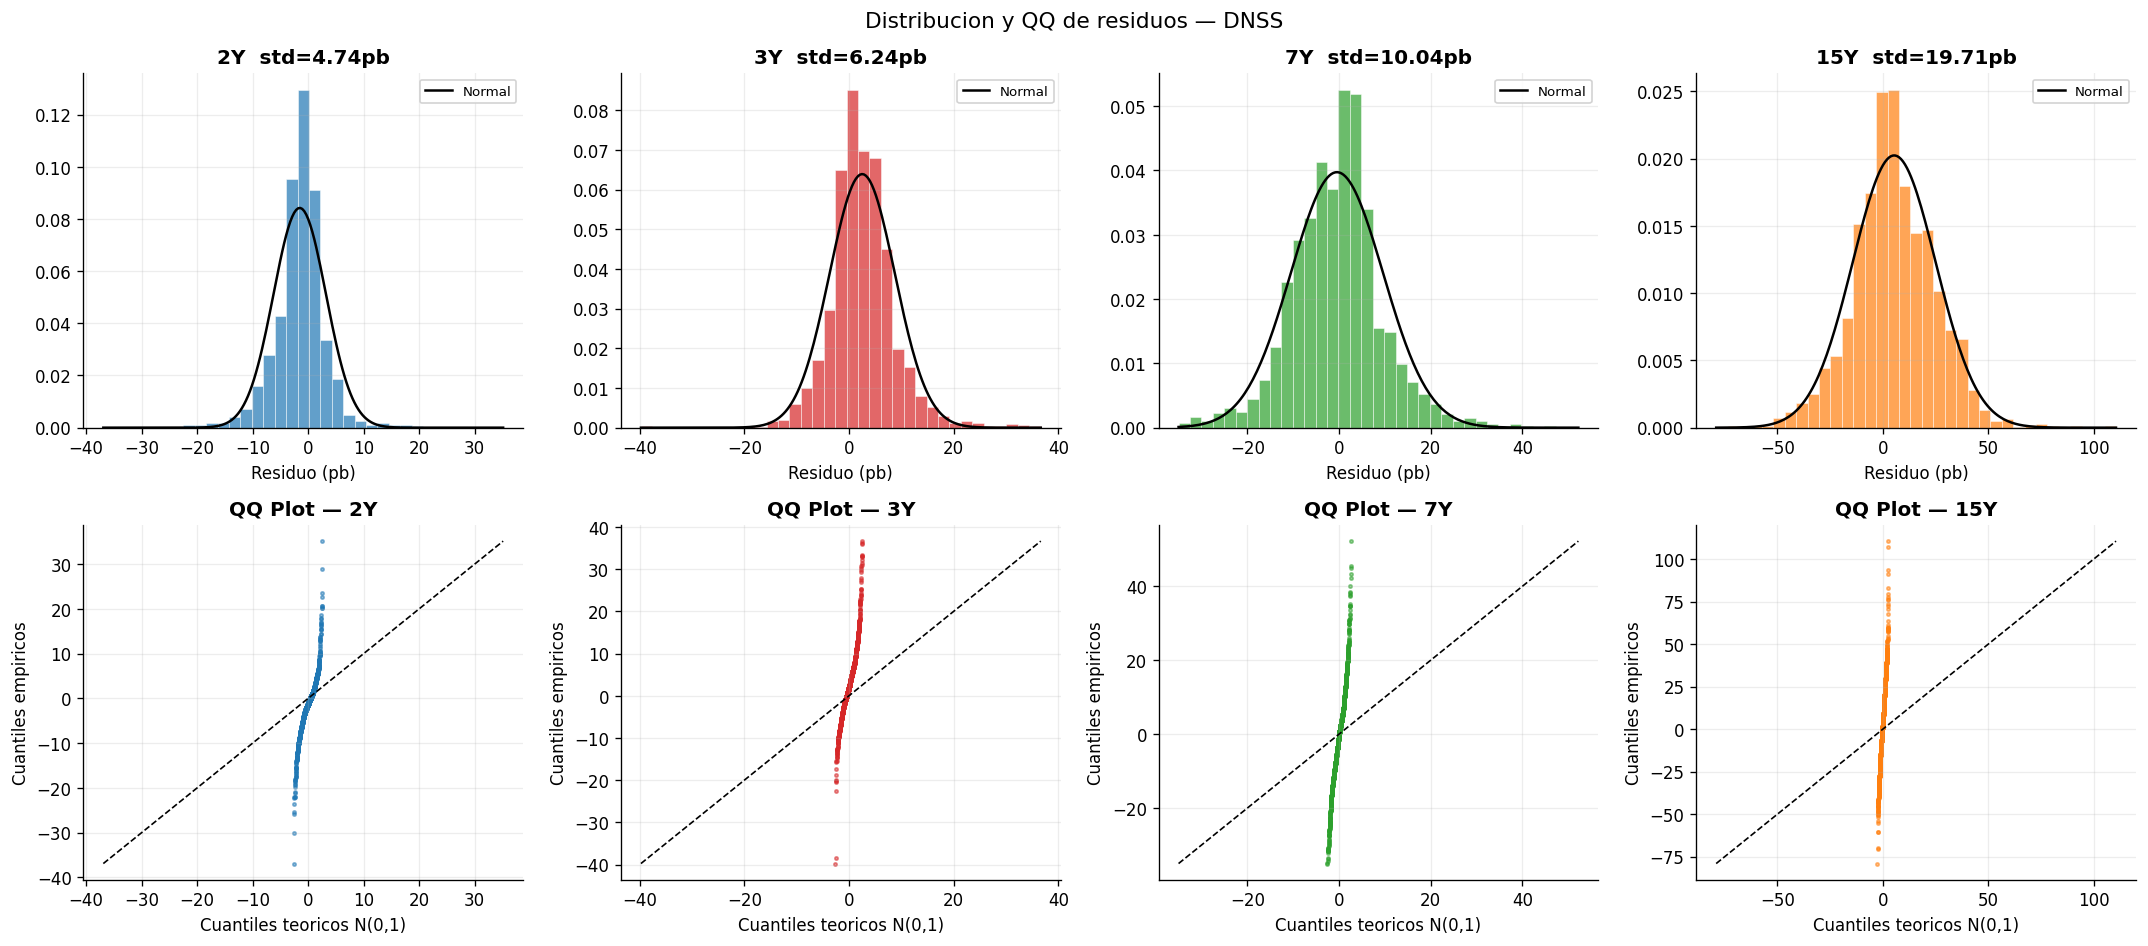

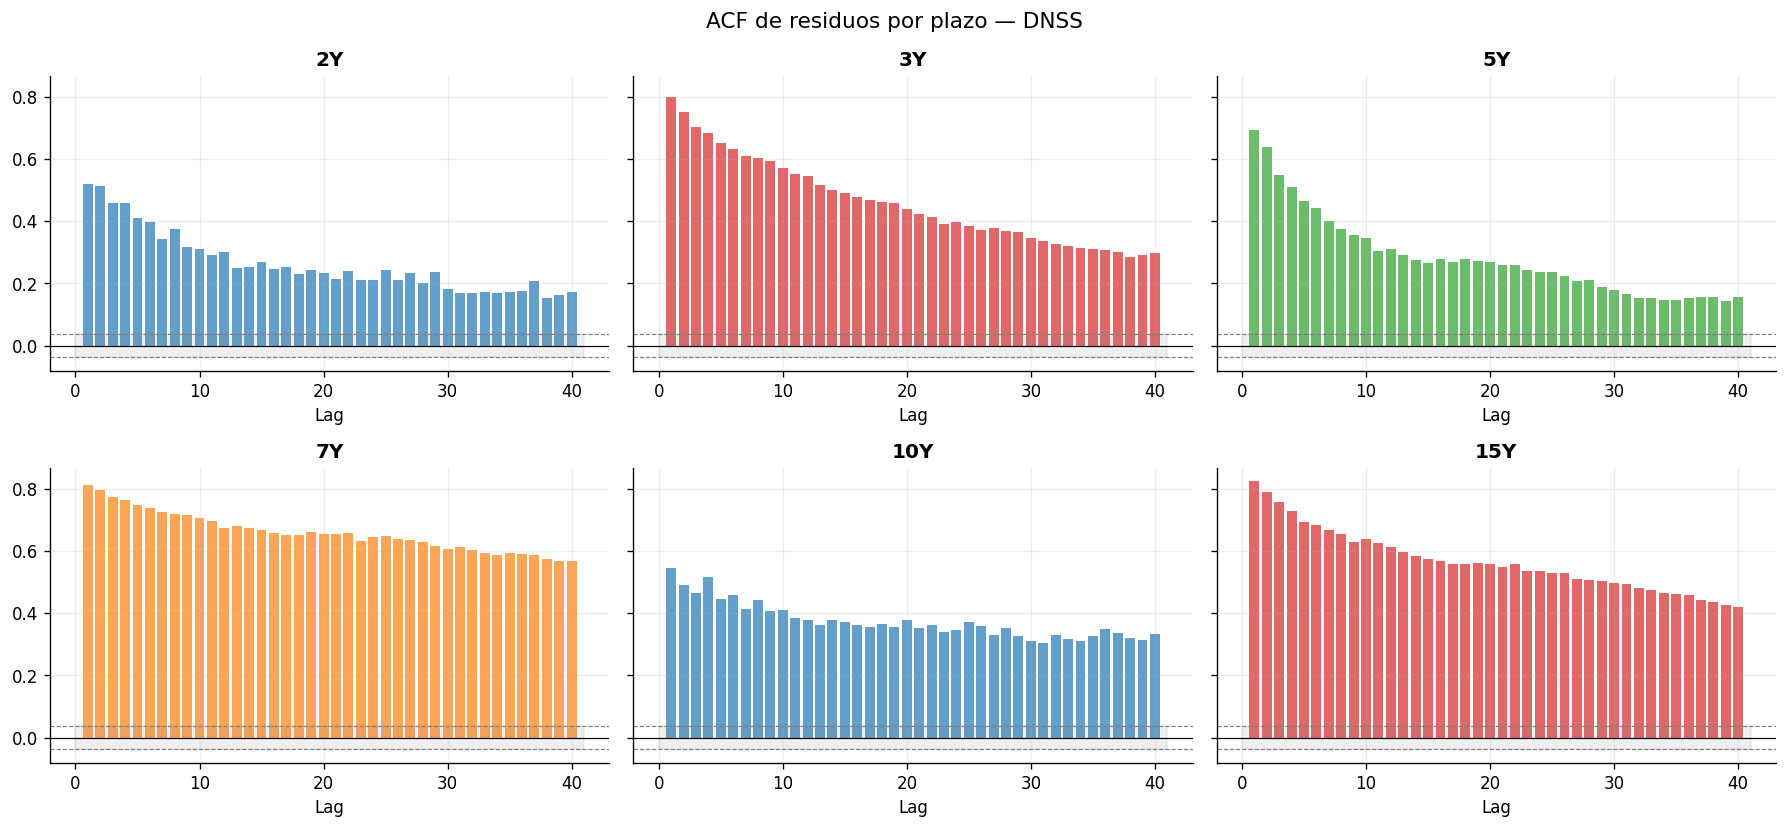


── Tests de residuos — DNSS ────────────────────────────────────────
  Plazo      RMSE     Sesgo   JB p-val   LB(10)p  Normal?  SerialCorr?
  ────────────────────────────────────────────────────────────────────────
     2Y     4.971    -1.507     0.0000    0.0000  No      Si
     3Y     6.737    +2.528     0.0000    0.0000  No      Si
     5Y     6.477    -1.660     0.0000    0.0000  No      Si
     7Y    10.055    -0.476     0.0000    0.0000  No      Si
    10Y     6.572    -0.451     0.0000    0.0000  No      Si
    15Y    20.423    +5.341     0.0000    0.0000  No      Si


In [21]:
# ═══════════════════════════════════════════════════════════════
# EXPERIMENTO: Opciones A (R-grupos) y C (pesos) para DNSS
# ═══════════════════════════════════════════════════════════════

# ── Definir pesos por plazo ──────────────────────────────────────
# Lógica: los plazos problemáticos (20Y, 30Y) reciben más peso
# → el optimizador los ajusta mejor a costa de mayor error en cortos
# Ajusta estos valores según la importancia de cada tramo en tu estudio

# Paso 1: identificar índices de plazos largos
mat_labels = [f'{int(m)}Y' for m in maturities]
print("Plazos disponibles:", mat_labels)

# Peso base = 1, largo >= 10Y recibe peso mayor
obs_weights_dns  = np.where(maturities >= 10, 2.5, 1.0)
obs_weights_dnss = np.where(maturities >= 10, 2.0, 1.0)

print(f"\nPesos DNS  : {dict(zip(mat_labels, obs_weights_dns))}")
print(f"Pesos DNSS : {dict(zip(mat_labels, obs_weights_dnss))}")

# ── Ajuste DNS — R grupos + pesos ────────────────────────────────
print("\n" + "="*60)
print("  DNS — R grupos + pesos en plazos largos")
res_dns_AC = fit_dns_kalman(
    dates            = dates_dt,
    yields           = yields_data,
    maturities       = maturities,
    model            = 'DNS',
    F_type           = 'diagonal',
    window_size      = max(52, T // 8),
    n_starts         = 6,
    obs_weights      = obs_weights_dns,     # Opción C
    r_mode           = 'grupos',            # Opción A
    group_thresholds = (3.0, 10.0),
    plot             = False,
    verbose          = True,
)

# ── Ajuste DNSS — R grupos + pesos ───────────────────────────────
print("\n" + "="*60)
print("  DNSS — R grupos + pesos en plazos largos")
res_dnss_AC = fit_dns_kalman(
    dates            = dates_dt,
    yields           = yields_data,
    maturities       = maturities,
    model            = 'DNSS',
    F_type           = 'diagonal',
    window_size      = max(52, T // 8),
    n_starts         = 2,
    obs_weights      = obs_weights_dnss,    # Opción C
    r_mode           = 'grupos',            # Opción A
    group_thresholds = (3.0, 10.0),
    plot             = False,
    verbose          = True,
)

# ── Comparativa: base vs A+C ─────────────────────────────────────
print(f"\n{'═'*65}")
print(f"  Comparativa RMSE por plazo — base vs A+C")
print(f"{'═'*65}")
print(f"  {'Plazo':>5}  {'DNS-base':>9}  {'DNS-AC':>9}  {'Δ DNS':>8}  "
      f"{'DNSS-base':>10}  {'DNSS-AC':>9}  {'Δ DNSS':>8}")
print(f"  {'─'*65}")
for i, m in enumerate(maturities):
    rd0  = res_dns['rmse_mat'][i]   * 100
    rdac = res_dns_AC['rmse_mat'][i]* 100
    rs0  = res_dnss['rmse_mat'][i]  * 100
    rsac = res_dnss_AC['rmse_mat'][i]*100
    print(f"  {m:>4.0f}Y  {rd0:>9.3f}  {rdac:>9.3f}  {rdac-rd0:>+8.3f}  "
          f"{rs0:>10.3f}  {rsac:>9.3f}  {rsac-rs0:>+8.3f}")

print(f"\n  Nota: Δ negativo = mejora respecto al modelo base")

# ── Gráficos comparativos del mejor modelo A+C ───────────────────
print("\n  Graficos completos DNS con Opciones A+C ...")
plot_factores(res_dns_AC,       titulo_extra="[R-grupos + pesos]")
plot_curvas_ajustadas(res_dns_AC, n_fechas=6)
plot_heatmap_residuos(res_dns_AC)
analisis_residuos(res_dns_AC)

print("\n  Graficos completos DNSS con Opciones A+C ...")
plot_factores(res_dnss_AC,        titulo_extra="[R-grupos + pesos]")
plot_curvas_ajustadas(res_dnss_AC, n_fechas=6)
plot_heatmap_residuos(res_dnss_AC)
analisis_residuos(res_dnss_AC)